## Credit Risk Assignment ##

</h> 1. Importing Libraries </h>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pwd

'C:\\Users\\RAJDEEP\\Upgrad_Main_Module_Classes\\EDA_Credit_Risk_Assignment'

<span style="color:darkblue;">2. Reading "Application Data" file</span>

In [3]:
inp0 = pd.read_csv("application_data.csv")

In [4]:
inp1 = pd.read_csv("previous_application.csv")

In [5]:
inp1.shape

(1670214, 37)

In [6]:
inp1.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
inp1.rename(columns={'NAME_CONTRACT_TYPE': "PREV_NAME_CONTRACT_TYPE"}, inplace=True)

### Checking Basic informations of the dataframe

In [8]:
inp0.shape

(307511, 122)

In [9]:
inp0.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
list(inp0.columns)

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [11]:
inp0.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [12]:
#print(inp0.info)
inp0.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

#### There are several null values in many columns , TARGET column is of integer datatype because its values are 1 and 0, but ideally they should be categorical datatype

#### Checking correlation matrix though the Target column should be categorical , but it will help to understand if there exists any sort of inter relationship among the independent variables

In [13]:
cor = inp0.corr()

In [14]:
# plt.figure(figsize=(1000,500))
# sns.heatmap(cor, linecolor='blue', linewidths=1.5, cmap='RdYlGn', annot=True)
# sns.set(font_scale=2.8)
# plt.show()

### Checking for Null values

In [15]:
count = 0
for i in list(inp0.columns):
    if inp0[i].isna().sum() > 0:
        count += 1
        
        print("The column "+ i + " has null values:-> {} , which is -> {}% ".format(inp0[i].isna().sum(), 
                                                                                round((inp0[i].isna().sum()/len(inp0)) * 100,2)) )
print('\n')
print("The total number of columns having null values is: {}".format(count))
print('\n')

# null_column_valid_list = []
null_column_list_0_20_percent = []
null_column_list_20_40_percent = []
null_column_list_40_50_percent = []
null_column_list_50_60_percent = []
null_column_list_60_70_percent = []
null_column_list_70_80_percent = []
null_column_list_more_80_percent = []

#count_1 = 0
for i in list(inp0.columns):
    
    if inp0[i].isna().sum() > 0:
        
        if round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) >= 0 and round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) <= 20 :
            null_column_list_0_20_percent.append(i)
            
        elif round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) > 20 and round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) <= 40 :
            null_column_list_20_40_percent.append(i)
            
        elif round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) > 40 and round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) <= 50 :
            null_column_list_40_50_percent.append(i)
            
        elif round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) > 50 and round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) <= 60 :
            null_column_list_50_60_percent.append(i)
            
        elif round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) > 60 and round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) <= 70 :
            null_column_list_60_70_percent.append(i)
            
        elif round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) > 70 and round((inp0[i].isna().sum()/len(inp0)) * 100, 2 ) <= 80 :
            null_column_list_70_80_percent.append(i)
            
        else :
            null_column_list_more_80_percent.append(i)
            
            
print("The number of columns which have less than or equal to 20 percent null values: {}".format(len(null_column_list_0_20_percent)))
print("The number of columns which have 20 to 40 percent null values: {}".format(len(null_column_list_20_40_percent)))
print("The number of columns which have 40 to 50 percent null values: {}".format(len(null_column_list_40_50_percent)))
print("The number of columns which have 50 to 60 percent null values: {}".format(len(null_column_list_50_60_percent)))
print("The number of columns which have 60 to 70 percent null values: {}".format(len(null_column_list_60_70_percent)))
print("The number of columns which have 70 to 80 percent null values: {}".format(len(null_column_list_70_80_percent)))
print("The number of columns which have more than 80 percent null values: {}".format(len(null_column_list_more_80_percent)))

The column AMT_ANNUITY has null values:-> 12 , which is -> 0.0% 
The column AMT_GOODS_PRICE has null values:-> 278 , which is -> 0.09% 
The column NAME_TYPE_SUITE has null values:-> 1292 , which is -> 0.42% 
The column OWN_CAR_AGE has null values:-> 202929 , which is -> 65.99% 
The column OCCUPATION_TYPE has null values:-> 96391 , which is -> 31.35% 
The column CNT_FAM_MEMBERS has null values:-> 2 , which is -> 0.0% 
The column EXT_SOURCE_1 has null values:-> 173378 , which is -> 56.38% 
The column EXT_SOURCE_2 has null values:-> 660 , which is -> 0.21% 
The column EXT_SOURCE_3 has null values:-> 60965 , which is -> 19.83% 
The column APARTMENTS_AVG has null values:-> 156061 , which is -> 50.75% 
The column BASEMENTAREA_AVG has null values:-> 179943 , which is -> 58.52% 
The column YEARS_BEGINEXPLUATATION_AVG has null values:-> 150007 , which is -> 48.78% 
The column YEARS_BUILD_AVG has null values:-> 204488 , which is -> 66.5% 
The column COMMONAREA_AVG has null values:-> 214865 , whi

#### Non_Empty columns

In [16]:
non_empty_col = []
for i in list(inp0.columns):
    
    if inp0[i].isna().sum() == 0:
        non_empty_col.append(i)
        
print(non_empty_col)

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUME

In [17]:
print(len(non_empty_col))

55


### Checking each category of null values

-  <span style="color:darkblue;font-weight:bold">Columns having of 0 to 20% Null values:</span>

In [18]:
null_column_list_0_20_percent

['AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'CNT_FAM_MEMBERS',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'DAYS_LAST_PHONE_CHANGE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR']

#### Taking a copy of the main dataframe in order to keep the original data untouched

In [19]:
inp0_cp = inp0.copy()

In [20]:
inp0_cp[['AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AMT_GOODS_PRICE             307233 non-null  float64
 1   NAME_TYPE_SUITE             306219 non-null  object 
 2   EXT_SOURCE_2                306851 non-null  float64
 3   EXT_SOURCE_3                246546 non-null  float64
 4   OBS_30_CNT_SOCIAL_CIRCLE    306490 non-null  float64
 5   DEF_30_CNT_SOCIAL_CIRCLE    306490 non-null  float64
 6   OBS_60_CNT_SOCIAL_CIRCLE    306490 non-null  float64
 7   DEF_60_CNT_SOCIAL_CIRCLE    306490 non-null  float64
 8   AMT_REQ_CREDIT_BUREAU_HOUR  265992 non-null  float64
 9   AMT_REQ_CREDIT_BUREAU_DAY   265992 non-null  float64
 10  AMT_REQ_CREDIT_BUREAU_WEEK  265992 non-null  float64
 11  AMT_REQ_CREDIT_BUREAU_MON   265992 non-null  float64
 12  AMT_REQ_CREDIT_BUREAU_QRT   265992 non-null  float64
 13  AMT_REQ_CREDIT

In [21]:
inp0_cp[inp0_cp['NAME_TYPE_SUITE'].isnull()]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
64,100076,0,Cash loans,M,Y,N,0,180000.0,315000.0,9679.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
724,100837,0,Revolving loans,F,N,Y,2,45000.0,135000.0,6750.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1199,101414,0,Cash loans,M,Y,N,0,135000.0,533668.5,34636.5,...,0,0,0,0,0.0,0.0,0.0,4.0,0.0,0.0
1669,101954,0,Cash loans,F,Y,N,2,153000.0,1162170.0,30654.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1862,102183,0,Cash loans,F,Y,N,0,121500.0,268659.0,13774.5,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306273,454852,0,Revolving loans,M,N,Y,2,67500.0,202500.0,10125.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
306544,455158,0,Cash loans,F,N,N,0,180000.0,894825.0,23602.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
306615,455245,0,Cash loans,M,N,N,0,180000.0,225000.0,8469.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0
306636,455270,0,Cash loans,M,Y,N,2,189000.0,677664.0,21406.5,...,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
inp0_cp.dropna(subset = ['NAME_TYPE_SUITE'], inplace=True) # Dropping the null instances of NAME_Type_SUITE

<AxesSubplot:ylabel='NAME_TYPE_SUITE'>

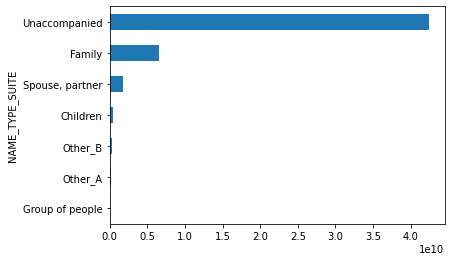

In [23]:
inp0_cp.groupby(['NAME_TYPE_SUITE'])['AMT_INCOME_TOTAL'].sum().sort_values(ascending=True).plot(kind='barh')

- As we can see here that Other_B, Other_A, 'Group of People' are almost negligible , so we can combine them as a common group

In [24]:
inp0_cp['NAME_TYPE_SUITE'].replace(['Other_B','Other_A','Group of people'], 'Others', inplace=True)

<AxesSubplot:ylabel='NAME_TYPE_SUITE'>

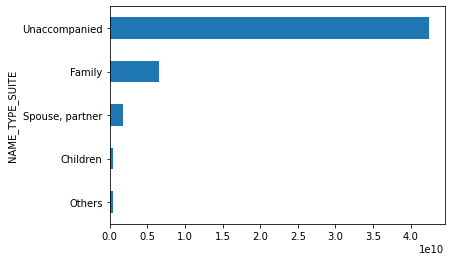

In [25]:
inp0_cp.groupby(['NAME_TYPE_SUITE'])['AMT_INCOME_TOTAL'].sum().sort_values(ascending=True).plot(kind='barh')

- The total Income Amount of the people who are unaccompanied at the time of taking loan is highest, followed by those whi are accompanied by 'Family' and thereafter 'Children' and Other reason

EXT_SOURCE_1 , EXT_SOURCE_2 and EXT_SOURCE_3 are the normalized score from external data source

<AxesSubplot:xlabel='EXT_SOURCE_2', ylabel='AMT_INCOME_TOTAL'>

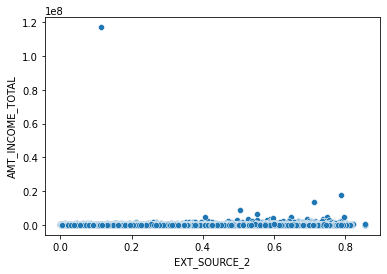

In [26]:
sns.scatterplot(x='EXT_SOURCE_2', y='AMT_INCOME_TOTAL', data=inp0_cp)

- No significant relationship can be drawn between the Total Income and External Source

<AxesSubplot:xlabel='EXT_SOURCE_2', ylabel='Count'>

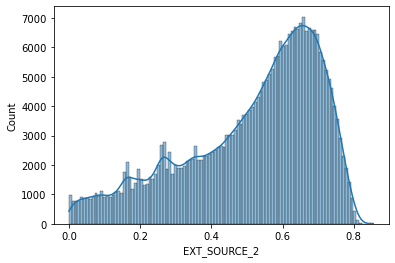

In [27]:
sns.histplot(x=inp0_cp['EXT_SOURCE_2'], kde=True)

<AxesSubplot:xlabel='EXT_SOURCE_3', ylabel='Count'>

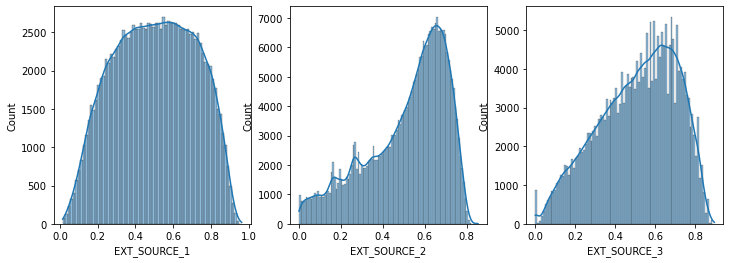

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
sns.histplot(x=inp0_cp['EXT_SOURCE_1'], kde=True, ax=axes[0])
sns.histplot(x=inp0_cp['EXT_SOURCE_2'], kde=True, ax=axes[1])
sns.histplot(x=inp0_cp['EXT_SOURCE_3'], kde=True, ax=axes[2])

# axes[0].set_xlabel('Boxplot of cigsPerDay after outlier treatment')
# sns.histplot(x='cigsPerDay', data=data_work, kde=True, ax=axes[1])
# axes[1].set_xlabel('Histogram of cigsPerDay after outlier treatment')


- These are external scores in normalized form , We can delete these 3 columns from the dataframe, instead keeping the average of all these three columns

In [29]:
inp0_cp['AVG_EXT_SOURCE_SCORE'] = inp0_cp[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

In [30]:
inp0_cp.drop(['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'], axis=1, inplace=True)

In [31]:
inp0_cp.shape

(306219, 120)

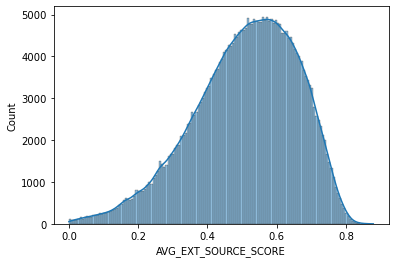

In [32]:
sns.histplot(inp0_cp['AVG_EXT_SOURCE_SCORE'], kde=True)
plt.show()

#### OBS_30_CNT_SOCIAL_CIRCLE  - How many observation of client's social surroundings with observable 30 DPD (days past due) default

In [33]:
inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'].unique()

array([  2.,   1.,   0.,   4.,   8.,  10.,  nan,   7.,   3.,   6.,   5.,
        12.,   9.,  13.,  11.,  14.,  22.,  16.,  15.,  17.,  20.,  25.,
        19.,  18.,  21.,  24.,  23.,  28.,  26.,  29.,  27.,  47., 348.,
        30.])

In [34]:
inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts(normalize=True)*100

0.0      53.491504
1.0      15.919174
2.0       9.724179
3.0       6.627173
4.0       4.609794
5.0       3.117321
6.0       2.105846
7.0       1.430219
8.0       0.964620
9.0       0.654002
10.0      0.449217
11.0      0.278180
12.0      0.211994
13.0      0.133684
14.0      0.084535
15.0      0.053736
16.0      0.043578
17.0      0.028506
18.0      0.015072
19.0      0.014417
20.0      0.009830
21.0      0.009502
22.0      0.007208
23.0      0.004915
25.0      0.003604
24.0      0.003604
27.0      0.001638
26.0      0.000983
30.0      0.000655
28.0      0.000328
29.0      0.000328
47.0      0.000328
348.0     0.000328
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64

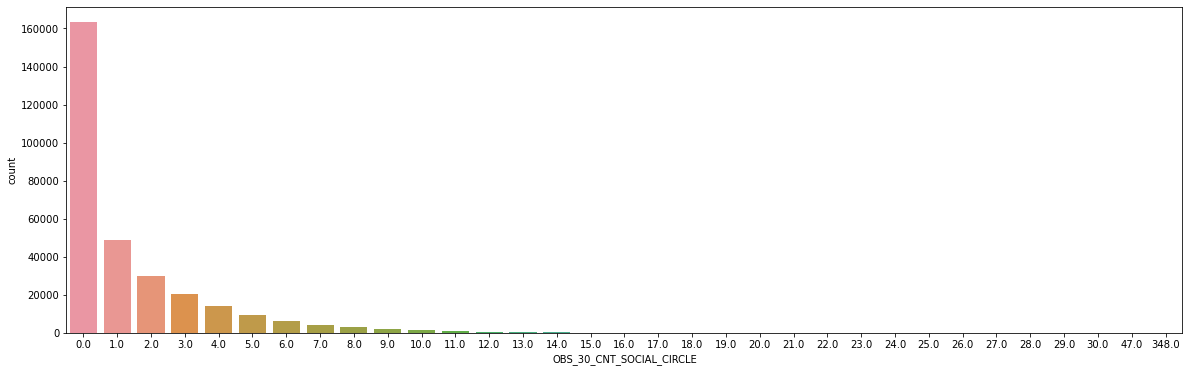

In [35]:
plt.figure(figsize=(20,6))
sns.countplot(inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'])
plt.show()

- We can see that, the number of 0 defaulters is contributing 50% among all the number of defaulters inthe social circle of customers
- We can think of making this numerical feature to categorical in order to make it categorical : The approach will be exxcept 0 all other will be grouped together
- We can see very negligible null values in this attribute(0.33%), which can be removed.
- This attribute is right skewed and leding towards creation of outliers
- Seeing the values we can say that 348 is outlier, which can be eliminated

In [36]:
(inp0_cp[inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'] == 348].index)

Int64Index([148403], dtype='int64')

In [37]:
inp0_cp.drop(inp0_cp[inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'] == 348].index, inplace=True)

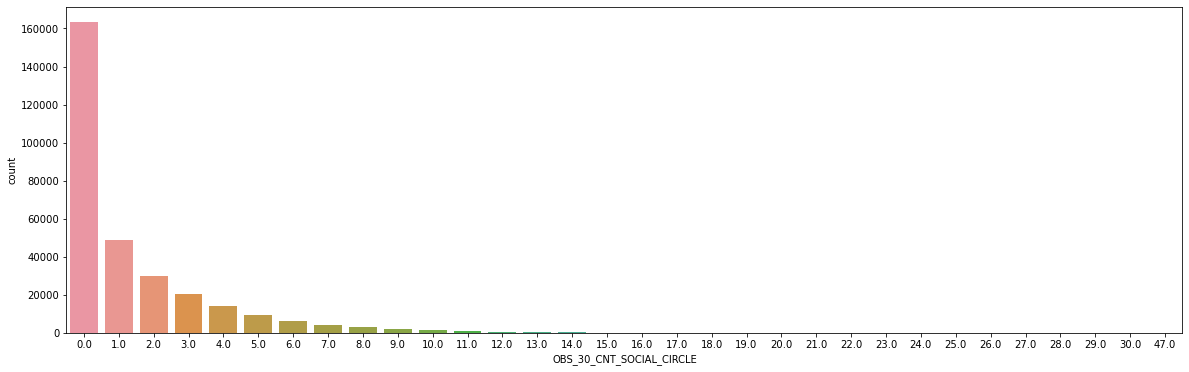

In [38]:
plt.figure(figsize=(20,6))
sns.countplot(inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'])
plt.show()

In [39]:
inp0_cp.shape

(306218, 120)

#### DEF_30_CNT_SOCIAL_CIRCLE - How many observation of client's social surroundings defaulted on 30 DPD (days past due) 

In [40]:
print(inp0_cp['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts())
print('\n')
print(inp0_cp['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts(normalize=True))

0.0    270189
1.0     28201
2.0      5300
3.0      1186
4.0       252
5.0        56
6.0        11
7.0         1
8.0         1
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: int64


0.0    0.885294
1.0    0.092403
2.0    0.017366
3.0    0.003886
4.0    0.000826
5.0    0.000183
6.0    0.000036
7.0    0.000003
8.0    0.000003
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64


- The total number of defaulters in 30 days past due date also show some sort of similar picture as that of last attribute.
- If we take all the customers level granularity then in all of their surrounding number of non defaulter is quite higher.
- the single defaulter for all customer surrounding cumulatively giving only 28201 which gives 0.09% only among all the customers.
- The null values can be removed here as well.

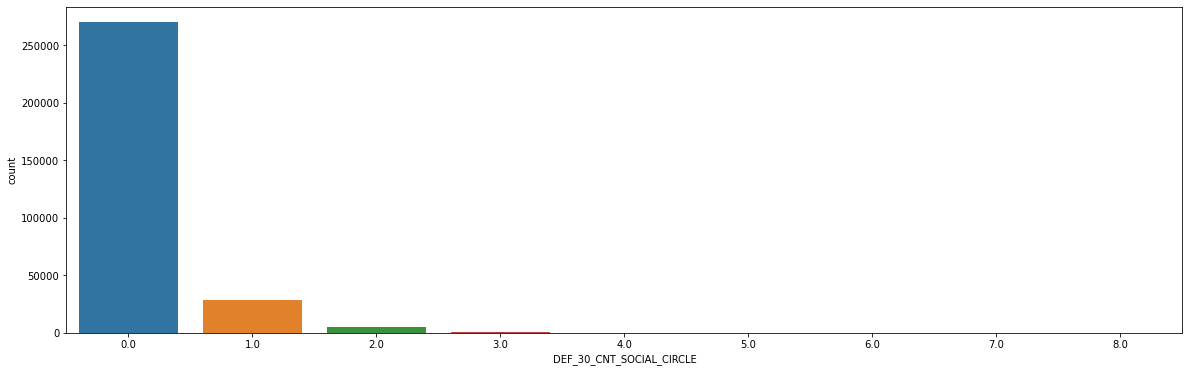

In [41]:
plt.figure(figsize=(20,6))
sns.countplot(inp0_cp['DEF_30_CNT_SOCIAL_CIRCLE'])
plt.show()

#### OBS_60_CNT_SOCIAL_CIRCLE - How many observation of client's social surroundings with observable 60 DPD (days past due) default

In [42]:
print(inp0_cp['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts())
print('\n')
print(inp0_cp['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts(normalize=True))

0.0     164008
1.0      48671
2.0      29637
3.0      20118
4.0      13874
5.0       9423
6.0       6325
7.0       4319
8.0       2863
9.0       1951
10.0      1329
11.0       834
12.0       618
13.0       398
14.0       238
15.0       164
16.0       137
17.0        72
18.0        49
19.0        44
20.0        30
21.0        28
22.0        20
23.0        13
24.0        12
25.0        11
27.0         5
29.0         2
28.0         1
47.0         1
30.0         1
26.0         1
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: int64


0.0     0.537384
1.0     0.159474
2.0     0.097108
3.0     0.065918
4.0     0.045459
5.0     0.030875
6.0     0.020724
7.0     0.014152
8.0     0.009381
9.0     0.006393
10.0    0.004355
11.0    0.002733
12.0    0.002025
13.0    0.001304
14.0    0.000780
15.0    0.000537
16.0    0.000449
17.0    0.000236
18.0    0.000161
19.0    0.000144
20.0    0.000098
21.0    0.000092
22.0    0.000066
23.0    0.000043
24.0    0.000039
25.0    0.000036
27.0    0.000016
29.0    0.0000

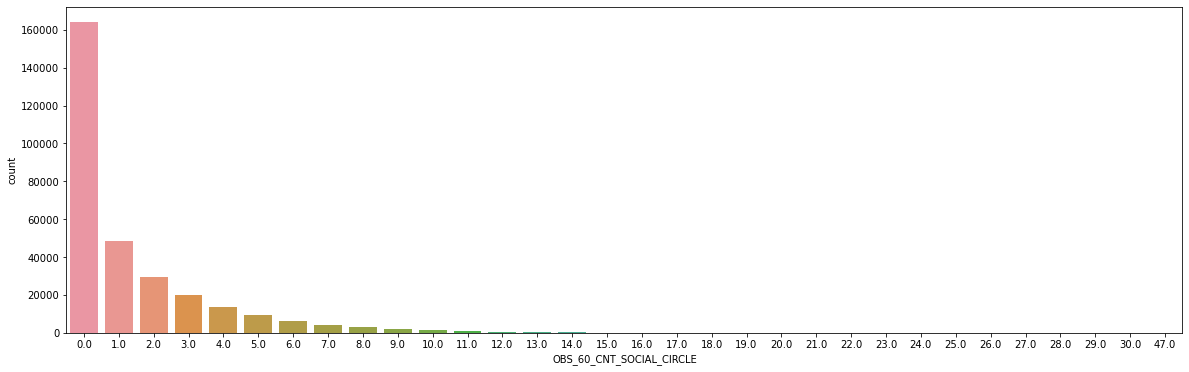

In [43]:
plt.figure(figsize=(20,6))
sns.countplot(inp0_cp['OBS_60_CNT_SOCIAL_CIRCLE'])
plt.show()

- We can see that, the number of 0 defaulters is contributing 50% among all the number of defaulters inthe social circle of customers
- We can think of making this numerical feature to categorical in order to make it categorical : The approach will be except 0 all other will be grouped together
- We can see very negligible null values in this attribute(0.33%), which can be removed.
- This attribute is right skewed and leding towards creation of outliers

#### DEF_60_CNT_SOCIAL_CIRCLE - How many observation of client's social surroundings defaulted on 60 (days past due) DPD

In [44]:
print(inp0_cp['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts())
print('\n')
print(inp0_cp['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts(normalize=True))

0.0    279545
1.0     21745
2.0      3152
3.0       596
4.0       135
5.0        20
6.0         3
7.0         1
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: int64


0.0    0.915949
1.0    0.071249
2.0    0.010328
3.0    0.001953
4.0    0.000442
5.0    0.000066
6.0    0.000010
7.0    0.000003
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64


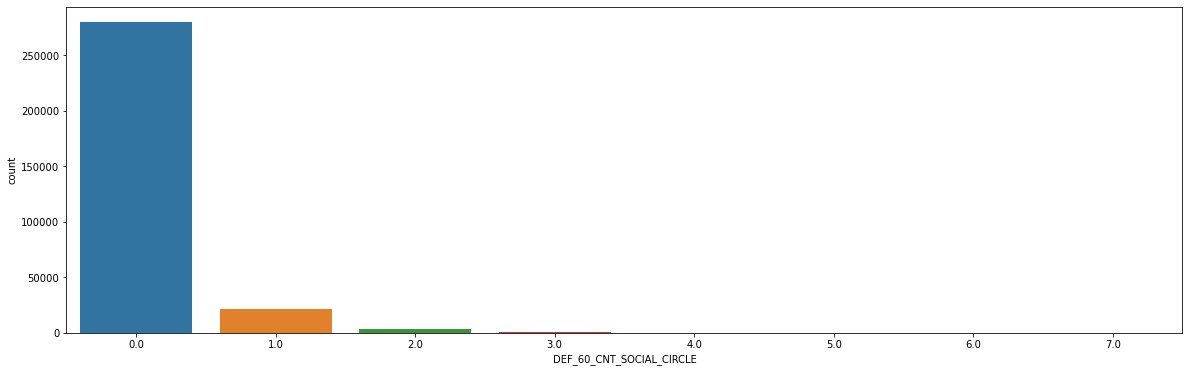

In [45]:
plt.figure(figsize=(20,6))
sns.countplot(inp0_cp['DEF_60_CNT_SOCIAL_CIRCLE'])
plt.show()

- The total number of defaulters in 60 days past due date also show some sort of similar picture as that of last attribute.
- If we take all the customers level granularity then in all of their surrounding number of non defaulter is quite higher.
- the single defaulter for all customer surrounding, cumulatively giving only 21745 which gives 0.07% onlyamong all the customers.
- The null values can be removed here as well.

#### Removing Null instances from all the OBS and DEF attributes

In [46]:
inp0_cp.dropna(subset = ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
                        'OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE'], inplace=True)

In [47]:
inp0_cp.shape

(305197, 120)

#### Changing the attributes to Categorical in order to get a proper picture and also it will help to remove the outliers and skewness

In [48]:
inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'] = inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'].apply(lambda x: 'Non Defaulter' if x== 0 else 'Late payer')
inp0_cp['DEF_30_CNT_SOCIAL_CIRCLE'] = inp0_cp['DEF_30_CNT_SOCIAL_CIRCLE'].apply(lambda x: 'Non Defaulter' if x== 0 else 'Defaulter')
inp0_cp['OBS_60_CNT_SOCIAL_CIRCLE'] = inp0_cp['OBS_60_CNT_SOCIAL_CIRCLE'].apply(lambda x: 'Non Defaulter' if x== 0 else 'Late Payer')
inp0_cp['DEF_60_CNT_SOCIAL_CIRCLE'] = inp0_cp['DEF_60_CNT_SOCIAL_CIRCLE'].apply(lambda x: 'Non Defaulter' if x== 0 else 'Defaulter')

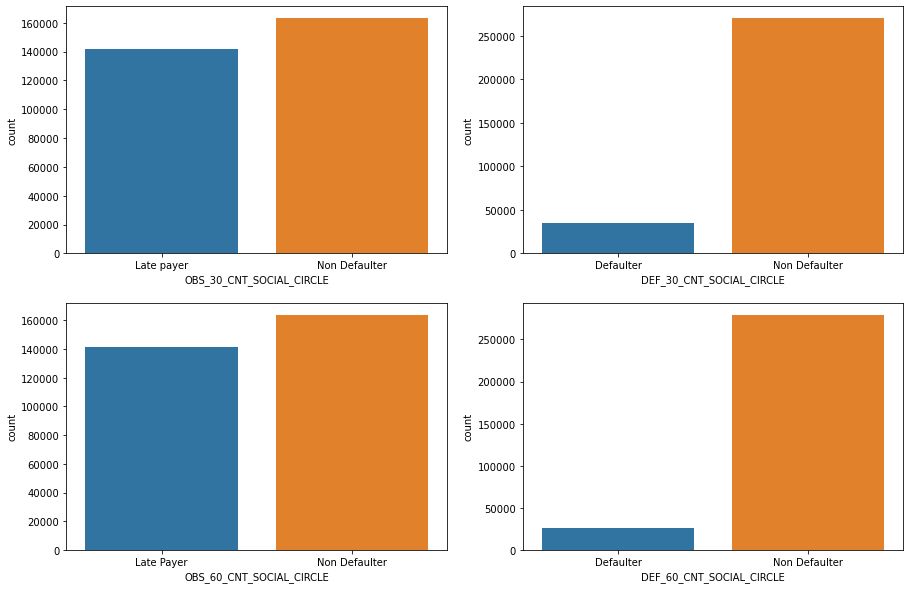

In [49]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,10))
sns.countplot(inp0_cp['OBS_30_CNT_SOCIAL_CIRCLE'], ax=axes[0,0])
sns.countplot(inp0_cp['DEF_30_CNT_SOCIAL_CIRCLE'], ax=axes[0,1])
sns.countplot(inp0_cp['OBS_60_CNT_SOCIAL_CIRCLE'], ax=axes[1,0])
sns.countplot(inp0_cp['DEF_60_CNT_SOCIAL_CIRCLE'], ax=axes[1,1])
plt.show()


#### Observation:
----------------------
- After changing the attributes to categorical, we can see in 30 Days past the due date, The non-defaulter count is higher
- The Late payer in 30 days and 60 days are quite higher than the number of defaulters

#### AMT_REQ_CREDIT_BUREAU_HOUR - Number of enquiries to Credit Bureau about the client one hour before application

In [50]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_HOUR'].isna().sum()

41240

In [51]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_HOUR'].value_counts()

0.0    262351
1.0      1540
2.0        56
3.0         9
4.0         1
Name: AMT_REQ_CREDIT_BUREAU_HOUR, dtype: int64

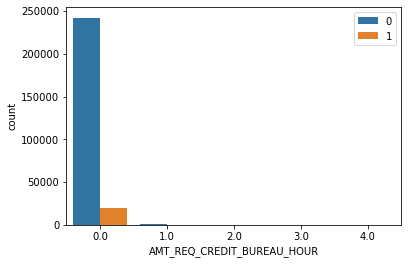

In [52]:
sns.countplot(x='AMT_REQ_CREDIT_BUREAU_HOUR', data=inp0_cp, hue='TARGET')
plt.legend(loc=1)
plt.show()

- The attribute is skewed, though from the dataset we can understand that there are very little number of questions asked to the credit bureau an hour before applying for loan

#### AMT_REQ_CREDIT_BUREAU_DAY - Number of enquiries to Credit Bureau about the client one day before application (excluding one hour before application)

In [53]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_DAY'].isna().sum()

41240

In [54]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()

0.0    262477
1.0      1285
2.0       106
3.0        44
4.0        25
5.0         9
6.0         8
9.0         2
8.0         1
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: int64

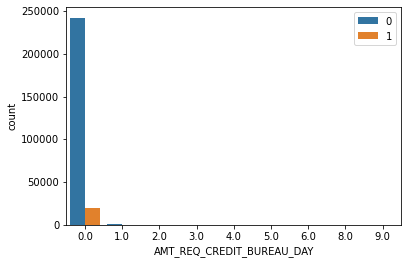

In [55]:
sns.countplot(x='AMT_REQ_CREDIT_BUREAU_DAY', data=inp0_cp, hue='TARGET')
plt.legend(loc=1)
plt.show()

- Like the previous attribute, here also we can see that before a day of applying for loan, the number of persons not asking any question is highest , other numbers are almost negligible than that

#### AMT_REQ_CREDIT_BUREAU_WEEK - Number of enquiries to Credit Bureau about the client one week before application (excluding one day before application)

In [56]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_WEEK'].isna().sum()

41240

In [57]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_WEEK'].value_counts()

0.0    255448
1.0      8185
2.0       198
3.0        56
4.0        33
6.0        20
5.0        10
8.0         5
7.0         2
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: int64

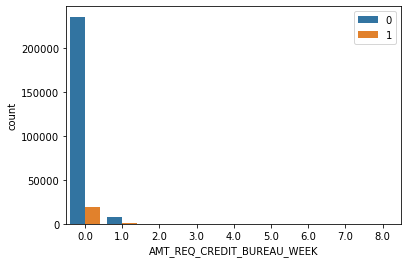

In [58]:
sns.countplot(x='AMT_REQ_CREDIT_BUREAU_WEEK', data=inp0_cp, hue='TARGET')
plt.legend(loc=1)
plt.show()

#### AMT_REQ_CREDIT_BUREAU_MON - Number of enquiries to Credit Bureau about the client one month before application (excluding one week before application)

In [59]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_MON'].isna().sum()

41240

In [60]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()

0.0     220419
1.0      33005
2.0       5352
3.0       1980
4.0       1071
5.0        593
6.0        337
7.0        295
9.0        205
8.0        181
10.0       131
11.0       116
12.0        77
13.0        71
14.0        39
15.0        35
16.0        23
17.0        14
18.0         6
19.0         3
24.0         1
23.0         1
27.0         1
22.0         1
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: int64

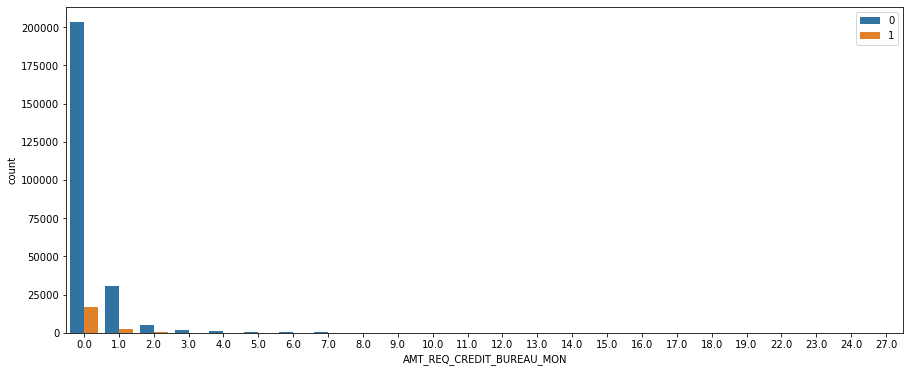

In [61]:
plt.figure(figsize=(15,6))
sns.countplot(x='AMT_REQ_CREDIT_BUREAU_MON', data=inp0_cp, hue='TARGET')
plt.legend(loc=1)
plt.show()

#### AMT_REQ_CREDIT_BUREAU_QRT - Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application)

In [62]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_QRT'].isna().sum()

41240

In [63]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()

0.0      213667
1.0       33696
2.0       14314
3.0        1702
4.0         472
5.0          63
6.0          28
7.0           7
8.0           6
261.0         1
19.0          1
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: int64

In [64]:
inp0_cp[inp0_cp['AMT_REQ_CREDIT_BUREAU_QRT'] == 19].index

Int64Index([253541], dtype='int64')

- Here 19 and 261 seem to be outlier

##### Outliers handling for this attribute

In [65]:
inp0_cp.drop(inp0_cp[inp0_cp['AMT_REQ_CREDIT_BUREAU_QRT'] == 19].index, axis=0, inplace=True)
inp0_cp.drop(inp0_cp[inp0_cp['AMT_REQ_CREDIT_BUREAU_QRT'] == 261].index, axis = 0, inplace=True)

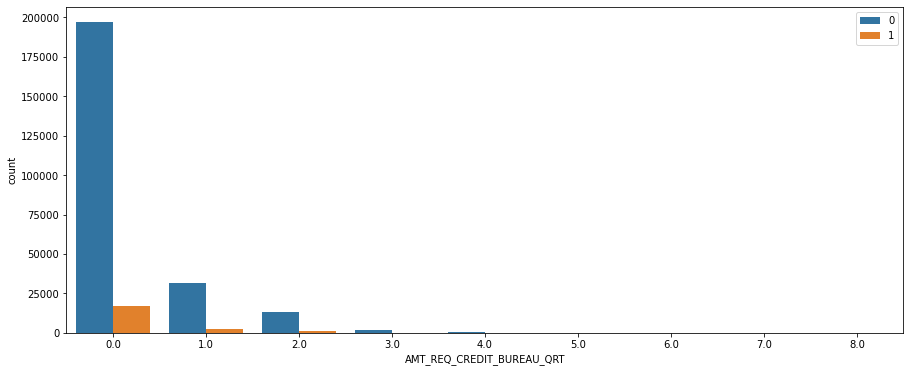

In [66]:
plt.figure(figsize=(15,6))
sns.countplot(x='AMT_REQ_CREDIT_BUREAU_QRT', data=inp0_cp, hue='TARGET')
plt.legend(loc=1)
plt.show()

#### AMT_REQ_CREDIT_BUREAU_YEAR - Number of enquiries to Credit Bureau about the client one day year (excluding last 3 months before application)

In [67]:
inp0_cp['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

0.0     70780
1.0     63035
2.0     49935
3.0     33465
4.0     20614
5.0     11998
6.0      6931
7.0      3849
8.0      2120
9.0      1088
11.0       31
12.0       29
10.0       22
13.0       19
14.0       10
17.0        7
15.0        6
19.0        4
18.0        4
16.0        3
25.0        1
23.0        1
22.0        1
21.0        1
20.0        1
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: int64

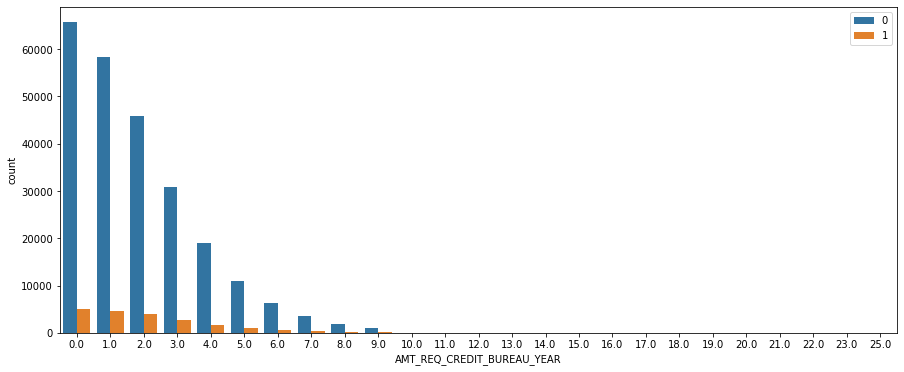

In [68]:
plt.figure(figsize=(15,6))
sns.countplot(x='AMT_REQ_CREDIT_BUREAU_YEAR',data=inp0_cp, hue='TARGET')
plt.legend(loc=1)
plt.show()

#### Observations: 
----------------------
- All the AMT_REQ_CREDIT attributes are skewed towards right and all have outliers.
- We can handle the outliers
- All of these 6 attributes show that number of applicants asking no questions is highest and number of applicants having difficulty in payment is less for these attributes

-  <span style="color:darkblue; font-weight:bold;">Columns with 20% to 40% Null Values:</span>

In [69]:
null_column_list_20_40_percent

['OCCUPATION_TYPE']

In [70]:
(inp0_cp['OCCUPATION_TYPE'].isnull().sum()/len(inp0_cp))*100

31.350775733547405

#### Occupation Type

In [71]:
inp0_cp['OCCUPATION_TYPE'].value_counts()

Laborers                 54833
Sales staff              31877
Core staff               27314
Managers                 21140
Drivers                  18485
High skill tech staff    11280
Accountants               9722
Medicine staff            8484
Security staff            6680
Cooking staff             5913
Cleaning staff            4624
Private service staff     2632
Low-skill Laborers        2083
Waiters/barmen staff      1338
Secretaries               1295
Realty agents              744
HR staff                   558
IT staff                   512
Name: OCCUPATION_TYPE, dtype: int64

In [72]:
 inp0_cp.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].sum().sort_values(ascending=False)

OCCUPATION_TYPE
Laborers                 9.120046e+09
Managers                 5.485962e+09
Sales staff              4.852751e+09
Core staff               4.715596e+09
Drivers                  3.457517e+09
High skill tech staff    2.061742e+09
Accountants              1.890433e+09
Medicine staff           1.270536e+09
Security staff           9.998807e+08
Cooking staff            8.187927e+08
Cleaning staff           6.052895e+08
Private service staff    4.795604e+08
Low-skill Laborers       2.777002e+08
Secretaries              2.074594e+08
Waiters/barmen staff     1.929832e+08
Realty agents            1.450305e+08
IT staff                 1.083184e+08
HR staff                 1.051674e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [73]:
# plt.figure(figsize=(40,20))
# inp0_cp.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].sum().sort_values(ascending=True).plot(kind='barh')
# plt.title('Occupation vs MedianTotal Income', fontdict={'color':'r','size':35})
# plt.xlabel('Total Income', fontdict={'color':'g','size':30})
# plt.xticks(fontsize=25)
# plt.yticks(fontsize=25)
# plt.ylabel('Occupation Type', fontdict={'color':'g','size':30})
# plt.grid(color='r', linestyle='-', linewidth=0.5,which='major')
# plt.show()

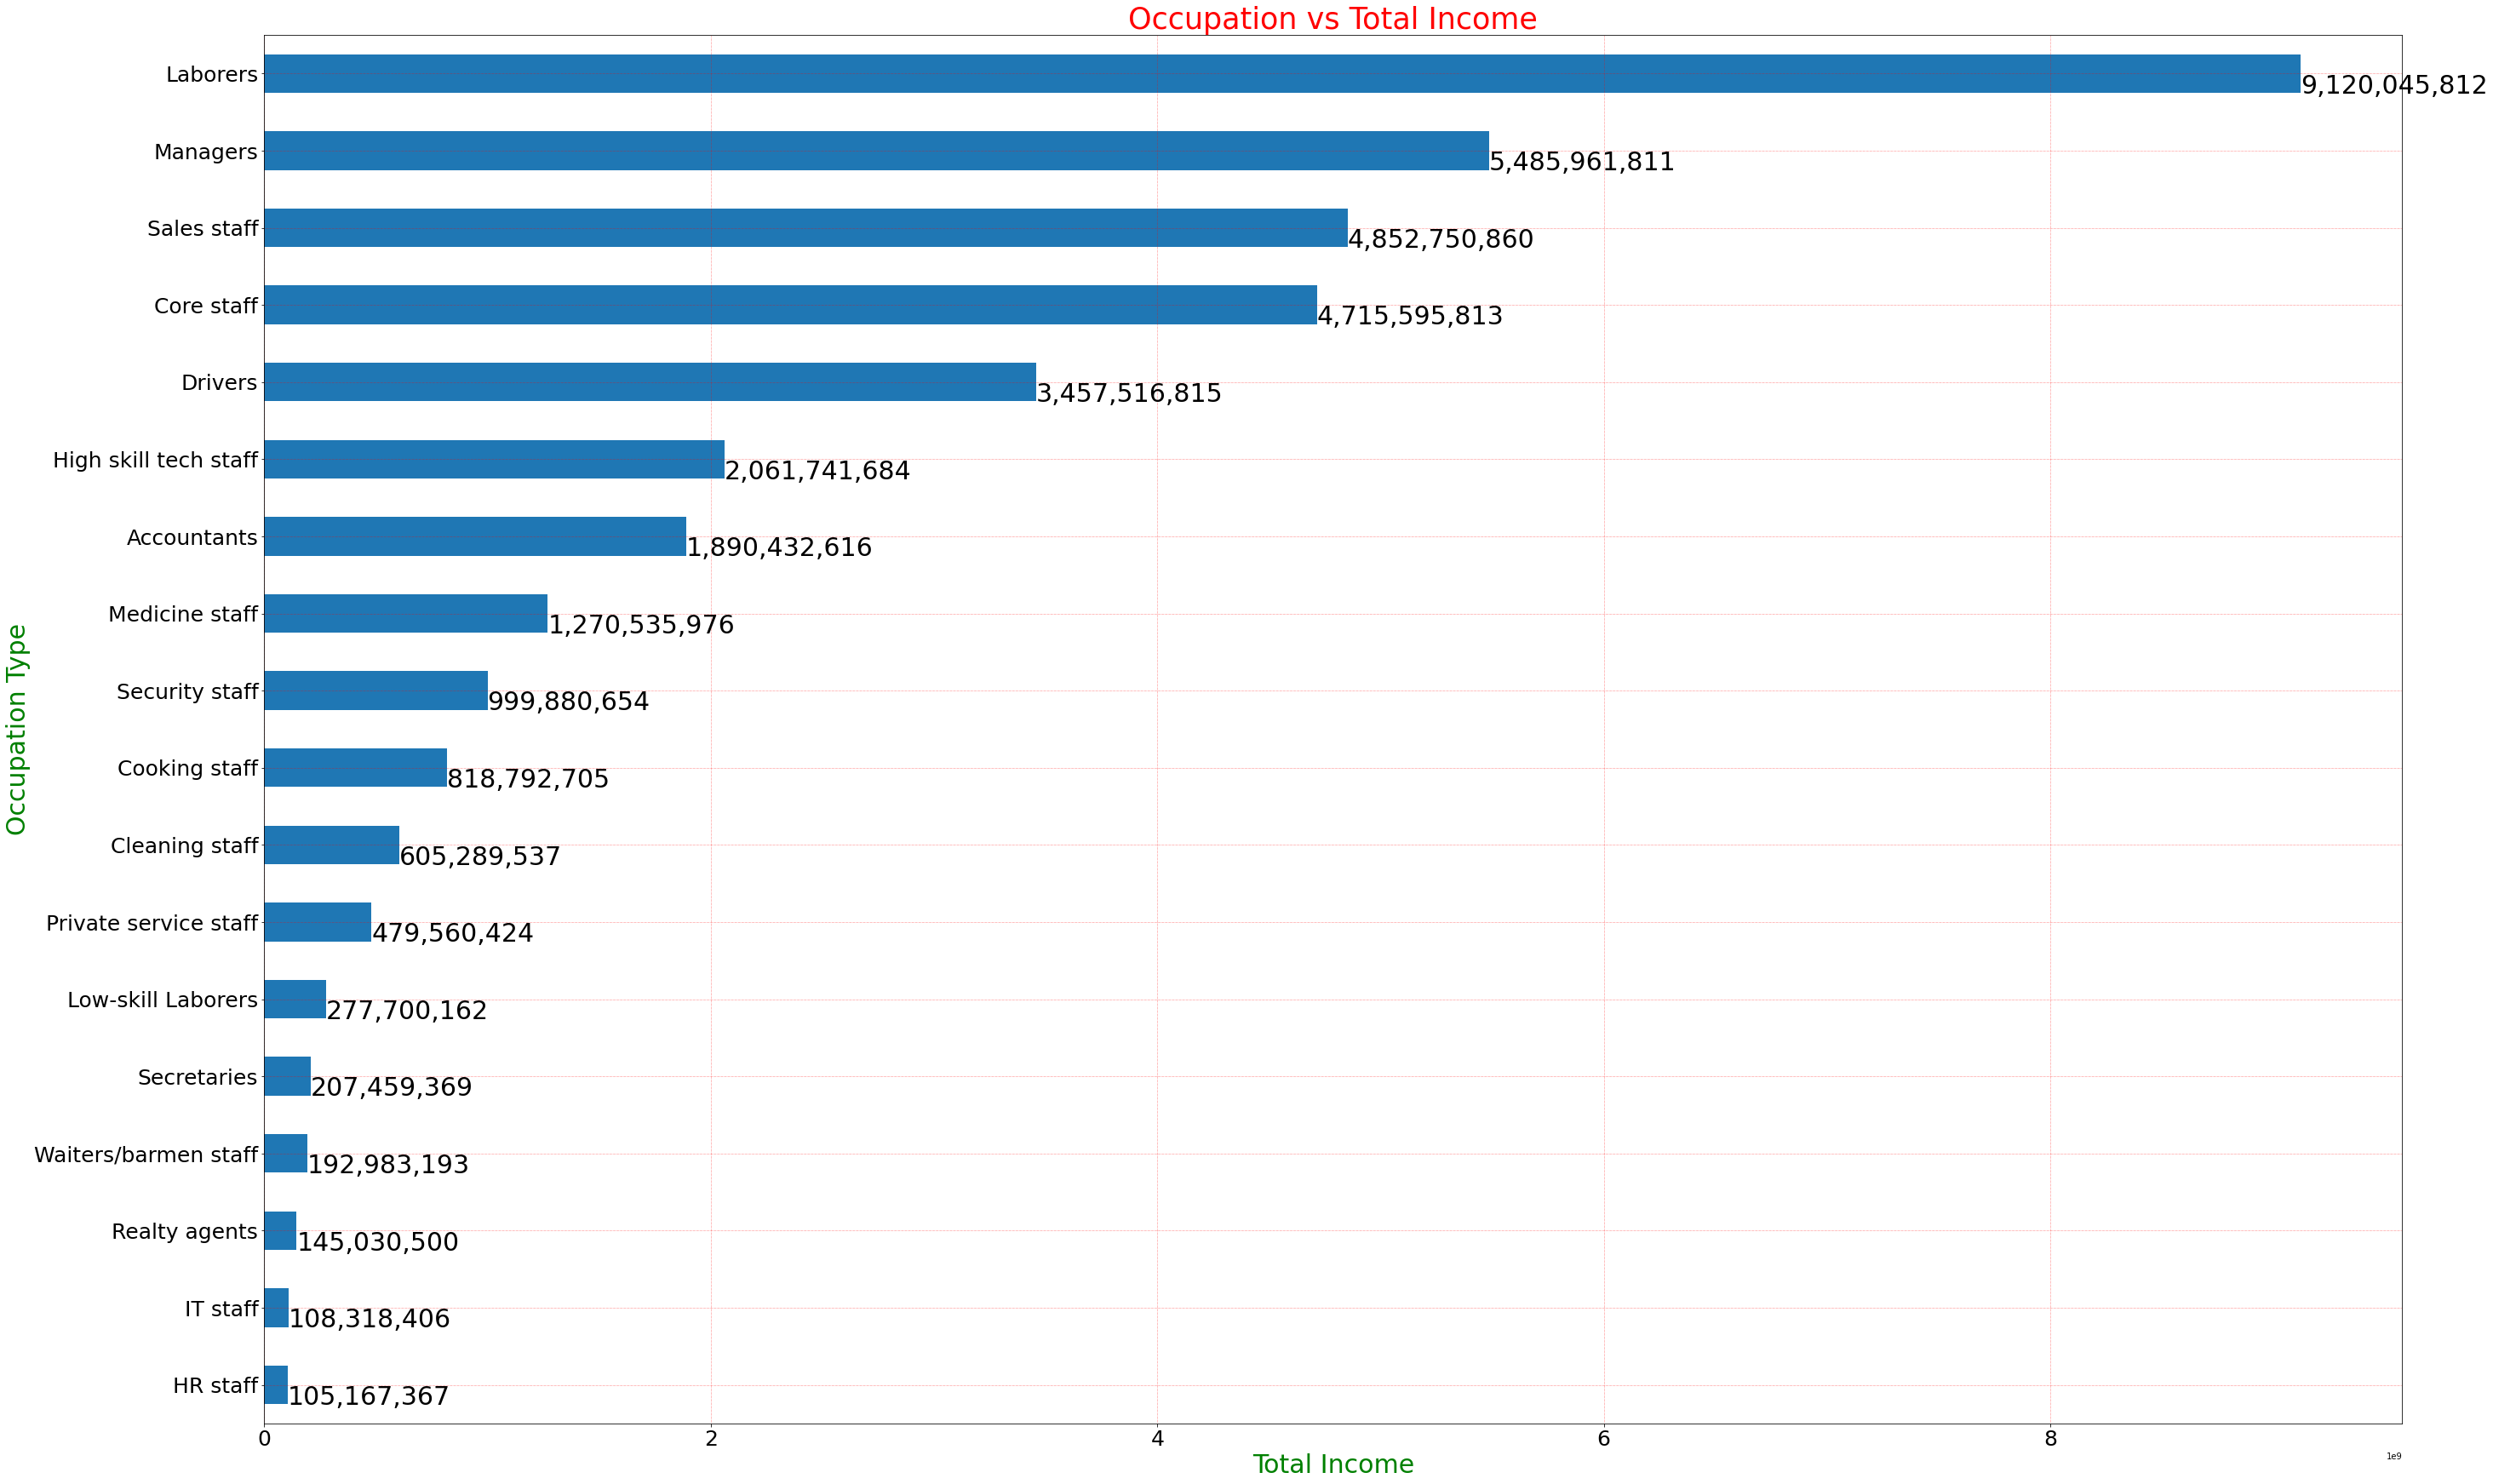

In [74]:
# Assuming 'inp0_cp' is your DataFrame
# 'hue_column' is the column you want to use as a hue parameter

# Group by both 'OCCUPATION_TYPE' and 'hue_column', and calculate the sum of 'AMT_INCOME_TOTAL'
grouped_data = inp0_cp.groupby(['OCCUPATION_TYPE'])['AMT_INCOME_TOTAL'].sum()

# Sort the values by the sum of 'AMT_INCOME_TOTAL' for each 'OCCUPATION_TYPE'
sorted_data = grouped_data.sort_values(ascending=True)

# Create a horizontal bar plot
plt.figure(figsize=(45, 30))
sorted_data.plot(kind='barh')
plt.title('Occupation vs Total Income', fontdict={'color': 'r', 'size': 35})
plt.xlabel('Total Income', fontdict={'color': 'g', 'size': 30})
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('Occupation Type', fontdict={'color': 'g', 'size': 30})
plt.grid(color='r', linestyle=':', linewidth=0.5, which='major')

# Add labels to the bars
for i, val in enumerate(sorted_data):
    plt.text(val, i, f'{val:,.0f}', va='top', fontsize=30, color='k')

# Add a legend for the 'hue_column'
#handles, labels = plt.gca().get_legend_handles_labels()
#plt.legend(handles, labels, title='Hue Parameter', fontsize=20, title_fontsize=20)

plt.show()

- As the number of laborers are higher so, the total income of Laborers will be naturally higher, so instead of taking sum in the aggregated function of group by operation, we are taking Median of Total Income

In [75]:
inp0_cp.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].median().sort_values(ascending=False)

OCCUPATION_TYPE
Managers                 225000.0
Realty agents            180000.0
Drivers                  180000.0
IT staff                 180000.0
Accountants              175500.0
HR staff                 160200.0
Core staff               157500.0
High skill tech staff    157500.0
Laborers                 157500.0
Private service staff    157500.0
Security staff           135000.0
Secretaries              135000.0
Sales staff              135000.0
Waiters/barmen staff     135000.0
Medicine staff           135000.0
Cooking staff            128700.0
Low-skill Laborers       121500.0
Cleaning staff           112500.0
Name: AMT_INCOME_TOTAL, dtype: float64

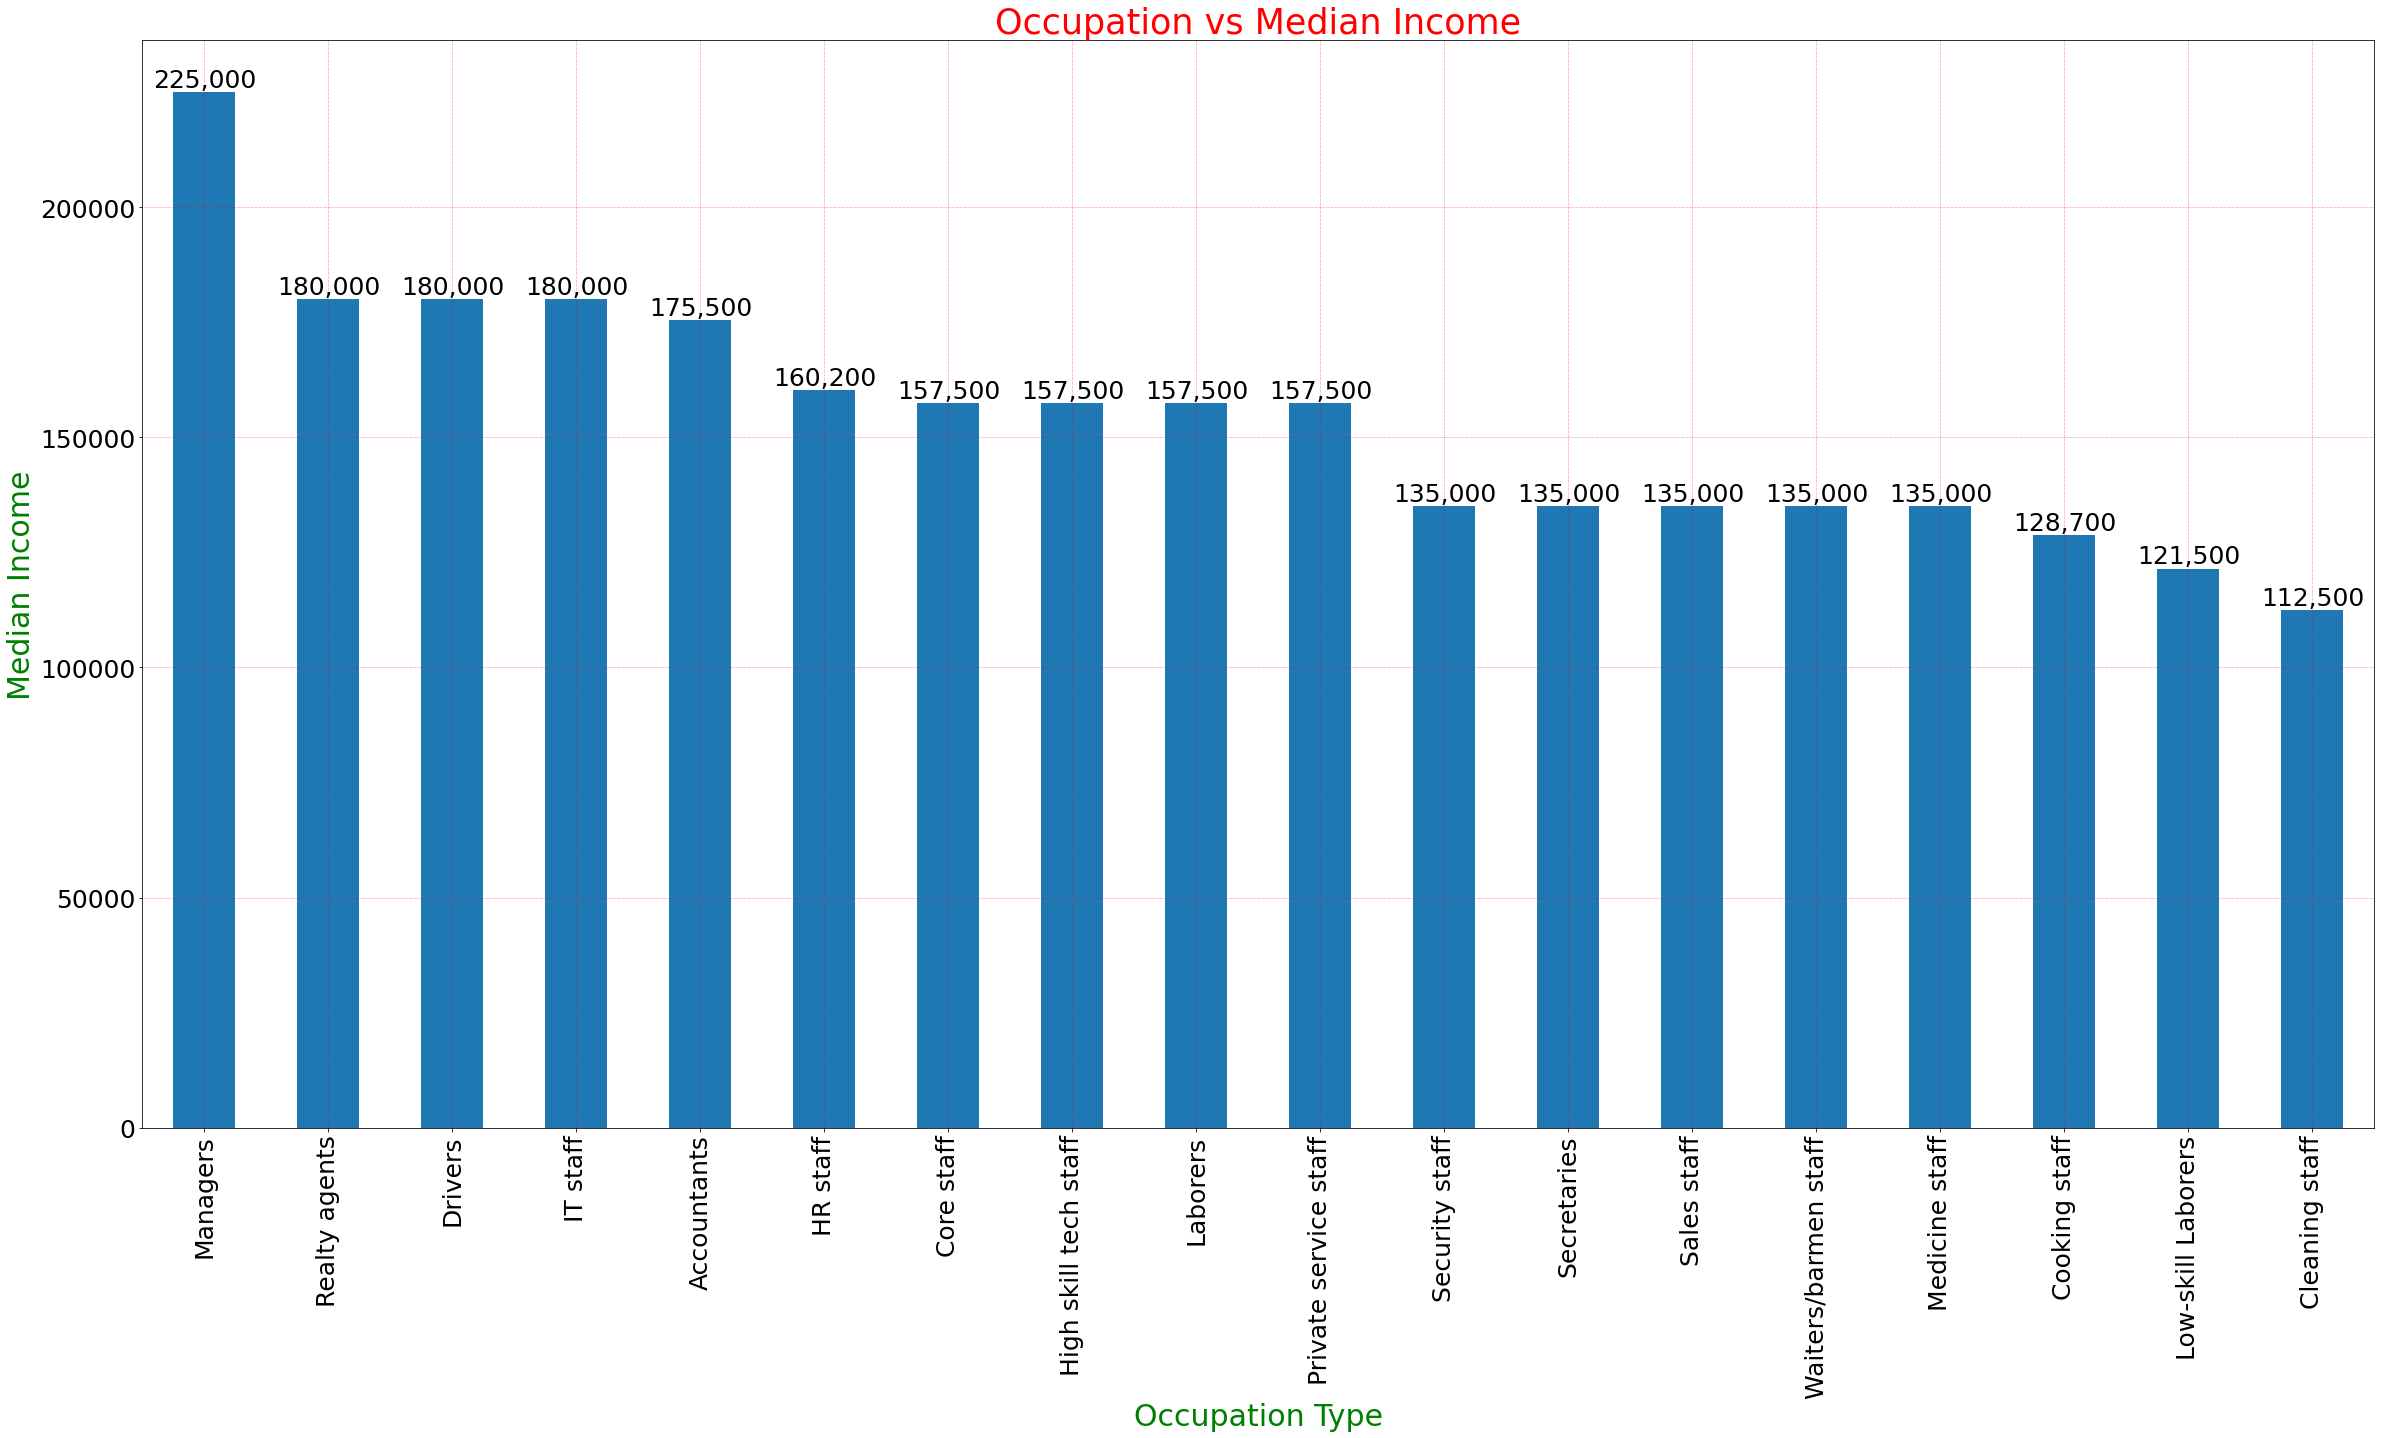

In [76]:
plt.figure(figsize=(40,20))
median_income_by_occupation = inp0_cp.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].median()

# Sort the values in descending order for the bar plot
median_income_by_occupation_sorted = median_income_by_occupation.sort_values(ascending=False)

ax = median_income_by_occupation_sorted.plot(kind='bar')
plt.title('Occupation vs Median Income', fontdict={'color':'r','size':35})
plt.xlabel('Occupation Type', fontdict={'color':'g','size':30})
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('Median Income', fontdict={'color':'g','size':30})
plt.grid(color='r', linestyle=':', linewidth=0.5,which='major')

# Add labels to the bars
for i, v in enumerate(median_income_by_occupation_sorted):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=25)
    
plt.show()

In [77]:
# Finding the index of 'Laborer' class
median_income_by_occupation_sorted.index.get_loc('Laborers')+1

9

#### Checkig the count of payment difficulties and non-difficulties persons grouped by OCCUPATION_TYPE

In [78]:
group_data_count = pd.pivot_table(data=inp0_cp,index='OCCUPATION_TYPE',columns='TARGET',values='AMT_INCOME_TOTAL', 
                                  aggfunc='count')

In [79]:
group_data_count

TARGET,0,1
OCCUPATION_TYPE,,
Accountants,9248,474
Cleaning staff,4179,445
Cooking staff,5293,620
Core staff,25587,1727
Drivers,16384,2101
HR staff,524,34
High skill tech staff,10582,698
IT staff,478,34
Laborers,49013,5820


#### Sorting the count of loan paying difficulty customers across all occupation type

In [80]:
group_data_count.loc[:,1].sort_values(ascending=False)

OCCUPATION_TYPE
Laborers                 5820
Sales staff              3077
Drivers                  2101
Core staff               1727
Managers                 1320
Security staff            718
High skill tech staff     698
Cooking staff             620
Medicine staff            568
Accountants               474
Cleaning staff            445
Low-skill Laborers        359
Private service staff     172
Waiters/barmen staff      152
Secretaries                92
Realty agents              59
IT staff                   34
HR staff                   34
Name: 1, dtype: int64

#### Observation:
--------------------
- There are some missing values in OCCUPATION_TYPE attribute, for these we can say that few persons' professions are unknown might be it has happened during the data collection.
- Though there was a chance of imputing those null instances using the mode but that could make the data biased towards Laborers as the Laborers have higher count.
- Though the Laborers category have highest total income but inspecting the median income of all the categories, it's found that Laborers came at 9th position whereas Managers have highest Median Income.
- Countwise Managers are coming at 5th position as having loan payment difficulties

- From all these observations this OCCUPATION_TYPE and AMT_INCOME_TOTAL seem to be very useful attributes for deciding Loan Payment Difficulty

<span style="color:darkblue; font-weight:bold;">Columns with 40% to 50% Null Values:</span>

In [81]:
null_column_list_40_50_percent

['YEARS_BEGINEXPLUATATION_AVG',
 'FLOORSMAX_AVG',
 'YEARS_BEGINEXPLUATATION_MODE',
 'FLOORSMAX_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'FLOORSMAX_MEDI',
 'TOTALAREA_MODE',
 'EMERGENCYSTATE_MODE']

In [82]:
for i in null_column_list_40_50_percent:
    if inp0_cp[i].dtype != 'object':
        print("The correlation coefficient of "+i+" is :  ",round(inp0_cp[i].corr(inp0_cp['TARGET']),2))

The correlation coefficient of YEARS_BEGINEXPLUATATION_AVG is :   -0.01
The correlation coefficient of FLOORSMAX_AVG is :   -0.04
The correlation coefficient of YEARS_BEGINEXPLUATATION_MODE is :   -0.01
The correlation coefficient of FLOORSMAX_MODE is :   -0.04
The correlation coefficient of YEARS_BEGINEXPLUATATION_MEDI is :   -0.01
The correlation coefficient of FLOORSMAX_MEDI is :   -0.04
The correlation coefficient of TOTALAREA_MODE is :   -0.03


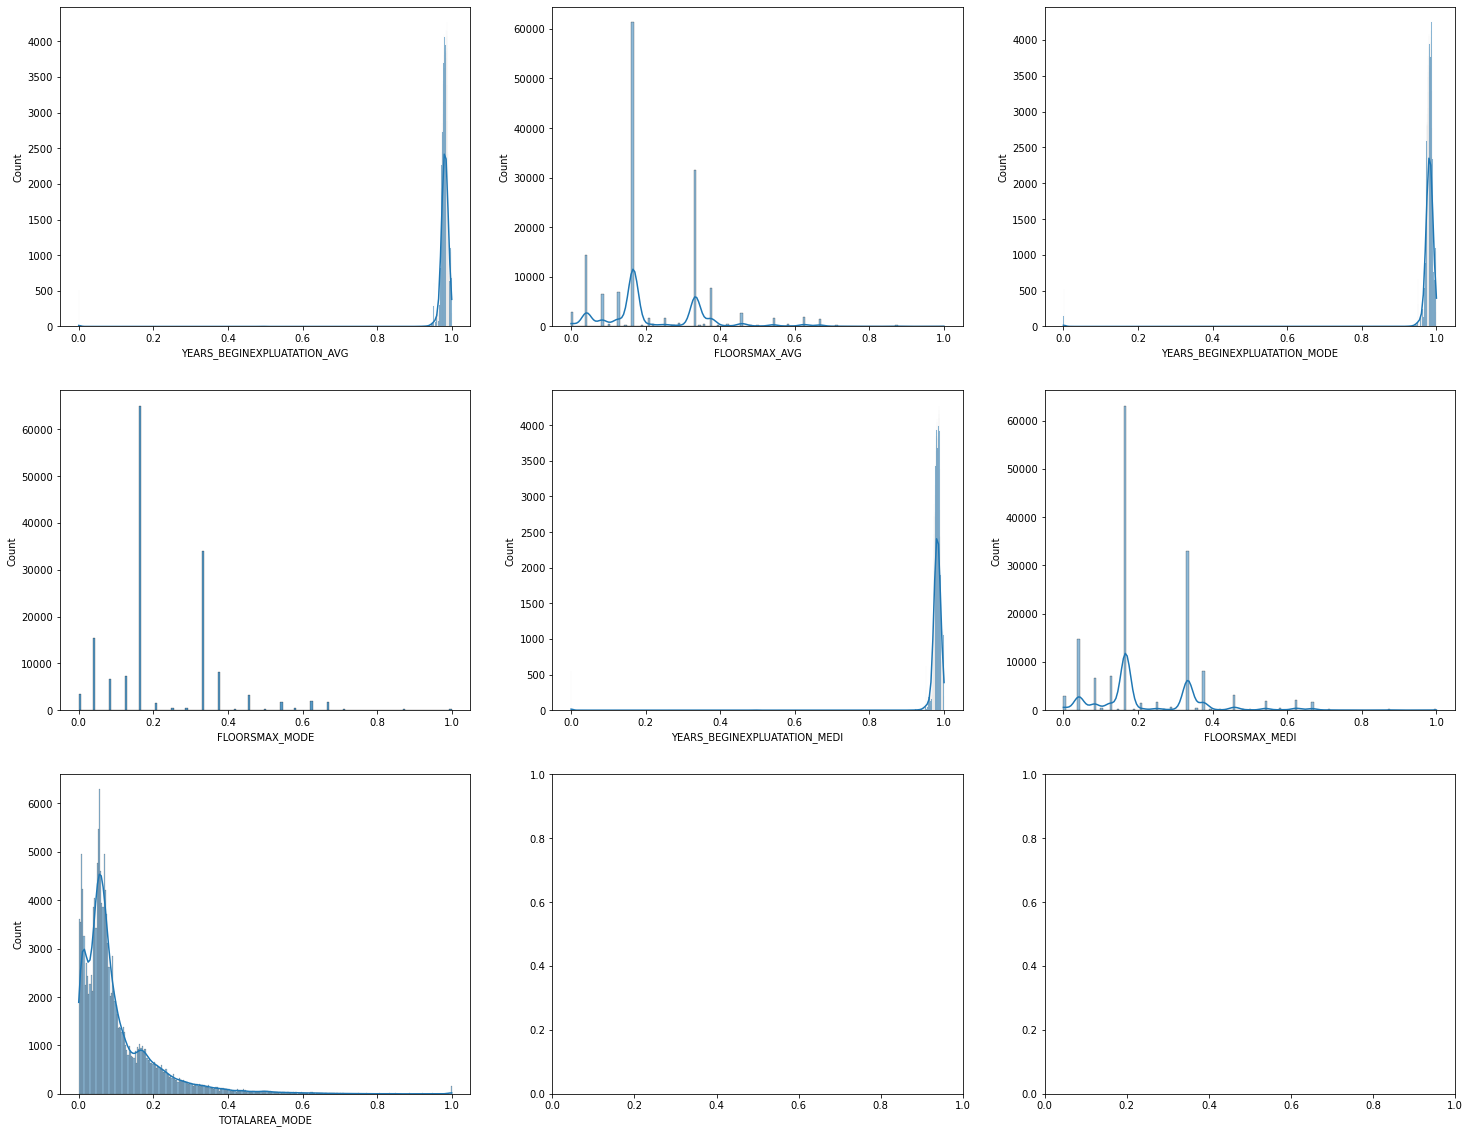

In [83]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25,20))
sns.histplot(inp0_cp['YEARS_BEGINEXPLUATATION_AVG'], kde=True,ax=axes[0,0])
sns.histplot(inp0_cp['FLOORSMAX_AVG'], kde=True,ax=axes[0,1])
sns.histplot(inp0_cp['YEARS_BEGINEXPLUATATION_MODE'], kde=True,ax=axes[0,2])
sns.histplot(inp0_cp['FLOORSMAX_MODE'], ax=axes[1,0])
sns.histplot(inp0_cp['YEARS_BEGINEXPLUATATION_MEDI'], kde=True,ax=axes[1,1])
sns.histplot(inp0_cp['FLOORSMAX_MEDI'], kde=True,ax=axes[1,2])
sns.histplot(inp0_cp['TOTALAREA_MODE'], kde=True,ax=axes[2,0])
plt.show()

- All these attributes are skewed and intuitively don't seem to be much useful for Loan approval (By Intuition). Going forward won't use these attributes

In [84]:
merged_df = pd.merge(inp0_cp, inp1, how='left', on='SK_ID_CURR')

In [85]:
merged_df.shape

(1422721, 156)

In [86]:
subset_df = merged_df[['SK_ID_CURR','YEARS_BEGINEXPLUATATION_AVG','FLOORSMAX_AVG','YEARS_BEGINEXPLUATATION_MODE','FLOORSMAX_MODE',
          'YEARS_BEGINEXPLUATATION_MEDI','FLOORSMAX_MEDI','TOTALAREA_MODE','TARGET','NAME_CONTRACT_STATUS']]

In [87]:
subset_df['NAME_CONTRACT_STATUS'].unique()

array(['Approved', 'Canceled', 'Refused', nan, 'Unused offer'],
      dtype=object)

In [88]:
subset_df['NAME_CONTRACT_STATUS'].value_counts()

Approved        882031
Canceled        258210
Refused         244113
Unused offer     22666
Name: NAME_CONTRACT_STATUS, dtype: int64

In [89]:
subset_df['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100

Approved        62.687879
Canceled        18.351552
Refused         17.349647
Unused offer     1.610922
Name: NAME_CONTRACT_STATUS, dtype: float64

In [90]:
subset_df['TARGET'].value_counts(normalize=True)

0    0.913627
1    0.086373
Name: TARGET, dtype: float64

In [91]:
subset_df

,SK_ID_CURR,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,TARGET,NAME_CONTRACT_STATUS
0,100002,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,1,Approved
1,100003,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,0,Approved
2,100003,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,0,Approved
3,100003,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,0,Approved
4,100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
...,...,...,...,...,...,...,...,...,...,...
1422716,456255,0.9881,0.3750,0.9881,0.3750,0.9881,0.3750,0.0718,0,Approved
1422717,456255,0.9881,0.3750,0.9881,0.3750,0.9881,0.3750,0.0718,0,Refused
1422718,456255,0.9881,0.3750,0.9881,0.3750,0.9881,0.3750,0.0718,0,Refused
1422719,456255,0.9881,0.3750,0.9881,0.3750,0.9881,0.3750,0.0718,0,Approved


In [92]:
subset_df_1 = subset_df[(subset_df['NAME_CONTRACT_STATUS'] == 'Approved') & (subset_df['YEARS_BEGINEXPLUATATION_AVG'].isna()) 
         & (subset_df['FLOORSMAX_AVG'].isna()) & (subset_df['YEARS_BEGINEXPLUATATION_MODE'].isna())
         & (subset_df['FLOORSMAX_MODE'].isna()) & (subset_df['YEARS_BEGINEXPLUATATION_MEDI'].isna())
         & (subset_df['FLOORSMAX_MEDI'].isna()) & (subset_df['TOTALAREA_MODE'].isna())]

In [93]:
subset_df_1

,SK_ID_CURR,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,TARGET,NAME_CONTRACT_STATUS
4,100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
5,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
7,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
8,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
9,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
...,...,...,...,...,...,...,...,...,...,...
1422700,456247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
1422701,456248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
1422702,456248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved
1422703,456248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Approved


In [94]:
subset_df_1.shape

(424039, 10)

In [95]:
(len(subset_df_1) / len(subset_df) )* 100

29.804789554663213

#### Observation:
-------------------
- To prove the importance of these variables merged 'inp0_cp' dataframe to the previous application dataframe, where it was found that previously around 30% customers had null values for these attributes but loan had been approved for them.
- Going forward will be deleting these columns

<span style="color:darkgreen; font-weight:bold;">Dropping the columns which have 40% to 50% Null values</span>

In [96]:
inp0_cp.drop(columns=['YEARS_BEGINEXPLUATATION_AVG','FLOORSMAX_AVG','YEARS_BEGINEXPLUATATION_MODE',
                     'FLOORSMAX_MODE','YEARS_BEGINEXPLUATATION_MEDI','FLOORSMAX_MEDI','TOTALAREA_MODE'], axis=1, inplace=True)

In [97]:
inp0_cp.shape

(305195, 113)

<span style="color:darkblue; font-weight:bold;">Columns with 50% to 60% Null Values:</span>

In [98]:
len(null_column_list_50_60_percent)

24

In [99]:
null_column_list_50_60_percent

['EXT_SOURCE_1',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'LANDAREA_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'LANDAREA_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAREA_MEDI',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE']

#### EXT_SOURCE_1: This column has already been handled

#### APARTMENTS_AVG

In [100]:
(inp0_cp['APARTMENTS_AVG'].isna().sum()/ len(inp0_cp) )*100

50.80063565916873

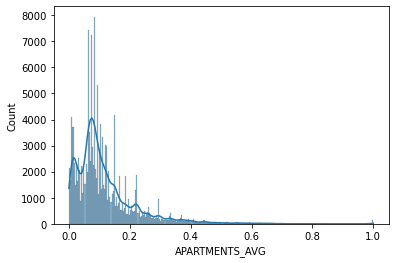

In [101]:
sns.histplot(x='APARTMENTS_AVG', data=inp0_cp, kde=True)
plt.show()

<AxesSubplot:xlabel='APARTMENTS_AVG'>

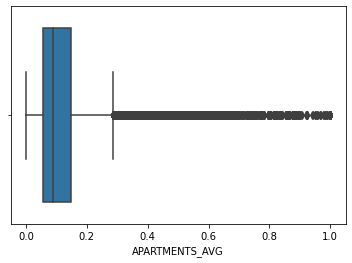

In [102]:
sns.boxplot(x='APARTMENTS_AVG', data=inp0_cp)

In [103]:
inp0_cp['TARGET'].corr(inp0_cp['APARTMENTS_AVG'])

-0.029662914032151422

In [104]:
subset_df1 = merged_df[['SK_ID_CURR','APARTMENTS_AVG','TARGET','NAME_CONTRACT_STATUS','BASEMENTAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'LANDAREA_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'LANDAREA_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAREA_MEDI',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE']]

In [105]:
subset_df1

,SK_ID_CURR,APARTMENTS_AVG,TARGET,NAME_CONTRACT_STATUS,BASEMENTAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,...,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,WALLSMATERIAL_MODE
0,100002,0.0247,1,Approved,0.0369,0.00,0.0690,0.0369,0.0190,0.0000,...,0.0,0.0250,0.0369,0.00,0.0690,0.0375,0.0193,0.00,block of flats,"Stone, brick"
1,100003,0.0959,0,Approved,0.0529,0.08,0.0345,0.0130,0.0549,0.0098,...,0.0,0.0968,0.0529,0.08,0.0345,0.0132,0.0558,0.01,block of flats,Block
2,100003,0.0959,0,Approved,0.0529,0.08,0.0345,0.0130,0.0549,0.0098,...,0.0,0.0968,0.0529,0.08,0.0345,0.0132,0.0558,0.01,block of flats,Block
3,100003,0.0959,0,Approved,0.0529,0.08,0.0345,0.0130,0.0549,0.0098,...,0.0,0.0968,0.0529,0.08,0.0345,0.0132,0.0558,0.01,block of flats,Block
4,100004,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422716,456255,0.0742,0,Approved,0.0526,0.08,0.0690,NaN,0.0791,0.0000,...,0.0,0.0749,0.0526,0.08,0.0690,NaN,0.0805,0.00,block of flats,Panel
1422717,456255,0.0742,0,Refused,0.0526,0.08,0.0690,NaN,0.0791,0.0000,...,0.0,0.0749,0.0526,0.08,0.0690,NaN,0.0805,0.00,block of flats,Panel
1422718,456255,0.0742,0,Refused,0.0526,0.08,0.0690,NaN,0.0791,0.0000,...,0.0,0.0749,0.0526,0.08,0.0690,NaN,0.0805,0.00,block of flats,Panel
1422719,456255,0.0742,0,Approved,0.0526,0.08,0.0690,NaN,0.0791,0.0000,...,0.0,0.0749,0.0526,0.08,0.0690,NaN,0.0805,0.00,block of flats,Panel


In [106]:
subset_df1['TARGET'].value_counts(normalize=True)

0    0.913627
1    0.086373
Name: TARGET, dtype: float64

In [107]:
subset_df1['NAME_CONTRACT_STATUS'].value_counts()

Approved        882031
Canceled        258210
Refused         244113
Unused offer     22666
Name: NAME_CONTRACT_STATUS, dtype: int64

In [108]:
subset_df1['NAME_CONTRACT_STATUS'].value_counts(normalize=True)

Approved        0.626879
Canceled        0.183516
Refused         0.173496
Unused offer    0.016109
Name: NAME_CONTRACT_STATUS, dtype: float64

In [109]:
null_column_list_50_60_percent

['EXT_SOURCE_1',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'LANDAREA_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'LANDAREA_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAREA_MEDI',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE']

In [110]:
col1 = ['APARTMENTS_AVG','BASEMENTAREA_AVG','ELEVATORS_AVG','ENTRANCES_AVG','LANDAREA_AVG','LIVINGAREA_AVG','NONLIVINGAREA_AVG',
        'APARTMENTS_MODE','BASEMENTAREA_MODE','ELEVATORS_MODE','ENTRANCES_MODE','LANDAREA_MODE','LIVINGAREA_MODE','NONLIVINGAREA_MODE',
        'APARTMENTS_MEDI','BASEMENTAREA_MEDI','ELEVATORS_MEDI','ENTRANCES_MEDI','LANDAREA_MEDI','LIVINGAREA_MEDI','NONLIVINGAREA_MEDI',
        'HOUSETYPE_MODE','WALLSMATERIAL_MODE']

In [111]:
len(col1)

23

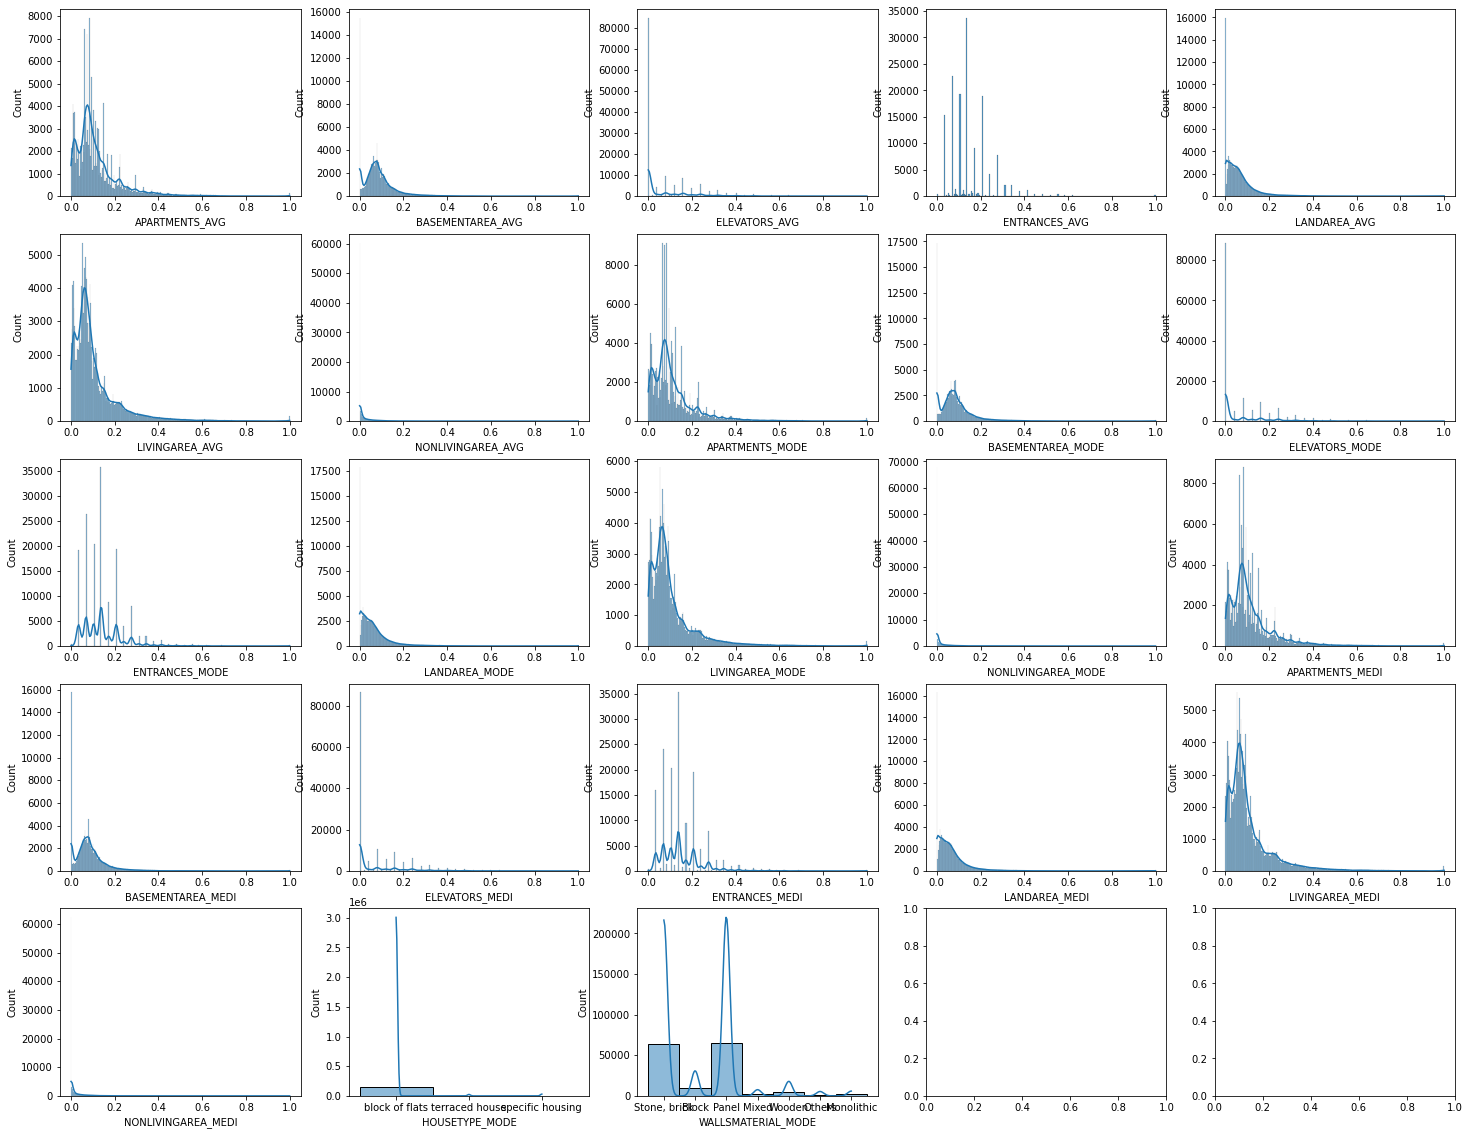

In [112]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25,20))
sns.histplot(inp0_cp['APARTMENTS_AVG'], kde=True,ax=axes[0,0])
sns.histplot(inp0_cp['BASEMENTAREA_AVG'], kde=True,ax=axes[0,1])
sns.histplot(inp0_cp['ELEVATORS_AVG'], kde=True,ax=axes[0,2])
sns.histplot(inp0_cp['ENTRANCES_AVG'], ax=axes[0,3])
sns.histplot(inp0_cp['LANDAREA_AVG'], kde=True,ax=axes[0,4])
sns.histplot(inp0_cp['LIVINGAREA_AVG'], kde=True,ax=axes[1,0])
sns.histplot(inp0_cp['NONLIVINGAREA_AVG'], kde=True,ax=axes[1,1])
sns.histplot(inp0_cp['APARTMENTS_MODE'], kde=True,ax=axes[1,2])
sns.histplot(inp0_cp['BASEMENTAREA_MODE'], kde=True,ax=axes[1,3])
sns.histplot(inp0_cp['ELEVATORS_MODE'], kde=True,ax=axes[1,4])
sns.histplot(inp0_cp['ENTRANCES_MODE'], kde=True,ax=axes[2,0])
sns.histplot(inp0_cp['LANDAREA_MODE'], kde=True,ax=axes[2,1])
sns.histplot(inp0_cp['LIVINGAREA_MODE'], kde=True,ax=axes[2,2])
sns.histplot(inp0_cp['NONLIVINGAREA_MODE'], kde=True,ax=axes[2,3])
sns.histplot(inp0_cp['APARTMENTS_MEDI'], kde=True,ax=axes[2,4])
sns.histplot(inp0_cp['BASEMENTAREA_MEDI'], kde=True,ax=axes[3,0])
sns.histplot(inp0_cp['ELEVATORS_MEDI'], kde=True,ax=axes[3,1])
sns.histplot(inp0_cp['ENTRANCES_MEDI'], kde=True,ax=axes[3,2])
sns.histplot(inp0_cp['LANDAREA_MEDI'], kde=True,ax=axes[3,3])
sns.histplot(inp0_cp['LIVINGAREA_MEDI'], kde=True,ax=axes[3,4])
sns.histplot(inp0_cp['NONLIVINGAREA_MEDI'], kde=True,ax=axes[4,0])
sns.histplot(inp0_cp['HOUSETYPE_MODE'], kde=True,ax=axes[4,1])
sns.histplot(inp0_cp['WALLSMATERIAL_MODE'], kde=True,ax=axes[4,2])

plt.show()

- All of the attributes ave skewed distribution. So we can take log transformation of them. But before doing that a small analysis needs to run to check even if these are important attributes

In [113]:
subset_df_2 = subset_df1[(subset_df['NAME_CONTRACT_STATUS'] == 'Approved') & (subset_df1['APARTMENTS_AVG'].isna()) 
         & (subset_df1['BASEMENTAREA_AVG'].isna()) & (subset_df1['ELEVATORS_AVG'].isna())
         & (subset_df1['ENTRANCES_AVG'].isna()) & (subset_df1['LANDAREA_AVG'].isna())
         & (subset_df1['LIVINGAREA_AVG'].isna()) & (subset_df1['NONLIVINGAREA_AVG'].isna()) & (subset_df1['APARTMENTS_MODE'].isna())
        & (subset_df1['BASEMENTAREA_MODE'].isna()) & (subset_df1['ELEVATORS_MODE'].isna()) & (subset_df1['ENTRANCES_MODE'].isna())
        & (subset_df1['LANDAREA_MODE'].isna()) & (subset_df1['LIVINGAREA_MODE'].isna()) & (subset_df1['NONLIVINGAREA_MODE'].isna())
        & (subset_df1['APARTMENTS_MEDI'].isna()) & (subset_df1['BASEMENTAREA_MEDI'].isna()) & (subset_df1['ELEVATORS_MEDI'].isna())
        & (subset_df1['ENTRANCES_MEDI'].isna()) & (subset_df1['LANDAREA_MEDI'].isna()) & (subset_df1['LIVINGAREA_MEDI'].isna())
        & (subset_df1['NONLIVINGAREA_MEDI'].isna()) & (subset_df1['HOUSETYPE_MODE'].isna()) & subset_df1['WALLSMATERIAL_MODE'].isna()]

In [114]:
subset_df_2

,SK_ID_CURR,APARTMENTS_AVG,TARGET,NAME_CONTRACT_STATUS,BASEMENTAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,...,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,WALLSMATERIAL_MODE
4,100004,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,100006,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,100006,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,100006,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,100006,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422700,456247,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1422701,456248,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1422702,456248,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1422703,456248,NaN,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
(len(subset_df_2) / len(subset_df1) )* 100

29.94627899637385

#### Observation:
-------------------
- To prove the importance of these variables, we merged application datset to the previous_application datset, where it was found that previously arouncd 30% customers had null values for these attributes but loan had been approved for them.
- Going forward will be deleting these columns

### Taking a subset from inp0_cp where the columns of col1 list will not be present

In [116]:
new_df = inp0_cp.drop(columns = col1)

In [117]:
new_df.shape

(305195, 90)

In [118]:
new_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'FLOORSMIN_AVG', 

<span style="color:darkblue; font-weight:bold;">Columns with 60% to 70% Null Values:</span>

In [119]:
null_column_list_60_70_percent

['OWN_CAR_AGE',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'FLOORSMIN_AVG',
 'LIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'FLOORSMIN_MODE',
 'LIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'FLOORSMIN_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'FONDKAPREMONT_MODE']

In [120]:
len(null_column_list_60_70_percent)

17

In [121]:
new_df['OWN_CAR_AGE'].isnull().sum() / len(new_df) * 100

65.986336604466

##### Checking the distribution of all the columns as these columns are numerical in nature

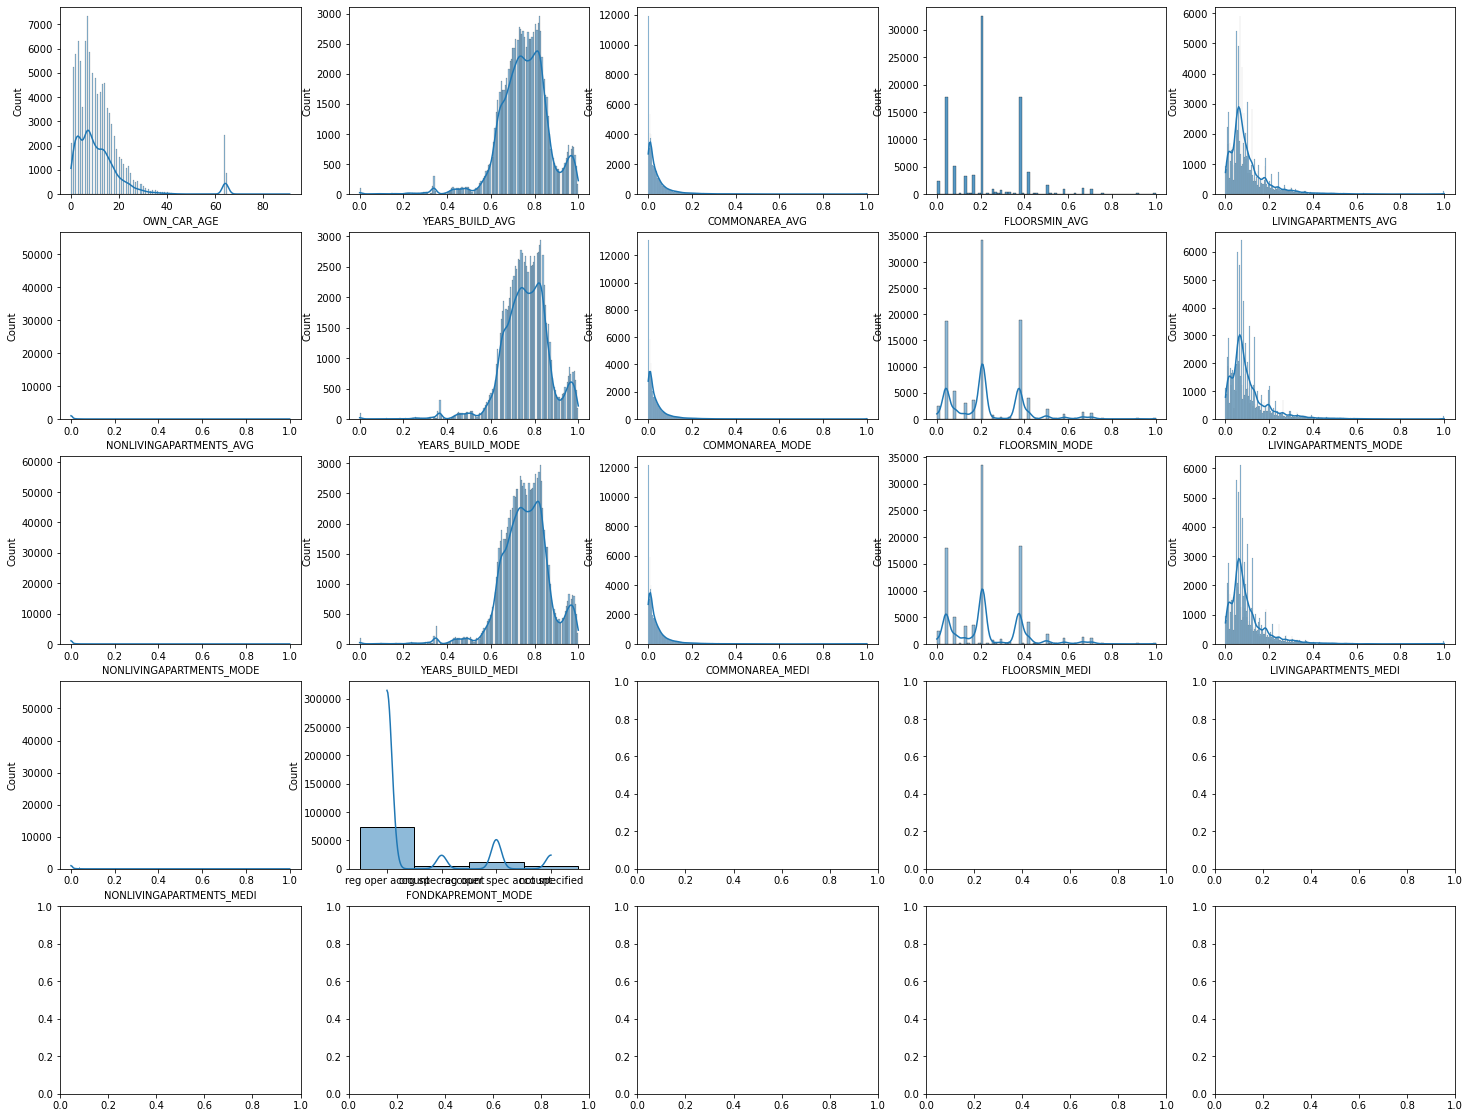

In [122]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25,20))
sns.histplot(inp0_cp['OWN_CAR_AGE'], kde=True,ax=axes[0,0])
sns.histplot(inp0_cp['YEARS_BUILD_AVG'], kde=True,ax=axes[0,1])
sns.histplot(inp0_cp['COMMONAREA_AVG'], kde=True,ax=axes[0,2])
sns.histplot(inp0_cp['FLOORSMIN_AVG'], ax=axes[0,3])
sns.histplot(inp0_cp['LIVINGAPARTMENTS_AVG'], kde=True,ax=axes[0,4])
sns.histplot(inp0_cp['NONLIVINGAPARTMENTS_AVG'], kde=True,ax=axes[1,0])
sns.histplot(inp0_cp['YEARS_BUILD_MODE'], kde=True,ax=axes[1,1])
sns.histplot(inp0_cp['COMMONAREA_MODE'], kde=True,ax=axes[1,2])
sns.histplot(inp0_cp['FLOORSMIN_MODE'], kde=True,ax=axes[1,3])
sns.histplot(inp0_cp['LIVINGAPARTMENTS_MODE'], kde=True,ax=axes[1,4])
sns.histplot(inp0_cp['NONLIVINGAPARTMENTS_MODE'], kde=True,ax=axes[2,0])
sns.histplot(inp0_cp['YEARS_BUILD_MEDI'], kde=True,ax=axes[2,1])
sns.histplot(inp0_cp['COMMONAREA_MEDI'], kde=True,ax=axes[2,2])
sns.histplot(inp0_cp['FLOORSMIN_MEDI'], kde=True,ax=axes[2,3])
sns.histplot(inp0_cp['LIVINGAPARTMENTS_MEDI'], kde=True,ax=axes[2,4])
sns.histplot(inp0_cp['NONLIVINGAPARTMENTS_MEDI'], kde=True,ax=axes[3,0])
sns.histplot(inp0_cp['FONDKAPREMONT_MODE'], kde=True,ax=axes[3,1])

plt.show()

- Few of these columns are normally distributed and few are skewed But as all these columns have more than 60% null value, so better to drop all these columns from the analysis
- Befoe dropping these need to check if even any of these columns have any importance

In [123]:
subset_df_3 = merged_df[['SK_ID_CURR','TARGET','NAME_CONTRACT_STATUS','OWN_CAR_AGE',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'FLOORSMIN_AVG',
 'LIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'FLOORSMIN_MODE',
 'LIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'FLOORSMIN_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'FONDKAPREMONT_MODE']]

In [124]:
subset_df_3

,SK_ID_CURR,TARGET,NAME_CONTRACT_STATUS,OWN_CAR_AGE,YEARS_BUILD_AVG,COMMONAREA_AVG,FLOORSMIN_AVG,LIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,YEARS_BUILD_MODE,COMMONAREA_MODE,FLOORSMIN_MODE,LIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,YEARS_BUILD_MEDI,COMMONAREA_MEDI,FLOORSMIN_MEDI,LIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,FONDKAPREMONT_MODE
0,100002,1,Approved,NaN,0.6192,0.0143,0.1250,0.0202,0.0000,0.6341,0.0144,0.1250,0.022,0.0,0.6243,0.0144,0.1250,0.0205,0.0000,reg oper account
1,100003,0,Approved,NaN,0.7960,0.0605,0.3333,0.0773,0.0039,0.8040,0.0497,0.3333,0.079,0.0,0.7987,0.0608,0.3333,0.0787,0.0039,reg oper account
2,100003,0,Approved,NaN,0.7960,0.0605,0.3333,0.0773,0.0039,0.8040,0.0497,0.3333,0.079,0.0,0.7987,0.0608,0.3333,0.0787,0.0039,reg oper account
3,100003,0,Approved,NaN,0.7960,0.0605,0.3333,0.0773,0.0039,0.8040,0.0497,0.3333,0.079,0.0,0.7987,0.0608,0.3333,0.0787,0.0039,reg oper account
4,100004,0,Approved,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422716,456255,0,Approved,NaN,NaN,0.0176,NaN,NaN,NaN,NaN,0.0178,NaN,NaN,NaN,NaN,0.0177,NaN,NaN,NaN,NaN
1422717,456255,0,Refused,NaN,NaN,0.0176,NaN,NaN,NaN,NaN,0.0178,NaN,NaN,NaN,NaN,0.0177,NaN,NaN,NaN,NaN
1422718,456255,0,Refused,NaN,NaN,0.0176,NaN,NaN,NaN,NaN,0.0178,NaN,NaN,NaN,NaN,0.0177,NaN,NaN,NaN,NaN
1422719,456255,0,Approved,NaN,NaN,0.0176,NaN,NaN,NaN,NaN,0.0178,NaN,NaN,NaN,NaN,0.0177,NaN,NaN,NaN,NaN


In [125]:
subset_df_3['NAME_CONTRACT_STATUS'].value_counts()

Approved        882031
Canceled        258210
Refused         244113
Unused offer     22666
Name: NAME_CONTRACT_STATUS, dtype: int64

In [126]:
subset_df_3['NAME_CONTRACT_STATUS'].value_counts(normalize=True)

Approved        0.626879
Canceled        0.183516
Refused         0.173496
Unused offer    0.016109
Name: NAME_CONTRACT_STATUS, dtype: float64

In [127]:
subset_df_3['TARGET'].value_counts(normalize=True)

0    0.913627
1    0.086373
Name: TARGET, dtype: float64

In [128]:
col2=['OWN_CAR_AGE','YEARS_BUILD_AVG','COMMONAREA_AVG','FLOORSMIN_AVG','LIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_AVG',
      'YEARS_BUILD_MODE','COMMONAREA_MODE','FLOORSMIN_MODE','LIVINGAPARTMENTS_MODE','NONLIVINGAPARTMENTS_MODE',
      'YEARS_BUILD_MEDI','COMMONAREA_MEDI','FLOORSMIN_MEDI','LIVINGAPARTMENTS_MEDI','NONLIVINGAPARTMENTS_MEDI','FONDKAPREMONT_MODE']

In [129]:
subset_df_4 = subset_df_3[(subset_df['NAME_CONTRACT_STATUS'] == 'Approved') & (subset_df_3['OWN_CAR_AGE'].isna()) 
         & (subset_df_3['YEARS_BUILD_AVG'].isna()) & (subset_df_3['COMMONAREA_AVG'].isna())
         & (subset_df_3['FLOORSMIN_AVG'].isna()) & (subset_df_3['LIVINGAPARTMENTS_AVG'].isna()) & (subset_df_3['NONLIVINGAPARTMENTS_AVG'].isna()) 
        & (subset_df_3['YEARS_BUILD_MODE'].isna()) & (subset_df_3['COMMONAREA_MODE'].isna()) & (subset_df_3['FLOORSMIN_MODE'].isna()) & (subset_df_3['LIVINGAPARTMENTS_MODE'].isna())
        & (subset_df_3['NONLIVINGAPARTMENTS_MODE'].isna()) & (subset_df_3['YEARS_BUILD_MEDI'].isna()) & (subset_df_3['COMMONAREA_MEDI'].isna())
        & (subset_df_3['FLOORSMIN_MEDI'].isna()) & (subset_df_3['LIVINGAPARTMENTS_MEDI'].isna()) & (subset_df_3['NONLIVINGAPARTMENTS_MEDI'].isna())
        & (subset_df_3['FONDKAPREMONT_MODE'].isna())]

In [130]:
subset_df_4

,SK_ID_CURR,TARGET,NAME_CONTRACT_STATUS,OWN_CAR_AGE,YEARS_BUILD_AVG,COMMONAREA_AVG,FLOORSMIN_AVG,LIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,YEARS_BUILD_MODE,COMMONAREA_MODE,FLOORSMIN_MODE,LIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,YEARS_BUILD_MEDI,COMMONAREA_MEDI,FLOORSMIN_MEDI,LIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,FONDKAPREMONT_MODE
5,100006,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,100006,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,100006,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,100006,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,100006,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422702,456248,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1422703,456248,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1422704,456248,0,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1422711,456254,1,Approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
len(subset_df_4)/ len(subset_df_3) * 100

26.54786145702495

#### Observation:
-------------------
- To prove the importance of these variables, we merged application datset to the previous_application datset, where it was found that previously arouncd 27% customers had null values for these attributes but loan had been approved for them.
- Going forward will be deleting these columns except OWN_CAR_AGE

In [132]:
final_df = new_df.drop(columns=col2)

In [133]:
final_df.shape

(305195, 73)

In [134]:
final_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE
count,305195.000000,305195.000000,305195.000000,3.051950e+05,3.051950e+05,305183.000000,3.051950e+05,305195.000000,305195.000000,305195.000000,...,305195.000000,305195.000000,305195.000000,263955.000000,263955.000000,263955.000000,263955.000000,263955.000000,263955.000000,305025.000000
mean,278161.566136,0.080991,0.417130,1.686138e+05,5.992789e+05,27136.779914,5.382241e+05,0.020844,-16041.583165,63873.030269,...,0.000573,0.000495,0.000328,0.006376,0.007001,0.034495,0.267652,0.264810,1.905018,0.509139
std,102784.706235,0.272821,0.722259,2.376614e+05,4.020154e+05,14476.072607,3.689265e+05,0.013808,4362.506087,141325.453196,...,0.023939,0.022238,0.018098,0.083725,0.110639,0.204910,0.915191,0.611256,1.869371,0.149829
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000006
25%,189124.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16573.500000,2.385000e+05,0.010006,-19685.000000,-2761.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.413513
50%,278186.000000,0.000000,0.000000,1.458000e+05,5.147775e+05,24939.000000,4.500000e+05,0.018850,-15756.000000,-1214.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.524419
75%,367116.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34618.500000,6.795000e+05,0.028663,-12419.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.622708
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,8.000000,25.000000,0.878903


In [135]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 305195 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   305195 non-null  int64  
 1   TARGET                       305195 non-null  int64  
 2   NAME_CONTRACT_TYPE           305195 non-null  object 
 3   CODE_GENDER                  305195 non-null  object 
 4   FLAG_OWN_CAR                 305195 non-null  object 
 5   FLAG_OWN_REALTY              305195 non-null  object 
 6   CNT_CHILDREN                 305195 non-null  int64  
 7   AMT_INCOME_TOTAL             305195 non-null  float64
 8   AMT_CREDIT                   305195 non-null  float64
 9   AMT_ANNUITY                  305183 non-null  float64
 10  AMT_GOODS_PRICE              305195 non-null  float64
 11  NAME_TYPE_SUITE              305195 non-null  object 
 12  NAME_INCOME_TYPE             305195 non-null  object 
 13 

In [136]:
final_df['TARGET'].value_counts(normalize=True) * 100

0    91.900916
1     8.099084
Name: TARGET, dtype: float64

In [137]:
len(final_df[final_df['TARGET']==1])

24718

In [138]:
len(final_df[final_df['TARGET']==0])

280477

In [139]:
len(final_df[final_df['TARGET']==0]) / len(final_df[final_df['TARGET']==1])

11.347075006068453

-<span style="color:darkgreen; font-weight:bold">- We can see there are highly class imbalance present for TARGET Variable. </span>

-<span style="color:darkgreen; font-weight:bold">- For further analysis, we can use 'UpSampling' , 'Down Sampling' or 'SMOTE' to handle the class Imabalance in future.</span>

-<span style="color:darkgreen; font-weight:bold">- Number of non-defaulter participants is 11 times higher than defaulters.</span>

-<span style="color:darkgreen; font-weight:bold">- Ideally this should be the case for any bank from business perspective because if the number of defaulters increase then it will be difficult for that banking business to survive</span>

-<span style="color:darkred; font-weight:bold"> Univariate Analysis </span>
#### NAME_CONTRACT_TYPE

In [140]:
final_df['TARGET'].dtype == 'int64'

True

In [141]:
final_df['CODE_GENDER'].dtype == 'O'

True

In [142]:
final_df_col_list = final_df.columns.to_list()

In [143]:
num_col = []
cat_col = []
for i in final_df:
    if (final_df[i].dtype == 'int64') or (final_df[i].dtype == 'float64'):
        num_col.append(i)
    else:
        cat_col.append(i)

if len(final_df_col_list) == len(num_col) + len(cat_col):
    print("No column has been missed")
else:
    print("The column numbers are not matching")

No column has been missed


In [144]:
print(len(num_col))
print(len(cat_col))
print(len(final_df_col_list))

56
17
73


#### Categorical Columns' Analysis:- 

In [145]:
cat_col

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'EMERGENCYSTATE_MODE',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE']

In [146]:
# fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(70,64))
# sns.countplot(x='NAME_CONTRACT_TYPE',data=final_df, hue='TARGET',ax=axes[0,0])
# sns.countplot(x='CODE_GENDER',data=final_df, hue='TARGET',ax=axes[0,1])
# sns.countplot(x='FLAG_OWN_CAR',data=final_df, hue='TARGET',ax=axes[0,2])
# sns.countplot(x='FLAG_OWN_REALTY',data=final_df, hue='TARGET',ax=axes[0,3])
# sns.countplot(x='NAME_TYPE_SUITE',data=final_df, hue='TARGET',ax=axes[0,4])
# sns.countplot(x='NAME_INCOME_TYPE',data=final_df, hue='TARGET',ax=axes[1,0])
# sns.countplot(x='NAME_EDUCATION_TYPE',data=final_df, hue='TARGET',ax=axes[1,1])
# sns.countplot(x='NAME_FAMILY_STATUS',data=final_df, hue='TARGET',ax=axes[1,2])
# sns.countplot(x='NAME_HOUSING_TYPE',data=final_df, hue='TARGET',ax=axes[1,3])
# sns.countplot(x='OCCUPATION_TYPE',data=final_df, hue='TARGET',ax=axes[1,4])
# sns.countplot(x='WEEKDAY_APPR_PROCESS_START',data=final_df, hue='TARGET',ax=axes[2,0])
# sns.countplot(x='ORGANIZATION_TYPE',data=final_df, hue='TARGET',ax=axes[2,1])
# sns.countplot(x='EMERGENCYSTATE_MODE',data=final_df, hue='TARGET',ax=axes[2,2])
# sns.countplot(x='OBS_30_CNT_SOCIAL_CIRCLE',data=final_df, hue='TARGET',ax=axes[2,3])
# sns.countplot(x='DEF_30_CNT_SOCIAL_CIRCLE',data=final_df, hue='TARGET',ax=axes[2,4])
# sns.countplot(x='OBS_60_CNT_SOCIAL_CIRCLE',data=final_df, hue='TARGET',ax=axes[3,0])
# sns.countplot(x='DEF_60_CNT_SOCIAL_CIRCLE',data=final_df, hue='TARGET',ax=axes[3,1])

# plt.show()

#### NAME_CONTRACT_TYPE

In [147]:
final_df['NAME_CONTRACT_TYPE'].value_counts()

Cash loans         277222
Revolving loans     27973
Name: NAME_CONTRACT_TYPE, dtype: int64

In [148]:
final_df['NAME_CONTRACT_TYPE'].isna().sum()

0

In [149]:
final_df['NAME_CONTRACT_TYPE'].value_counts()

Cash loans         277222
Revolving loans     27973
Name: NAME_CONTRACT_TYPE, dtype: int64

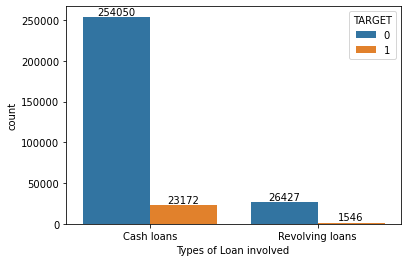

In [150]:
ax=sns.countplot(x='NAME_CONTRACT_TYPE', data=final_df, hue='TARGET')
for label in ax.containers:
    ax.bar_label(label)
plt.xlabel('Types of Loan involved ')
plt.show()

#### Observation:
-------------------
- Customer having difficulty in loan repayment predominantly exists in those participants who are taking Cash Loans.
- By intuition this attribute seems to be an important attribute.
- But as it's an imbalanced dataset, the visualization is biased.
- This Imbalance can be handled by Sampling method (Up-sampling, Down-sampling or SMOTE(Synthetic Minority Over Sampling Technique))

#### FLAG_OWN_CAR

In [151]:
final_df['FLAG_OWN_CAR'].value_counts()

N    201385
Y    103810
Name: FLAG_OWN_CAR, dtype: int64

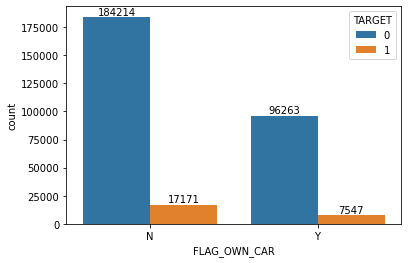

In [152]:
ax = sns.countplot(x='FLAG_OWN_CAR', data=final_df,hue='TARGET')
for label in ax.containers:
    ax.bar_label(label)
plt.show()

#### Observation:
-------------------
- The attribute has defaulter in those customers who don't have car
- Intuitively this attribute also seems to be important because having car sometimes apparently show the financial wellbeing condition [Assumption]
- This is also showing biased visualization because of data imbalance

#### CODE_GENDER

In [153]:
final_df['CODE_GENDER'].value_counts()

F      200986
M      104205
XNA         4
Name: CODE_GENDER, dtype: int64

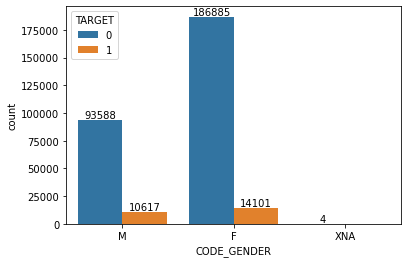

In [154]:
ax=sns.countplot(x='CODE_GENDER', data=final_df,hue='TARGET')
for label in ax.containers:
    ax.bar_label(label)
plt.show()

In [155]:
Gender_Target_count = final_df.groupby(['CODE_GENDER', 'TARGET']).size().unstack()

In [156]:
Gender_Target_count

TARGET,0,1
CODE_GENDER,,
F,186885.0,14101.0
M,93588.0,10617.0
XNA,4.0,NaN


#### Observation:
------------------
- We can't say anything such as Male customers have the higher chance of being defaulter or female customers or XNA have higher chance of being deaulter.
- This attribute can be dropped for further analysis

In [157]:
#Gender_Target_count.plot(kind='bar', stacked=True)

In [158]:
#pd.pivot_table(data=final_df, index='CODE_GENDER', columns='TARGET',aggfunc='count')

#### FLAG_OWN_REALTY

In [159]:
final_df['FLAG_OWN_REALTY'].value_counts()

Y    212102
N     93093
Name: FLAG_OWN_REALTY, dtype: int64

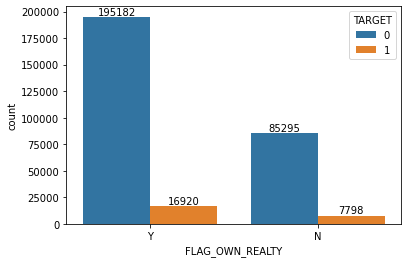

In [160]:
ax=sns.countplot(x='FLAG_OWN_REALTY', data=final_df,hue='TARGET')
for label in ax.containers:
    ax.bar_label(label)
plt.show()

#### Observation:
---------------------
- The number of persons having Realty has higher number of loan defaulter person

#### NAME_TYPE_SUITE

In [161]:
final_df['NAME_TYPE_SUITE'].unique()

array(['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Others'],
      dtype=object)

In [162]:
final_df.groupby(['NAME_TYPE_SUITE', 'TARGET']).size().unstack(fill_value=0)   #Null values have been fulfilled as 0

TARGET,0,1
NAME_TYPE_SUITE,,
Children,3020,241
Family,37049,3007
Others,2626,273
"Spouse, partner",10448,895
Unaccompanied,227334,20302


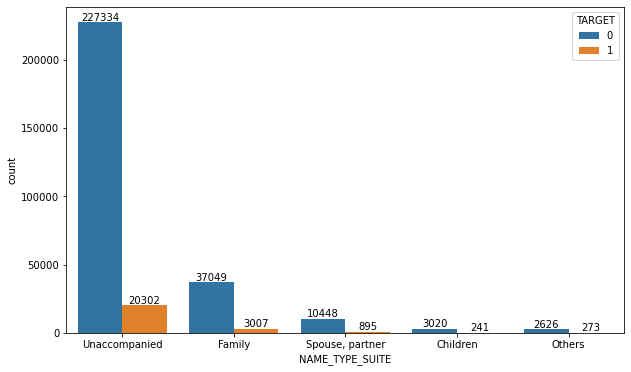

In [163]:
plt.figure(figsize=(10,6))
ax=sns.countplot(x='NAME_TYPE_SUITE', data=final_df, hue='TARGET')
for label in ax.containers:
    ax.bar_label(label)
plt.show()

#### Observation:
-----------------
- Unaccompanied persons have higher number of defaulters

#### NAME_INCOME_TYPE

In [164]:
final_df.NAME_INCOME_TYPE.value_counts()

Working                 157659
Commercial associate     70937
Pensioner                54995
State servant            21553
Unemployed                  19
Student                     17
Businessman                 10
Maternity leave              5
Name: NAME_INCOME_TYPE, dtype: int64

In [165]:
final_df.groupby(['NAME_INCOME_TYPE', 'TARGET']).size().unstack(fill_value=0)   #Null values have been fulfilled as 0

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,10,0
Commercial associate,65606,5331
Maternity leave,3,2
Pensioner,52029,2966
State servant,20312,1241
Student,17,0
Unemployed,11,8
Working,142489,15170


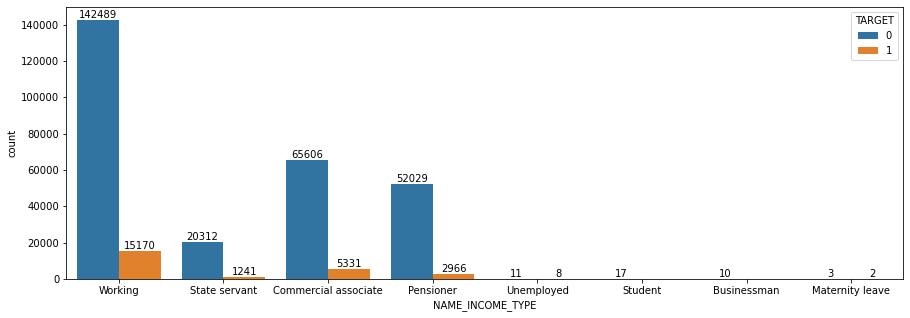

In [166]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x='NAME_INCOME_TYPE', data=final_df, hue='TARGET')
for label in ax.containers:
    ax.bar_label(label)
plt.show()

In [167]:
final_df.groupby(['NAME_INCOME_TYPE'])['AMT_INCOME_TOTAL'].median()

NAME_INCOME_TYPE
Businessman             495000.0
Commercial associate    180000.0
Maternity leave          90000.0
Pensioner               117000.0
State servant           157500.0
Student                 157500.0
Unemployed               63000.0
Working                 135000.0
Name: AMT_INCOME_TOTAL, dtype: float64

#### Observation:
--------------------
- The Working group has highest number of loan defaulters and Commercial associate, Pensioners and State Servants are immediate next to it. But The working group also has a chance to repay the loan as they have some source of income(Assumption)
- Though the Businessman group has highest median income but it doesn't have any defaulter.
- By Intuition this attribute also seems to be important

#### NAME_EDUCATION_TYPE

In [168]:
final_df['NAME_EDUCATION_TYPE'].value_counts()

Secondary / secondary special    217066
Higher education                  73964
Incomplete higher                 10197
Lower secondary                    3805
Academic degree                     163
Name: NAME_EDUCATION_TYPE, dtype: int64

In [169]:
final_df.groupby(['NAME_EDUCATION_TYPE','TARGET']).size().unstack()

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,160,3
Higher education,69980,3984
Incomplete higher,9330,867
Lower secondary,3390,415
Secondary / secondary special,197617,19449


In [170]:
# plt.figure(figsize=(15,5))
# sns.countplot(x='NAME_EDUCATION_TYPE', hue='TARGET', data=final_df)
# plt.show()

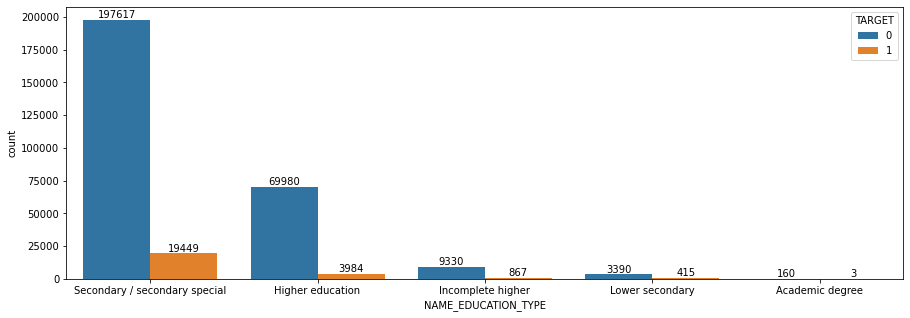

In [171]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x='NAME_EDUCATION_TYPE',hue='TARGET', data=final_df)
#abs_values = final_df['NAME_EDUCATION_TYPE'].value_counts()

for label in ax.containers:
    ax.bar_label(label)
plt.show()

In [172]:
final_df.groupby(['NAME_EDUCATION_TYPE'])['AMT_INCOME_TOTAL'].median()

NAME_EDUCATION_TYPE
Academic degree                  207000.0
Higher education                 180000.0
Incomplete higher                157500.0
Lower secondary                  112500.0
Secondary / secondary special    135000.0
Name: AMT_INCOME_TOTAL, dtype: float64

#### Observation:
------------------
- For Secondary/ Secondary Special education and Higher Education the number of defaulter is more than any other type of education holder
- According to data , Academic Degree has the highest median salary , but the overall loan applicant of that education group is less (only 163) , whereas Higher Education applicants have second highest median salary and Secondary/Secondary Special Education holders have lowest median salary.
- So the loan approver might need to think before giving approval for loan to Higher Education holder and Secondary education holder.

#### NAME_FAMILY_STATUS

In [173]:
final_df['NAME_FAMILY_STATUS'].value_counts()

Married                 195052
Single / not married     44980
Civil marriage           29566
Separated                19623
Widow                    15974
Name: NAME_FAMILY_STATUS, dtype: int64

In [174]:
final_df.groupby(['NAME_FAMILY_STATUS','TARGET']).size().unstack()

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,26619,2947
Married,180266,14786
Separated,18012,1611
Single / not married,40540,4440
Widow,15040,934


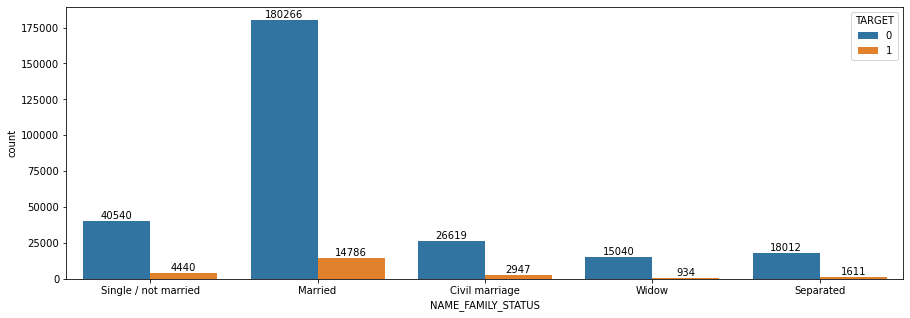

In [175]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x='NAME_FAMILY_STATUS',hue='TARGET', data=final_df)
#abs_values = final_df['NAME_EDUCATION_TYPE'].value_counts()

for label in ax.containers:
    ax.bar_label(label)
plt.show()

In [176]:
final_df.groupby(['NAME_FAMILY_STATUS'])['AMT_INCOME_TOTAL'].median().sort_values(ascending=False)

NAME_FAMILY_STATUS
Separated               157500.0
Married                 153900.0
Civil marriage          153000.0
Single / not married    144000.0
Widow                   130500.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [177]:
#final_df.groupby(['NAME_FAMILY_STATUS'])['AMT_ANNUITY'].median()

#### Observation:
------------------
- The Married persons are highest in the count for taking loan and they have highest number of defaulters present.
- Separated persons have highest median income and their defaulter count is not much w.r.t to the other categories.
- The attribute , by intuition, doesn't seem to be much helpful or useful for deciding any factor for defaulters.
- Good to go with the analysis excluding this attribute(Assumption, marital status doesn't impact much )

#### NAME_HOUSING_TYPE

In [178]:
final_df['NAME_HOUSING_TYPE'].value_counts()

House / apartment      270808
With parents            14733
Municipal apartment     11115
Rented apartment         4841
Office apartment         2591
Co-op apartment          1107
Name: NAME_HOUSING_TYPE, dtype: int64

In [179]:
final_df.groupby(['NAME_HOUSING_TYPE','TARGET']).size().unstack()

TARGET,0,1
NAME_HOUSING_TYPE,,
Co-op apartment,1019,88
House / apartment,249627,21181
Municipal apartment,10165,950
Office apartment,2421,170
Rented apartment,4244,597
With parents,13001,1732


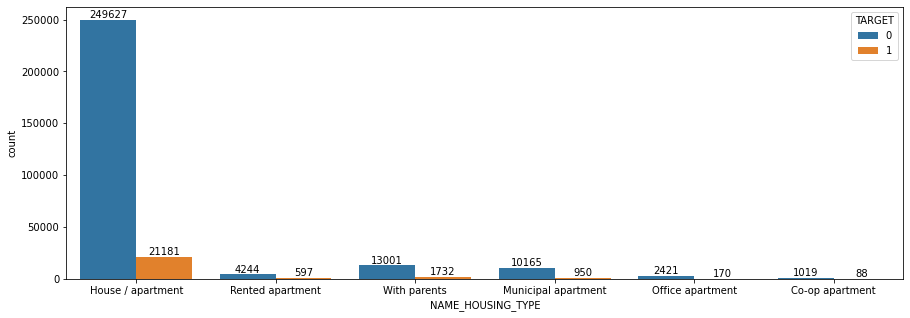

In [180]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x='NAME_HOUSING_TYPE',hue='TARGET', data=final_df)
#abs_values = final_df['NAME_EDUCATION_TYPE'].value_counts()

for label in ax.containers:
    ax.bar_label(label)
plt.show()

In [181]:
final_df.groupby(['NAME_HOUSING_TYPE'])['AMT_INCOME_TOTAL'].median()

NAME_HOUSING_TYPE
Co-op apartment        153000.0
House / apartment      148500.0
Municipal apartment    153000.0
Office apartment       157500.0
Rented apartment       148500.0
With parents           135000.0
Name: AMT_INCOME_TOTAL, dtype: float64

#### Observation:
-------------------
- The participants whoever have applied for loan , maximum are coming under House/Appartment owner. By Assumption, it may be a house loan.
- Even if House/Appartment owners stand at the second point of median salary, they are highest in terms of being defaulter. Also in terms of loan payment, they have a good count.
- Co-operative appartment owners have highest median salary and they are lowest in terms of taking loan. as a result they are lowest in terms of being defaulters.
- The persons who are living with partners have lowest median salary and they have second highest count in terms of being defaulters.
- By intuition, this attribute seems to be very important for deciding Loan approval/ defaulter selection.

#### WEEKDAY_APPR_PROCESS_START

In [182]:
final_df['WEEKDAY_APPR_PROCESS_START'].unique()

array(['WEDNESDAY', 'MONDAY', 'THURSDAY', 'SUNDAY', 'SATURDAY', 'FRIDAY',
       'TUESDAY'], dtype=object)

In [183]:
final_df['WEEKDAY_APPR_PROCESS_START'].value_counts()

TUESDAY      53511
WEDNESDAY    51541
MONDAY       50375
THURSDAY     50181
FRIDAY       49937
SATURDAY     33580
SUNDAY       16070
Name: WEEKDAY_APPR_PROCESS_START, dtype: int64

In [184]:
final_df.groupby(['WEEKDAY_APPR_PROCESS_START','TARGET']).size().unstack()

TARGET,0,1
WEEKDAY_APPR_PROCESS_START,,
FRIDAY,45856,4081
MONDAY,46454,3921
SATURDAY,30923,2657
SUNDAY,14793,1277
THURSDAY,46102,4079
TUESDAY,49030,4481
WEDNESDAY,47319,4222


#### Observation:
------------------
- This attribute doesn't seem to be much useful
(Assumption: The day of week for applying loan doesn't matter a lot for loan approval and marking someone as defaulter)
- Also, there are some participants who applied on Sunday, but as per the regular norm, SUNDAY being treated a holiday, Banking service for applying loan might not be running. The data might have been taken wrongly.
- Going forward this attribute can be dropped from analysis

#### ORGANIZATION_TYPE

In [185]:
final_df['ORGANIZATION_TYPE'].value_counts()

Business Entity Type 3    67420
XNA                       55006
Self-employed             38140
Other                     16575
Medicine                  11102
Business Entity Type 2    10472
Government                10334
School                     8841
Trade: type 7              7781
Kindergarten               6829
Construction               6669
Business Entity Type 1     5933
Transport: type 4          5360
Trade: type 3              3459
Industry: type 9           3333
Industry: type 3           3263
Security                   3222
Housing                    2937
Industry: type 11          2688
Military                   2615
Bank                       2459
Agriculture                2442
Police                     2325
Transport: type 2          2185
Postal                     2143
Security Ministries        1957
Trade: type 2              1877
Restaurant                 1794
Services                   1565
University                 1311
Industry: type 7           1297
Transpor

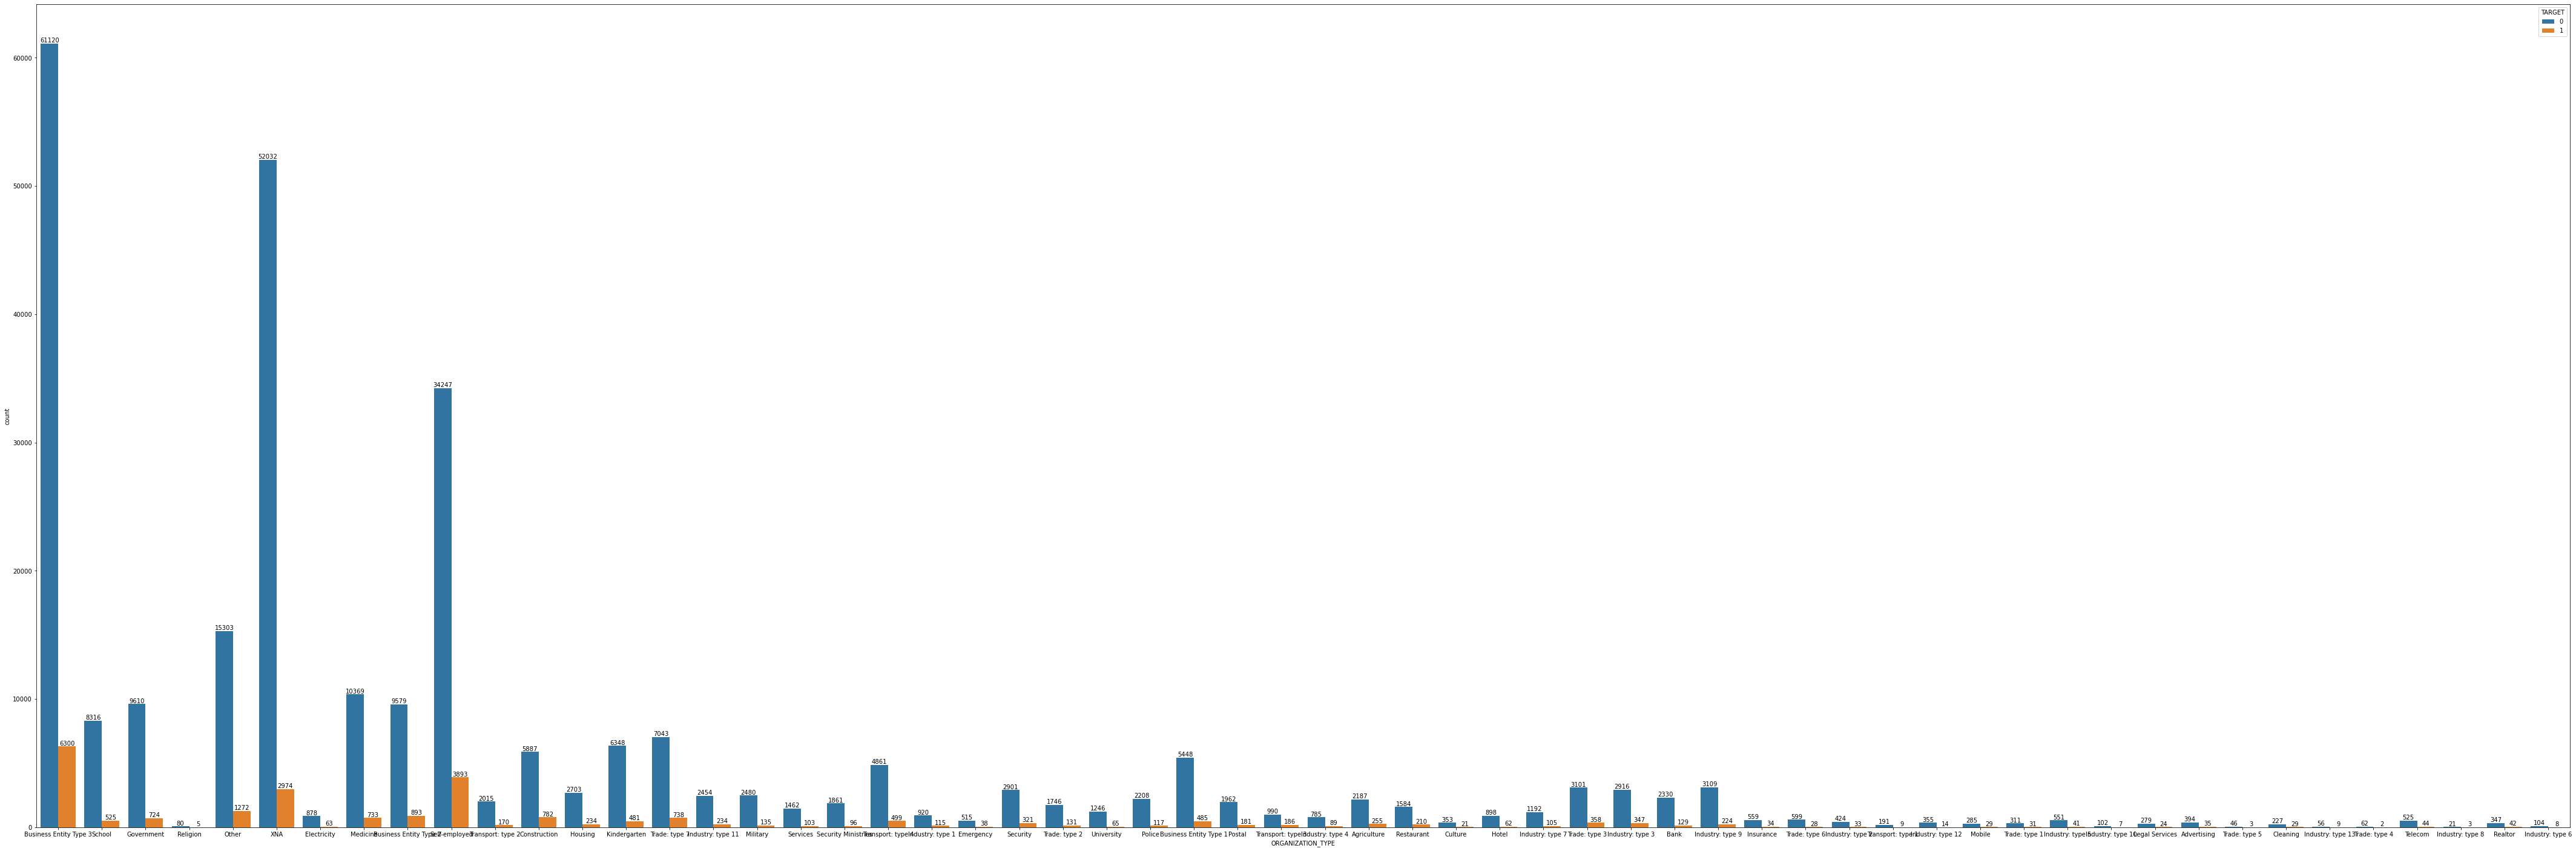

In [186]:
plt.figure(figsize=(75,25))
ax = sns.countplot(x='ORGANIZATION_TYPE',hue='TARGET', data=final_df)
#abs_values = final_df['NAME_EDUCATION_TYPE'].value_counts()

for label in ax.containers:
    ax.bar_label(label)
plt.show()

In [187]:
final_df.groupby(['ORGANIZATION_TYPE','TARGET']).size().unstack()

TARGET,0,1
ORGANIZATION_TYPE,,
Advertising,394,35
Agriculture,2187,255
Bank,2330,129
Business Entity Type 1,5448,485
Business Entity Type 2,9579,893
Business Entity Type 3,61120,6300
Cleaning,227,29
Construction,5887,782
Culture,353,21


#### Observation:
------------------
- The attribute seems to be important because a person's financial condition is dependent on the type of organization he/she works in and its market growth.
- But here in this dataset we can see a lot of categories for this attribute which migt be aproblem while applying mchine learning model on it further because on applying One hot encoding there will be too many variables generated
- Few categories can be merged combined together in order to reduce the variation
- 'XNA' seems to be null ( By Assumption )

In [188]:
final_df['ORGANIZATION_TYPE'].unique()

array(['Business Entity Type 3', 'School', 'Government', 'Religion',
       'Other', 'XNA', 'Electricity', 'Medicine',
       'Business Entity Type 2', 'Self-employed', 'Transport: type 2',
       'Construction', 'Housing', 'Kindergarten', 'Trade: type 7',
       'Industry: type 11', 'Military', 'Services', 'Security Ministries',
       'Transport: type 4', 'Industry: type 1', 'Emergency', 'Security',
       'Trade: type 2', 'University', 'Police', 'Business Entity Type 1',
       'Postal', 'Transport: type 3', 'Industry: type 4', 'Agriculture',
       'Restaurant', 'Culture', 'Hotel', 'Industry: type 7',
       'Trade: type 3', 'Industry: type 3', 'Bank', 'Industry: type 9',
       'Insurance', 'Trade: type 6', 'Industry: type 2',
       'Transport: type 1', 'Industry: type 12', 'Mobile',
       'Trade: type 1', 'Industry: type 5', 'Industry: type 10',
       'Legal Services', 'Advertising', 'Trade: type 5', 'Cleaning',
       'Industry: type 13', 'Trade: type 4', 'Telecom',
       'I

In [189]:
indus = []
trade = []
trans = []
bus = []

for i in final_df['ORGANIZATION_TYPE'].unique().tolist():
    if i[0:8] == 'Industry':
        indus.append(i)
    elif i[0:5] == 'Trade':
        trade.append(i)
    elif i[0:9] == 'Transport':
        trans.append(i)
    elif i[0:15] == 'Business Entity':
        bus.append(i)
        

In [190]:
indus

['Industry: type 11',
 'Industry: type 1',
 'Industry: type 4',
 'Industry: type 7',
 'Industry: type 3',
 'Industry: type 9',
 'Industry: type 2',
 'Industry: type 12',
 'Industry: type 5',
 'Industry: type 10',
 'Industry: type 13',
 'Industry: type 8',
 'Industry: type 6']

In [191]:
trade

['Trade: type 7',
 'Trade: type 2',
 'Trade: type 3',
 'Trade: type 6',
 'Trade: type 1',
 'Trade: type 5',
 'Trade: type 4']

In [192]:
trans

['Transport: type 2',
 'Transport: type 4',
 'Transport: type 3',
 'Transport: type 1']

In [193]:
bus

['Business Entity Type 3', 'Business Entity Type 2', 'Business Entity Type 1']

In [194]:
final_df['ORGANIZATION_TYPE'].replace(indus, 'Industry type', inplace=True)
final_df['ORGANIZATION_TYPE'].replace(trade, 'Trade type', inplace=True)
final_df['ORGANIZATION_TYPE'].replace(trans, 'Transport type', inplace=True)
final_df['ORGANIZATION_TYPE'].replace(bus, 'Business Entity type',inplace=True)
final_df['ORGANIZATION_TYPE'].replace('XNA', 'Other', inplace=True)   # As XNA seems to be unknown categorizing it under 'Other'

In [195]:
final_df['ORGANIZATION_TYPE'].unique()

array(['Business Entity type', 'School', 'Government', 'Religion',
       'Other', 'Electricity', 'Medicine', 'Self-employed',
       'Transport type', 'Construction', 'Housing', 'Kindergarten',
       'Trade type', 'Industry type', 'Military', 'Services',
       'Security Ministries', 'Emergency', 'Security', 'University',
       'Police', 'Postal', 'Agriculture', 'Restaurant', 'Culture',
       'Hotel', 'Bank', 'Insurance', 'Mobile', 'Legal Services',
       'Advertising', 'Cleaning', 'Telecom', 'Realtor'], dtype=object)

In [196]:
final_df['ORGANIZATION_TYPE'].nunique()

34

In [197]:
final_df.groupby(['ORGANIZATION_TYPE','TARGET']).size().unstack()

TARGET,0,1
ORGANIZATION_TYPE,,
Advertising,394,35
Agriculture,2187,255
Bank,2330,129
Business Entity type,76147,7678
Cleaning,227,29
Construction,5887,782
Culture,353,21
Electricity,878,63
Emergency,515,38


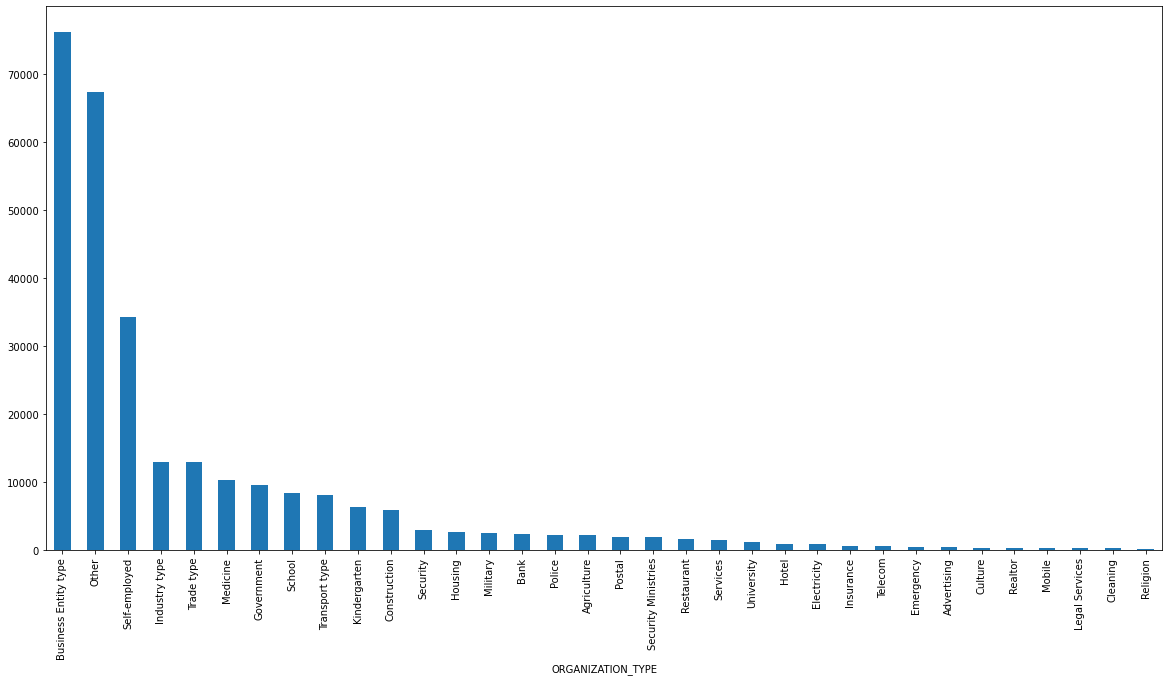

In [198]:
plt.figure(figsize=(20,10))
sorted_organization = final_df.groupby(['ORGANIZATION_TYPE','TARGET']).size().unstack().iloc[:,0].sort_values(ascending=False).plot(kind='bar')

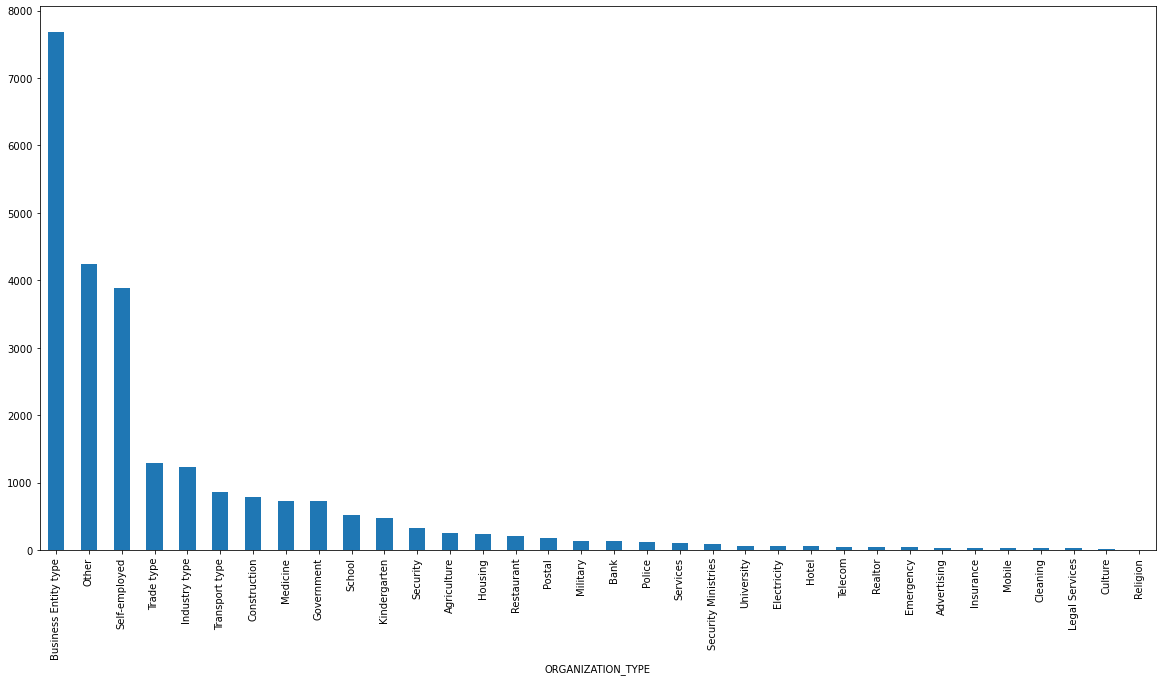

In [199]:
plt.figure(figsize=(20,10))
sorted_organization = final_df.groupby(['ORGANIZATION_TYPE','TARGET']).size().unstack().iloc[:,1].sort_values(ascending=False).plot(kind='bar')

# for i, v in enumerate(sorted_organization):
#     ax.text(v, i, f'{v:.0f}', va='center', fontsize=12, color='k', fontweight='bold')

# Set axis labels and title if needed
#ax.set_xlabel('Count')
#ax.set_ylabel('Organization Type')
#ax.set_title('Bar Chart of Organization Types')

plt.show()

#### Observation:
-------------------
- All the business entiy types have problem in paying loan as well as 'Other' category and 'Self-Employed'
- Also these three organization types have taken loan most.
- The Company might need to think of paying loan to these categories

#### EMERGENCYSTATE_MODE

- This attribute conveys the building condition infoormation of a client which is not directly related with loan. So can be dropped from analysis

#### Dropping Few Columns

In [200]:
final_df.drop(['CODE_GENDER', 'NAME_FAMILY_STATUS', 'WEEKDAY_APPR_PROCESS_START','EMERGENCYSTATE_MODE'], axis=1, inplace=True)

In [201]:
final_df.shape

(305195, 69)

In [202]:
final_df.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)

In [203]:
final_df.shape

(305195, 68)

### Numerical Column Analysis:
---------------------------------

In [204]:
num_col

['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'DAYS_LAST_PHONE_CHANGE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_1

#### CNT_CHILDREN

In [205]:
final_df['CNT_CHILDREN'].unique()

array([ 0,  1,  2,  3,  4,  7,  5,  6,  8,  9, 11, 12, 10, 19, 14],
      dtype=int64)

<AxesSubplot:xlabel='CNT_CHILDREN', ylabel='count'>

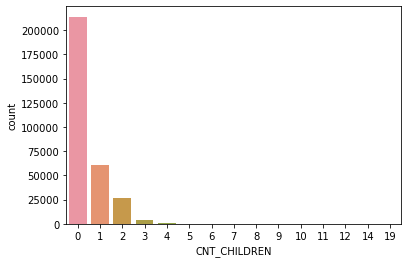

In [206]:
sns.countplot(x='CNT_CHILDREN', data=final_df)

<AxesSubplot:xlabel='CNT_CHILDREN'>

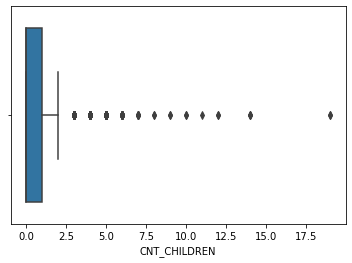

In [207]:
sns.boxplot(x='CNT_CHILDREN', data=final_df)

In [208]:
final_df.groupby(['CNT_CHILDREN','TARGET']).size().unstack(fill_value=0)  #Bivariate Analysis between CNT_CHILDREN and 'TARGET'

TARGET,0,1
CNT_CHILDREN,,
0,197203,16537
1,55230,5427
2,24232,2325
3,3331,358
4,371,55
5,77,7
6,15,6
7,7,0
8,2,0


#### Observation:
-----------------------
- It seems like that the persons having more than 6 children having very rare chance to be defaulter.
- The attribute seems to be very skewed and doesn't seem to be much useful to me because having less number of children or high number of children doesn't impact much on taking loan(Assumption)
- This attribute might be dropped. But as the attribute having few outliers those outliers can be removed

Let's make a scatter plot between CNT_CHILDREN and 'AMT_INCOME_TOTAL' to see if they have any dependency between them

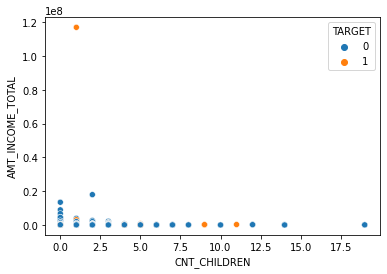

In [209]:
sns.scatterplot(x='CNT_CHILDREN', y='AMT_INCOME_TOTAL', data=final_df, hue='TARGET')
plt.show()

#### There is no such important relation found between them

In [210]:
final_df['CNT_CHILDREN'].corr(final_df['AMT_INCOME_TOTAL'])

0.013133123760316816

- The correlation between these two is also very weak but there is a positive correlation

#### Dropping of CNT_CHILDREN from the dataframe

In [211]:
final_df.drop(['CNT_CHILDREN'], axis=1, inplace=True)

In [212]:
final_df.shape

(305195, 67)

#### AMT_INCOME_TOTAL

(array([3.0519e+05, 2.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([2.56500000e+04, 5.87436750e+06, 1.17230850e+07, 1.75718025e+07,
        2.34205200e+07, 2.92692375e+07, 3.51179550e+07, 4.09666725e+07,
        4.68153900e+07, 5.26641075e+07, 5.85128250e+07, 6.43615425e+07,
        7.02102600e+07, 7.60589775e+07, 8.19076950e+07, 8.77564125e+07,
        9.36051300e+07, 9.94538475e+07, 1.05302565e+08, 1.11151282e+08,
        1.17000000e+08]),
 <BarContainer object of 20 artists>)

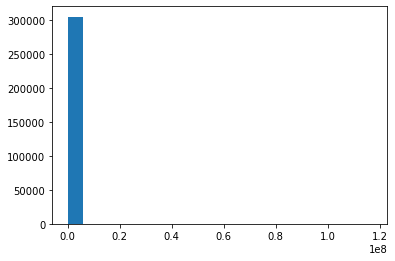

In [213]:
plt.hist(x='AMT_INCOME_TOTAL', data=final_df, bins=20)

In [214]:
final_df['INCOME_log'] = np.log(final_df['AMT_INCOME_TOTAL'])

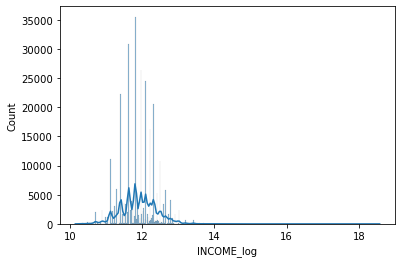

In [215]:
sns.histplot(x='INCOME_log', data=final_df, kde=True)
plt.show()

<AxesSubplot:xlabel='INCOME_log'>

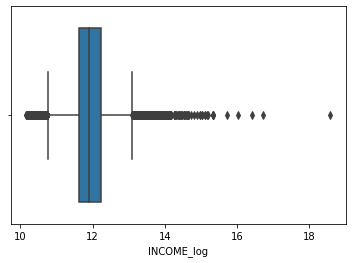

In [216]:
sns.boxplot(x='INCOME_log', data=final_df)

- Even if after log transformation of this variable there are presence of outliers. 

In [217]:
final_df.drop(['INCOME_log'], axis=1, inplace=True)

<AxesSubplot:xlabel='AMT_INCOME_TOTAL', ylabel='Count'>

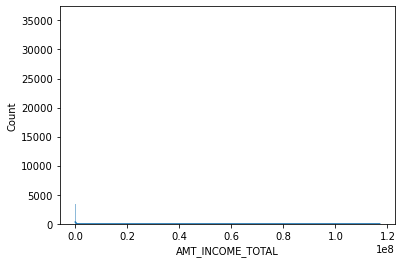

In [218]:
sns.histplot(final_df['AMT_INCOME_TOTAL'], kde=True)

<AxesSubplot:xlabel='AMT_INCOME_TOTAL'>

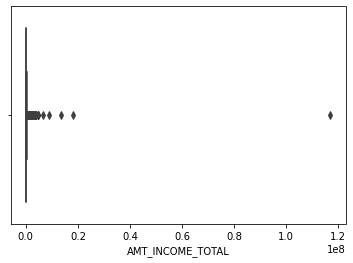

In [219]:
sns.boxplot(x='AMT_INCOME_TOTAL', data=final_df)

#### Outlier Detection - By Capping

In [220]:
outliers = []
upper_lim = 0
lower_lim = 0
def outlier_detection(x):
    global outliers
    x_dict = dict(final_df[x].describe())
    print(x_dict)
    Q1 = x_dict['25%']
    print("Q1 :", Q1)
    Q3 = x_dict['75%']
    print("Q3 :", Q3)
    IQR = Q3 - Q1
    print("Inter quartile range is ", IQR)
    global lower_lim
    global upper_lim
    lower_lim = Q1 - 1.5 * IQR
    upper_lim = Q3 + 1.5 * IQR
    print("The lower limit is ", round(lower_lim))
    print("The upper limit is ", round(upper_lim))

    for i in final_df[x]:
        if ((i > upper_lim) | (i < lower_lim)):
            outliers.append(i)
#    print("The outliers of ", x ,"is :", outliers)

In [221]:
outlier_detection('AMT_INCOME_TOTAL')

{'count': 305195.0, 'mean': 168613.75092624387, 'std': 237661.41977458805, 'min': 25650.0, '25%': 112500.0, '50%': 145800.0, '75%': 202500.0, 'max': 117000000.0}
Q1 : 112500.0
Q3 : 202500.0
Inter quartile range is  90000.0
The lower limit is  -22500
The upper limit is  337500


In [222]:
outliers

[360000.0,
 450000.0,
 360000.0,
 360000.0,
 540000.0,
 360000.0,
 540000.0,
 360000.0,
 360000.0,
 450000.0,
 450000.0,
 382500.0,
 360000.0,
 765000.0,
 450000.0,
 360000.0,
 630000.0,
 405000.0,
 450000.0,
 450000.0,
 472500.0,
 607500.0,
 450000.0,
 405000.0,
 450000.0,
 405000.0,
 450000.0,
 450000.0,
 450000.0,
 450000.0,
 450000.0,
 360000.0,
 450000.0,
 360000.0,
 540000.0,
 540000.0,
 405000.0,
 405000.0,
 540000.0,
 342000.0,
 360000.0,
 450000.0,
 450000.0,
 360000.0,
 382500.0,
 450000.0,
 382500.0,
 540000.0,
 400500.0,
 360000.0,
 360000.0,
 522000.0,
 450000.0,
 360000.0,
 405000.0,
 450000.0,
 810000.0,
 405000.0,
 630000.0,
 346500.0,
 364500.0,
 360000.0,
 450000.0,
 360000.0,
 675000.0,
 360000.0,
 360000.0,
 1080000.0,
 405000.0,
 382500.0,
 450000.0,
 630000.0,
 405000.0,
 720000.0,
 450000.0,
 697500.0,
 360000.0,
 360000.0,
 360000.0,
 378000.0,
 360000.0,
 450000.0,
 1935000.0,
 360000.0,
 360000.0,
 540000.0,
 405000.0,
 405000.0,
 360000.0,
 396000.0,
 369000.

In [223]:
final_df.loc[((final_df['AMT_INCOME_TOTAL'] >= 337500) & (final_df['AMT_INCOME_TOTAL'] <= 117000000.0)), 'AMT_INCOME_TOTAL']= round(upper_lim)

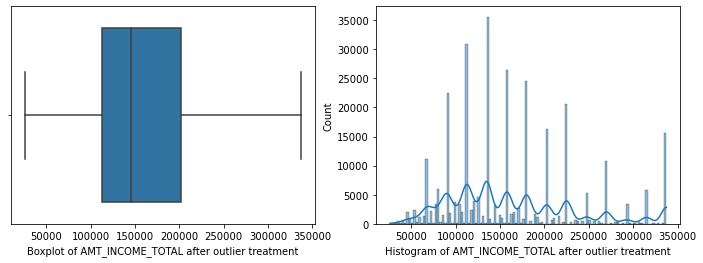

In [224]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='AMT_INCOME_TOTAL', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of AMT_INCOME_TOTAL after outlier treatment')
sns.histplot(x='AMT_INCOME_TOTAL', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of AMT_INCOME_TOTAL after outlier treatment')
plt.show()

In [225]:
# custom_quantiles = [0, 0.25, 0.5, 0.75, 1.0]
# final_df['HOUR_APPR_PROCESS_START_GROUP'] = pd.qcut(final_df['HOUR_APPR_PROCESS_START'], q=custom_quantiles, labels=['Below 10 hrs','Below 12 hrs','Below 15 hrs','Below 23 hrs'])

In [226]:
custom_quantiles_grp = [0,0.10,0.20,0.30,0.40,0.50,0.70,0.80,0.90,1.0]
final_df['AMT_INCOME_TOTAL_GRP'] = pd.qcut(final_df['AMT_INCOME_TOTAL'], q=custom_quantiles_grp, labels=['lowest_level_1', 'lowest_level_2',
                                                                                                        'lowest_level_3','Medium_level_1',
                                                                                                        'Medium_level_2','Above_Medium_level',
                                                                                                        'Good','Higher','Highest'])

In [227]:
final_df['AMT_INCOME_TOTAL_GRP']

0                       Good
1                     Higher
2             lowest_level_1
3             Medium_level_1
4             Medium_level_1
                 ...        
307506    Above_Medium_level
307507        lowest_level_1
307508    Above_Medium_level
307509    Above_Medium_level
307510    Above_Medium_level
Name: AMT_INCOME_TOTAL_GRP, Length: 305195, dtype: category
Categories (9, object): ['lowest_level_1' < 'lowest_level_2' < 'lowest_level_3' < 'Medium_level_1' ... 'Above_Medium_level' < 'Good' < 'Higher' < 'Highest']

In [228]:
final_df.groupby(['AMT_INCOME_TOTAL_GRP','TARGET']).size().unstack()

TARGET,0,1
AMT_INCOME_TOTAL_GRP,,
lowest_level_1,30441,2723
lowest_level_2,27572,2478
lowest_level_3,33436,3201
Medium_level_1,44401,4130
Medium_level_2,3846,376
Above_Medium_level,56234,5265
Good,40980,3483
Higher,18399,1401
Highest,25168,1661


- This AMT_INCOME_TOTAL seems to be one of the most important attribute for detecting defaulter
- After creating the custom groups of Income amount based on 10 percentile gap , we can see that the lowest group i.e, persons belonging to the first 10 percentile group have the difficulties in repaying the loan. Surprisingly in 10 -20 percentile group the defaulters' count is less. 
- Again Medium level (30-40) percentile group comes immediate after the 10 percentile group
- 70-80 percentile group coming in the next number to it.

#### AMT_CREDIT - Credit Amount of Loan

In [229]:
final_df['AMT_CREDIT'].unique()

array([ 406597.5, 1293502.5,  135000. , ...,  181989. ,  743863.5,
       1391130. ])

In [230]:
final_df['AMT_CREDIT'].isna().sum()

0

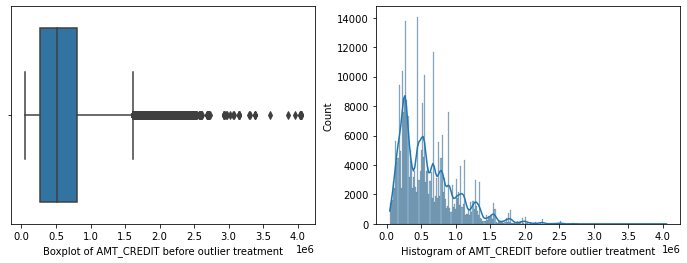

In [231]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='AMT_CREDIT', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of AMT_CREDIT before outlier treatment')

sns.histplot(x='AMT_CREDIT', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of AMT_CREDIT before outlier treatment')
plt.show()

- The attribute is right skewed and has outliers

<AxesSubplot:xlabel='AMT_INCOME_TOTAL', ylabel='AMT_CREDIT'>

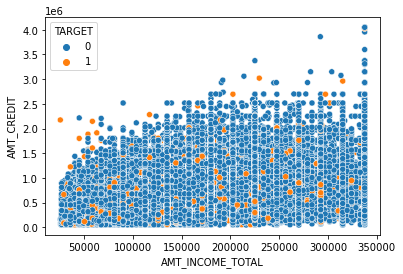

In [232]:
sns.scatterplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT', data=final_df, hue='TARGET')

<Figure size 864x432 with 0 Axes>

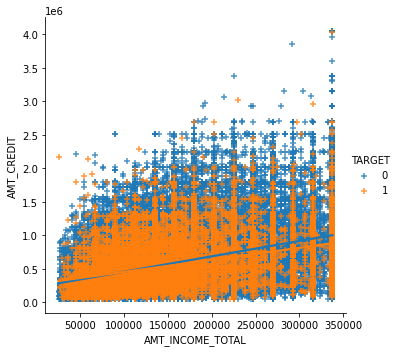

In [233]:
plt.figure(figsize=(12,6))
sns.lmplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT', data=final_df, markers='+', hue='TARGET')
plt.show()

#### Checking Correlation between AMT_INCOME_TOTAL and AMT_CREDIT :

In [234]:
final_df['AMT_INCOME_TOTAL'].corr(final_df['AMT_CREDIT'])

0.4118346296272609

- There is a positive correlation present between these two independent variables for both Defaulter and Non-Defaulter categories of TARGET

In [235]:
final_df.groupby(['NAME_TYPE_SUITE','TARGET'])['AMT_CREDIT'].median().unstack()

TARGET,0,1
NAME_TYPE_SUITE,,
Children,508495.5,521280.0
Family,539100.0,512064.0
Others,490495.5,450000.0
"Spouse, partner",553027.5,521280.0
Unaccompanied,508513.5,495000.0


- The persons who have been accompanied by children factor or spouse,partner haave higher chances of being defaulter as the median amount of loan of those categories are highest

In [236]:
final_df.groupby('NAME_CONTRACT_TYPE')['AMT_CREDIT'].median()

NAME_CONTRACT_TYPE
Cash loans         540000.0
Revolving loans    270000.0
Name: AMT_CREDIT, dtype: float64

#### Let's remove few outlier points from here

In [237]:
#(df[df['Annual Income']==df['Annual Income'].max()].index,inplace=True)

In [238]:
final_df [final_df['AMT_CREDIT']>= 2500000]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE,AMT_INCOME_TOTAL_GRP
1969,102310,0,Cash loans,N,Y,270000.0,2517300.0,102658.5,2250000.0,"Spouse, partner",...,0,0,0.0,0.0,0.0,0.0,1.0,5.0,0.754024,Higher
5119,105983,0,Cash loans,Y,N,270000.0,2517300.0,66402.0,2250000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.748431,Higher
5246,106136,0,Cash loans,N,N,225000.0,2517300.0,69354.0,2250000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.756504,Good
7061,108224,0,Cash loans,Y,N,337500.0,2695500.0,74254.5,2250000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.502453,Highest
7642,108906,0,Cash loans,Y,N,337500.0,2925000.0,73944.0,2925000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.483767,Highest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300186,447771,0,Cash loans,Y,N,264901.5,2700000.0,68386.5,2700000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.692538,Higher
301424,449206,0,Cash loans,Y,N,242550.0,2517300.0,63634.5,2250000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.479046,Higher
302689,450684,0,Cash loans,N,Y,274500.0,2517300.0,66532.5,2250000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.567882,Highest
305139,453530,0,Cash loans,N,Y,184950.0,2700000.0,68256.0,2700000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.602900,Good


In [239]:
import math

In [240]:
len(final_df [final_df['AMT_CREDIT']>= 2.5*math.pow(10,6)])

350

In [241]:
len(final_df [final_df['AMT_CREDIT']>= 2.5*math.pow(10,6)]) / len(final_df) * 100

0.11468077786333328

In [242]:
final_df [final_df['AMT_CREDIT']>= 2.5*math.pow(10,6)].index

Int64Index([  1969,   5119,   5246,   7061,   7642,   8094,   8103,   8189,
              8940,   9336,
            ...
            294250, 295655, 297808, 298030, 298769, 300186, 301424, 302689,
            305139, 306102],
           dtype='int64', length=350)

In [243]:
final_df.drop( final_df [final_df['AMT_CREDIT']>= 2.5*math.pow(10,6)].index, inplace=True )

In [244]:
final_df.shape

(304845, 68)

<Figure size 864x432 with 0 Axes>

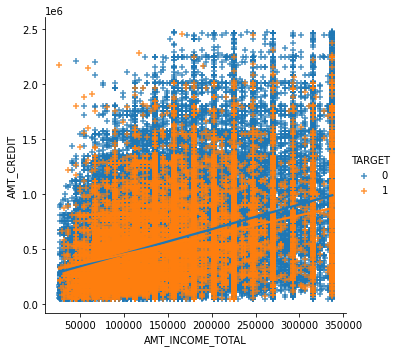

In [245]:
plt.figure(figsize=(12,6))
sns.lmplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT', data=final_df, markers='+', hue='TARGET')
plt.show()

#### AMT_ANNUITY

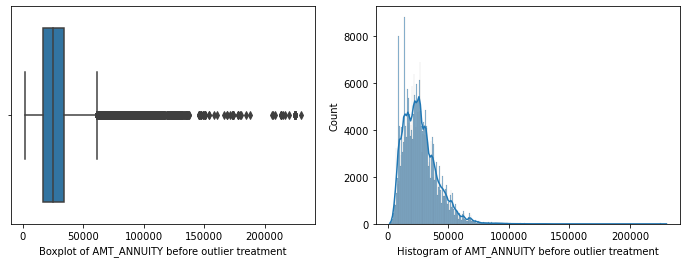

In [246]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='AMT_ANNUITY', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of AMT_ANNUITY before outlier treatment')

sns.histplot(x='AMT_ANNUITY', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of AMT_ANNUITY before outlier treatment')
plt.show()

#### Checking percentage of outliers

In [247]:
len(final_df [final_df['AMT_ANNUITY']>= 75000])

1907

In [248]:
len(final_df [final_df['AMT_ANNUITY']>= 75000]) / len(final_df) * 100

0.6255638111171251

- If we take te boundary from upper whisker then total outlier percentage becomes 6.8%. So, instead of that, taking the boundary or upper whisker at 75000 and removing the rest part of it.

In [249]:
final_df.drop( final_df[final_df['AMT_ANNUITY'] >= 75000].index, inplace=True)

In [250]:
final_df.shape

(302938, 68)

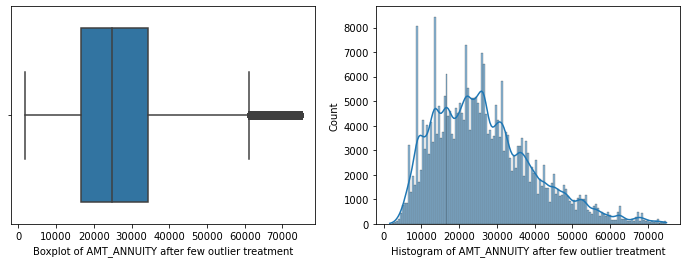

In [251]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='AMT_ANNUITY', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of AMT_ANNUITY after few outlier treatment')

sns.histplot(x='AMT_ANNUITY', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of AMT_ANNUITY after few outlier treatment')
plt.show()

<Figure size 864x432 with 0 Axes>

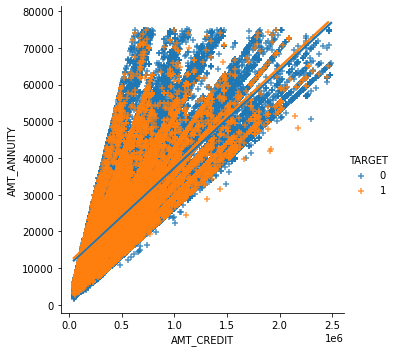

In [252]:
plt.figure(figsize=(12,6))
sns.lmplot(x='AMT_CREDIT', y='AMT_ANNUITY', data=final_df, markers='+', hue='TARGET')
plt.show()

<Figure size 864x432 with 0 Axes>

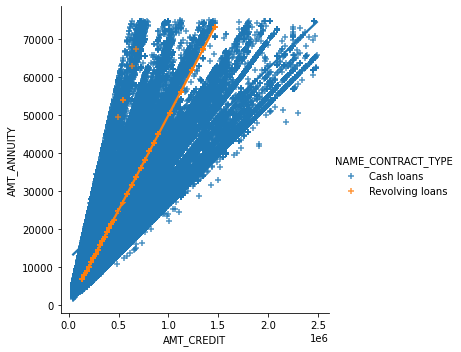

In [253]:
plt.figure(figsize=(12,6))
sns.lmplot(x='AMT_CREDIT', y='AMT_ANNUITY', data=final_df, markers='+', hue='NAME_CONTRACT_TYPE')
plt.show()

<Figure size 864x432 with 0 Axes>

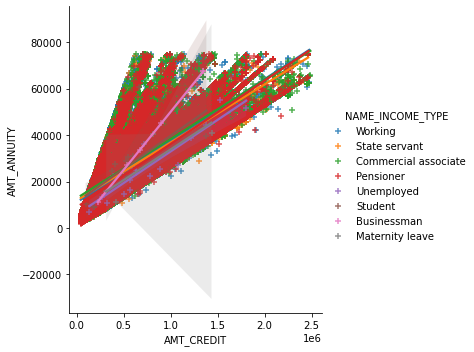

In [254]:
plt.figure(figsize=(12,6))
sns.lmplot(x='AMT_CREDIT', y='AMT_ANNUITY', data=final_df, markers='+', hue='NAME_INCOME_TYPE')
plt.show()

#### Analysis between AMT_INCOME_TYPE, TARGET and AMT_ANNUITY

In [255]:
final_df.groupby(['NAME_INCOME_TYPE', 'TARGET'])['AMT_ANNUITY'].median().unstack()

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,33750.0,NaN
Commercial associate,27558.0,27139.5
Maternity leave,28125.0,26091.0
Pensioner,21681.0,22198.5
State servant,26446.5,26217.0
Student,25146.0,NaN
Unemployed,25384.5,22270.5
Working,24592.5,25033.5


In [256]:
final_df.groupby(['NAME_INCOME_TYPE', 'TARGET']).size().unstack()
#final_df.groupby(['NAME_INCOME_TYPE'])['TARGET'].size().unstack()

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,7.0,NaN
Commercial associate,64640.0,5300.0
Maternity leave,2.0,2.0
Pensioner,51782.0,2958.0
State servant,20104.0,1239.0
Student,17.0,NaN
Unemployed,11.0,8.0
Working,141732.0,15136.0


#### Observation:
----------------------
- Businessmen count for defaulter is null, seems that no business man have been defaulter. So for them the median of loan annuity is 0.
- Commercial Associates are highest in count in terms of being defaulter. Their Median Annuity amount is highest.
- The Maternity Leave taken persons being little in count , they have very high median annuity amount.
- For working persons the count of defaulter is less than the count of non-defaulters but the median Amount of aloan annuity for defaulters is quite high

#### Analysis between 'NAME_CONTRACT_TYPE', 'TARGET' and 'AMT_ANNUITY'

In [257]:
final_df.groupby(['NAME_CONTRACT_TYPE', 'TARGET'])['AMT_ANNUITY'].median().unstack()

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,25969.5,26064.0
Revolving loans,13500.0,10125.0


In [258]:
final_df.groupby(['NAME_CONTRACT_TYPE','TARGET']).size().unstack()

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,251941,23097
Revolving loans,26354,1546


#### AMT_GOODS_PRICE - For consumer loans it is the price of the goods for which the loan is given

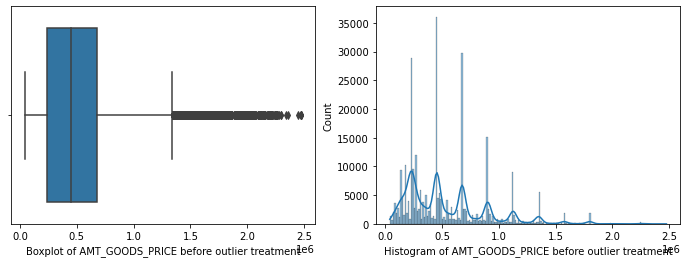

In [259]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='AMT_GOODS_PRICE', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of AMT_GOODS_PRICE before outlier treatment')

sns.histplot(x='AMT_GOODS_PRICE', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of AMT_GOODS_PRICE before outlier treatment')
plt.show()

- There are a lot of outliers present, if we take log transform te outliers impact is getting reduced

In [260]:
len(final_df[final_df['AMT_GOODS_PRICE'] > 1.5*math.pow(10,6)])

5907

In [261]:
len(final_df[final_df['AMT_GOODS_PRICE'] > 1.5*math.pow(10,6)]) / len(final_df) * 100

1.9499039407403496

#### For AMT_GOODS_PRICE only 2% are outlier. So we can remove these outliers.

In [262]:
final_df.drop(final_df[final_df['AMT_GOODS_PRICE'] > 1.5*pow(10,6)].index, inplace=True)

<AxesSubplot:>

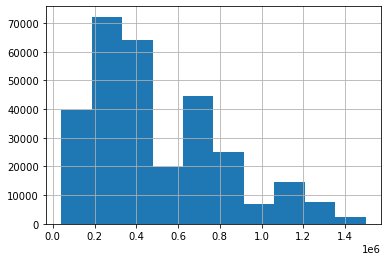

In [263]:
final_df['AMT_GOODS_PRICE'].hist()

In [264]:
final_df.groupby(['NAME_CONTRACT_TYPE', 'TARGET'])['AMT_GOODS_PRICE'].median().unstack()

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,454500.0,450000.0
Revolving loans,270000.0,202500.0


In [265]:
final_df.groupby(['NAME_CONTRACT_TYPE','TARGET']).size().unstack()

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,246289,22842
Revolving loans,26354,1546


#### Observation:
-------------------
- The Cashloan category has pretty high median AMT_GOODS_PRICE , means for them the price of the goods for which they have applied loan is higher

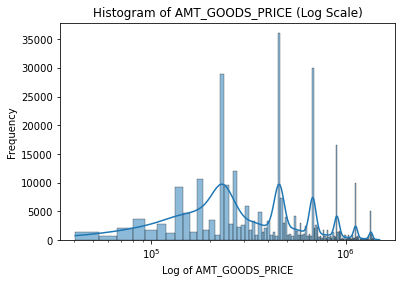

In [266]:
sns.histplot(x='AMT_GOODS_PRICE', data=final_df, kde=True)
plt.xscale('log')

# Add labels and title if needed
plt.xlabel('Log of AMT_GOODS_PRICE')
plt.ylabel('Frequency')
plt.title('Histogram of AMT_GOODS_PRICE (Log Scale)')

# Show the plot
plt.show()

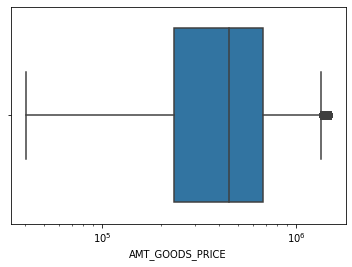

In [267]:
sns.boxplot(x='AMT_GOODS_PRICE', data=final_df)
plt.xscale('log')

#### REGION_POPULATION_RELATIVE

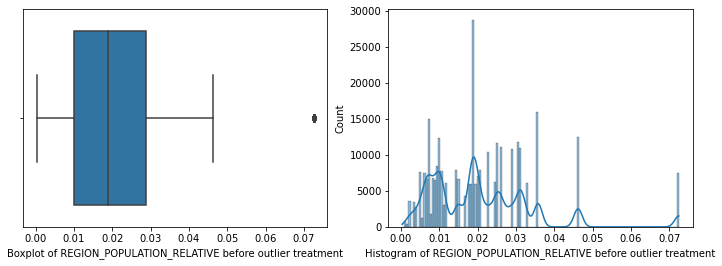

In [268]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='REGION_POPULATION_RELATIVE', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of REGION_POPULATION_RELATIVE before outlier treatment')

sns.histplot(x='REGION_POPULATION_RELATIVE', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of REGION_POPULATION_RELATIVE before outlier treatment')
plt.show()

In [269]:
outlier_detection('REGION_POPULATION_RELATIVE')

{'count': 297031.0, 'mean': 0.020686939615739947, 'std': 0.013596284516159088, 'min': 0.00029, '25%': 0.010006, '50%': 0.01885, '75%': 0.028663, 'max': 0.072508}
Q1 : 0.010006
Q3 : 0.028663
Inter quartile range is  0.018657
The lower limit is  0
The upper limit is  0


#### Only one outlier is present. So dropping the outlier

In [270]:
final_df.drop( final_df[final_df['REGION_POPULATION_RELATIVE']==max(final_df['REGION_POPULATION_RELATIVE'])].index , inplace=True)

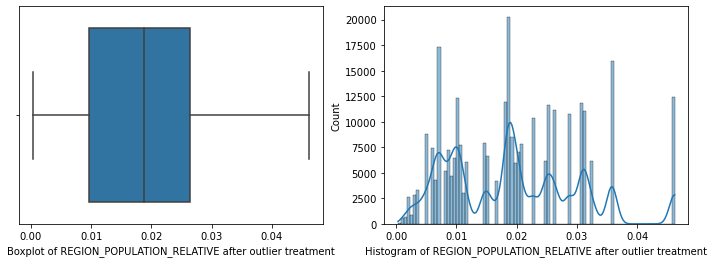

In [271]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='REGION_POPULATION_RELATIVE', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of REGION_POPULATION_RELATIVE after outlier treatment')

sns.histplot(x='REGION_POPULATION_RELATIVE', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of REGION_POPULATION_RELATIVE after outlier treatment')
plt.show()

In [272]:
final_df['REGION_POPULATION_RELATIVE'].unique()

array([0.018801, 0.003541, 0.010032, 0.008019, 0.028663, 0.035792,
       0.018634, 0.019689, 0.0228  , 0.015221, 0.031329, 0.016612,
       0.010006, 0.020713, 0.010966, 0.04622 , 0.025164, 0.006296,
       0.026392, 0.018029, 0.019101, 0.030755, 0.008575, 0.01885 ,
       0.006207, 0.009175, 0.007305, 0.007114, 0.009334, 0.022625,
       0.01452 , 0.006629, 0.00733 , 0.032561, 0.00496 , 0.009657,
       0.02461 , 0.003069, 0.020246, 0.018209, 0.009549, 0.007274,
       0.002134, 0.010276, 0.003813, 0.003818, 0.00712 , 0.0105  ,
       0.010147, 0.010643, 0.008866, 0.00702 , 0.002506, 0.005313,
       0.006233, 0.008474, 0.005144, 0.011657, 0.014464, 0.006008,
       0.00963 , 0.005002, 0.006852, 0.011703, 0.006305, 0.010556,
       0.00823 , 0.008625, 0.003122, 0.006671, 0.002042, 0.005084,
       0.008068, 0.004849, 0.001333, 0.001417, 0.001276, 0.000938,
       0.000533, 0.00029 ])

In [273]:
custom_quantiles = [0, 0.25, 0.5, 0.75, 1.0]
final_df['REGION_POPULATION_RELATIVE_CAT'] = pd.qcut(final_df['REGION_POPULATION_RELATIVE'], q=custom_quantiles, labels=['lower','medium','higher','highest'])

In [274]:
final_df[['REGION_POPULATION_RELATIVE','REGION_POPULATION_RELATIVE_CAT']].head()

,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE_CAT
0,0.018801,medium
1,0.003541,lower
2,0.010032,medium
3,0.008019,lower
4,0.028663,highest


In [275]:
final_df.shape

(289523, 69)

In [276]:
final_df.groupby(['REGION_POPULATION_RELATIVE_CAT','TARGET']).size().unstack()

TARGET,0,1
REGION_POPULATION_RELATIVE_CAT,,
lower,66067,6426
medium,66209,6471
higher,69840,6354
highest,63341,4815


<AxesSubplot:xlabel='REGION_POPULATION_RELATIVE_CAT', ylabel='count'>

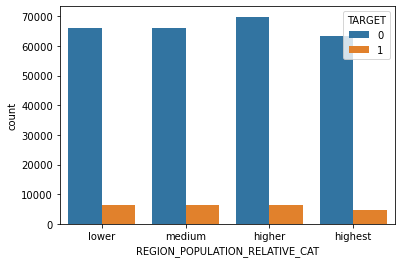

In [277]:
sns.countplot(x='REGION_POPULATION_RELATIVE_CAT', hue='TARGET', data=final_df)

- The result is not being much helpful to understand which region's people are falling into defaulter category
- Better to drop this attribute from analysis

In [278]:
new_subset_df = final_df[['TARGET','NAME_CONTRACT_TYPE','FLAG_OWN_CAR','FLAG_OWN_REALTY','AMT_INCOME_TOTAL','AMT_CREDIT',
         'AMT_ANNUITY','AMT_GOODS_PRICE','NAME_TYPE_SUITE','NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','REGION_POPULATION_RELATIVE']]

In [279]:
new_subset_df

,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE
0,1,Cash loans,N,Y,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,0.018801
1,0,Cash loans,N,N,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,0.003541
2,0,Revolving loans,Y,Y,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,0.010032
3,0,Cash loans,N,Y,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,0.008019
4,0,Cash loans,N,Y,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,0.028663
...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,N,N,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,0.032561
307507,0,Cash loans,N,Y,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,0.025164
307508,0,Cash loans,N,Y,153000.0,677664.0,29979.0,585000.0,Unaccompanied,Working,Higher education,0.005002
307509,1,Cash loans,N,Y,171000.0,370107.0,20205.0,319500.0,Unaccompanied,Commercial associate,Secondary / secondary special,0.005313


In [280]:
new_subset_df.corr()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE
TARGET,1.000000,-0.012312,-0.020410,0.001062,-0.030935,-0.026864
AMT_INCOME_TOTAL,-0.012312,1.000000,0.364434,0.447072,0.369199,0.084133
AMT_CREDIT,-0.020410,0.364434,1.000000,0.761126,0.983988,0.041883
AMT_ANNUITY,0.001062,0.447072,0.761126,1.000000,0.763662,0.049037
AMT_GOODS_PRICE,-0.030935,0.369199,0.983988,0.763662,1.000000,0.049606
REGION_POPULATION_RELATIVE,-0.026864,0.084133,0.041883,0.049037,0.049606,1.000000


<AxesSubplot:>

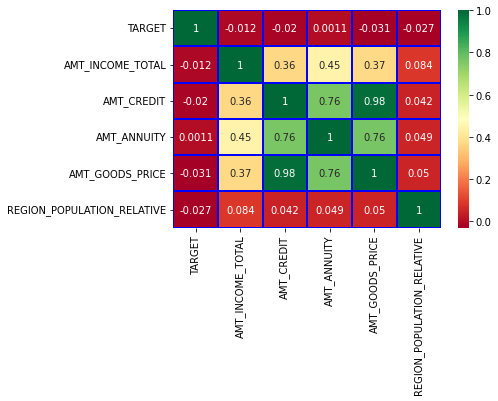

In [281]:
sns.heatmap(new_subset_df.corr(),  annot=True,linecolor='blue',linewidth=1.5,cmap='RdYlGn')

#### Observation:
---------------------
- The multicolinearity can be seen here between AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE
- VIF(Variance Inflation Factor) can be done for identifying the multicolinearity and also we can understand important features from here

In [282]:
final_df.drop(['REGION_POPULATION_RELATIVE','REGION_POPULATION_RELATIVE_CAT'], axis=1, inplace=True)

In [283]:
final_df.groupby(['NAME_EDUCATION_TYPE','TARGET'])['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE'].median().unstack()

AMT_INCOME_TOTAL           AMT_CREDIT  \
TARGET                                       0         1          0   
NAME_EDUCATION_TYPE                                                   
Academic degree                       180000.0  337500.0   536917.5   
Higher education                      180000.0  171000.0   540000.0   
Incomplete higher                     157500.0  157500.0   450000.0   
Lower secondary                       112500.0  117000.0   420894.0   
Secondary / secondary special         135000.0  135000.0   490536.0   

                                         AMT_ANNUITY            \
TARGET                                 1           0         1   
NAME_EDUCATION_TYPE                                              
Academic degree                790830.00     28003.5  44437.50   
Higher education               536917.50     26487.0  26723.25   
Incomplete higher              450000.00     24543.0  25483.50   
Lower secondary                450000.00     21406.5  23370.75   
Secondary / secondary special  474761.25     23742.0  24561.00   

                              AMT_GOODS_PRICE            
TARGET                                      0         1  
NAME_EDUCATION_TYPE                                      
Academic degree                      463500.0  675000.0  
Higher education                     459000.0  450000.0  
Incomplete higher                    450000.0  436500.0  
Lower secondary                      360000.0  384750.0  
Secondary / secondary special        450000.0  450000.0

- The Academic Degree holders have median income of 337500 for defaulter group , also their credit amount, annuity amount and hoods price amount are pretty high.
- So, Academic Degree holders have more possibility for being defaulter.

#### DAYS_BIRTH - Client's age in days at the time of application

In [284]:
final_df.DAYS_BIRTH

0         -9461
1        -16765
2        -19046
3        -19005
4        -19932
          ...  
307506    -9327
307507   -20775
307508   -14966
307509   -11961
307510   -16856
Name: DAYS_BIRTH, Length: 289523, dtype: int64

In [285]:
final_df['DAYS_BIRTH'].iloc[0]

-9461

In [286]:
 final_df[final_df['DAYS_BIRTH'] > 0]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE,AMT_INCOME_TOTAL_GRP


#### Observatoion:
---------------------
- It seems to be all age are given in negative value. So better to drop this variable because it seems to be of no use because practically age can never be negative

In [287]:
final_df.drop('DAYS_BIRTH', axis=1, inplace=True)

In [288]:
final_df.shape

(289523, 66)

In [289]:
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE,AMT_INCOME_TOTAL_GRP
0,100002,1,Cash loans,N,Y,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.161787,Good
1,100003,0,Cash loans,N,N,270000.0,1293502.5,35698.5,1129500.0,Family,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.466757,Higher
2,100004,0,Revolving loans,Y,Y,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.642739,lowest_level_1
3,100006,0,Cash loans,N,Y,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.650442,Medium_level_1
4,100007,0,Cash loans,N,Y,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.322738,Medium_level_1


#### DAYS_EMPLOYED - How many days before the application the person started current employment

In [290]:
final_df['DAYS_EMPLOYED']

0           -637
1          -1188
2           -225
3          -3039
4          -3038
           ...  
307506      -236
307507    365243
307508     -7921
307509     -4786
307510     -1262
Name: DAYS_EMPLOYED, Length: 289523, dtype: int64

- The attribute has mix of positive and negative values.
- Though the days can't be negative, but we can imagine that the negative sign symbolize the past period

In [291]:
 final_df[final_df['DAYS_EMPLOYED'] > 0]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE,AMT_INCOME_TOTAL_GRP
8,100011,0,Cash loans,N,Y,112500.000,1019610.0,33826.5,913500.0,Children,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.514935,lowest_level_3
11,100015,0,Cash loans,N,Y,38419.155,148365.0,10678.5,135000.0,Children,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0.643375,lowest_level_1
23,100027,0,Cash loans,N,Y,83250.000,239850.0,23850.0,225000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.646681,lowest_level_2
38,100045,0,Cash loans,N,Y,99000.000,247275.0,17338.5,225000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0.701244,lowest_level_2
43,100050,0,Cash loans,N,Y,108000.000,746280.0,42970.5,675000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.725483,lowest_level_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307469,456209,0,Cash loans,N,Y,202500.000,703728.0,29943.0,607500.0,Unaccompanied,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.278119,Good
307483,456227,0,Cash loans,N,Y,99000.000,247275.0,16479.0,225000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,0.0,5.0,0.555402,lowest_level_2
307487,456231,0,Cash loans,N,Y,117000.000,1071909.0,31473.0,936000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,0.0,1.0,8.0,0.281207,Medium_level_1
307505,456249,0,Cash loans,N,Y,112500.000,225000.0,22050.0,225000.0,Unaccompanied,...,0,0,0.0,0.0,0.0,2.0,0.0,0.0,0.544286,lowest_level_3


In [292]:
final_df['DAYS_EMPLOYED'] = final_df['DAYS_EMPLOYED'].abs()    # Changing all negative calues to positive values

In [293]:
final_df['DAYS_EMPLOYED']

0            637
1           1188
2            225
3           3039
4           3038
           ...  
307506       236
307507    365243
307508      7921
307509      4786
307510      1262
Name: DAYS_EMPLOYED, Length: 289523, dtype: int64

In [294]:
np.ceil(final_df['DAYS_EMPLOYED'] / 365)

0            2.0
1            4.0
2            1.0
3            9.0
4            9.0
           ...  
307506       1.0
307507    1001.0
307508      22.0
307509      14.0
307510       4.0
Name: DAYS_EMPLOYED, Length: 289523, dtype: float64

In [295]:
final_df['DAYS_EMPLOYED_YEAR'] = np.ceil(final_df['DAYS_EMPLOYED'] / 365)

In [296]:
#### Dropping the DAYS_EMPLOYED attribute

final_df.drop(['DAYS_EMPLOYED'], axis=1, inplace=True)

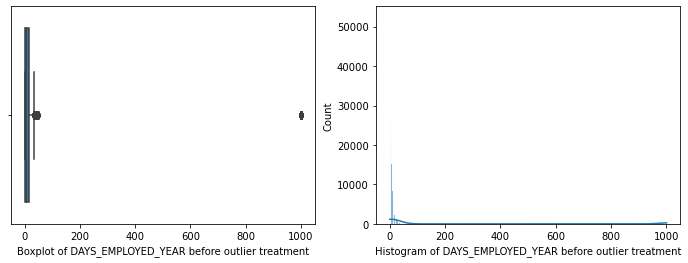

In [297]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='DAYS_EMPLOYED_YEAR', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of DAYS_EMPLOYED_YEAR before outlier treatment')

sns.histplot(x='DAYS_EMPLOYED_YEAR', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of DAYS_EMPLOYED_YEAR before outlier treatment')
plt.show()

- One outlier of 1000 year can be seen here, which can be removed

In [298]:
final_df.drop(final_df[final_df['DAYS_EMPLOYED_YEAR'] > 1000].index, inplace=True)

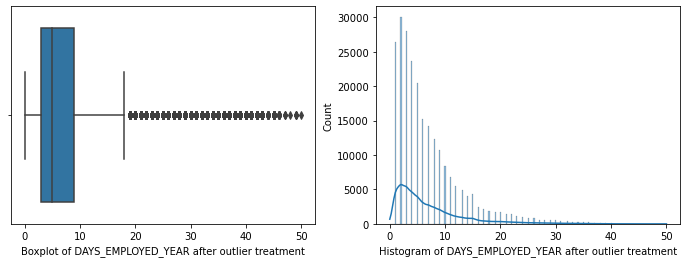

In [299]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='DAYS_EMPLOYED_YEAR', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of DAYS_EMPLOYED_YEAR after outlier treatment')

sns.histplot(x='DAYS_EMPLOYED_YEAR', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of DAYS_EMPLOYED_YEAR after outlier treatment')
plt.show()

In [300]:
final_df.groupby(['DAYS_EMPLOYED_YEAR','TARGET']).size().unstack()

TARGET,0,1
DAYS_EMPLOYED_YEAR,,
0.0,1.0,1.0
1.0,23393.0,2984.0
2.0,26557.0,3535.0
3.0,24919.0,3089.0
4.0,21218.0,2463.0
5.0,18557.0,1926.0
6.0,13973.0,1285.0
7.0,13049.0,1129.0
8.0,11405.0,925.0


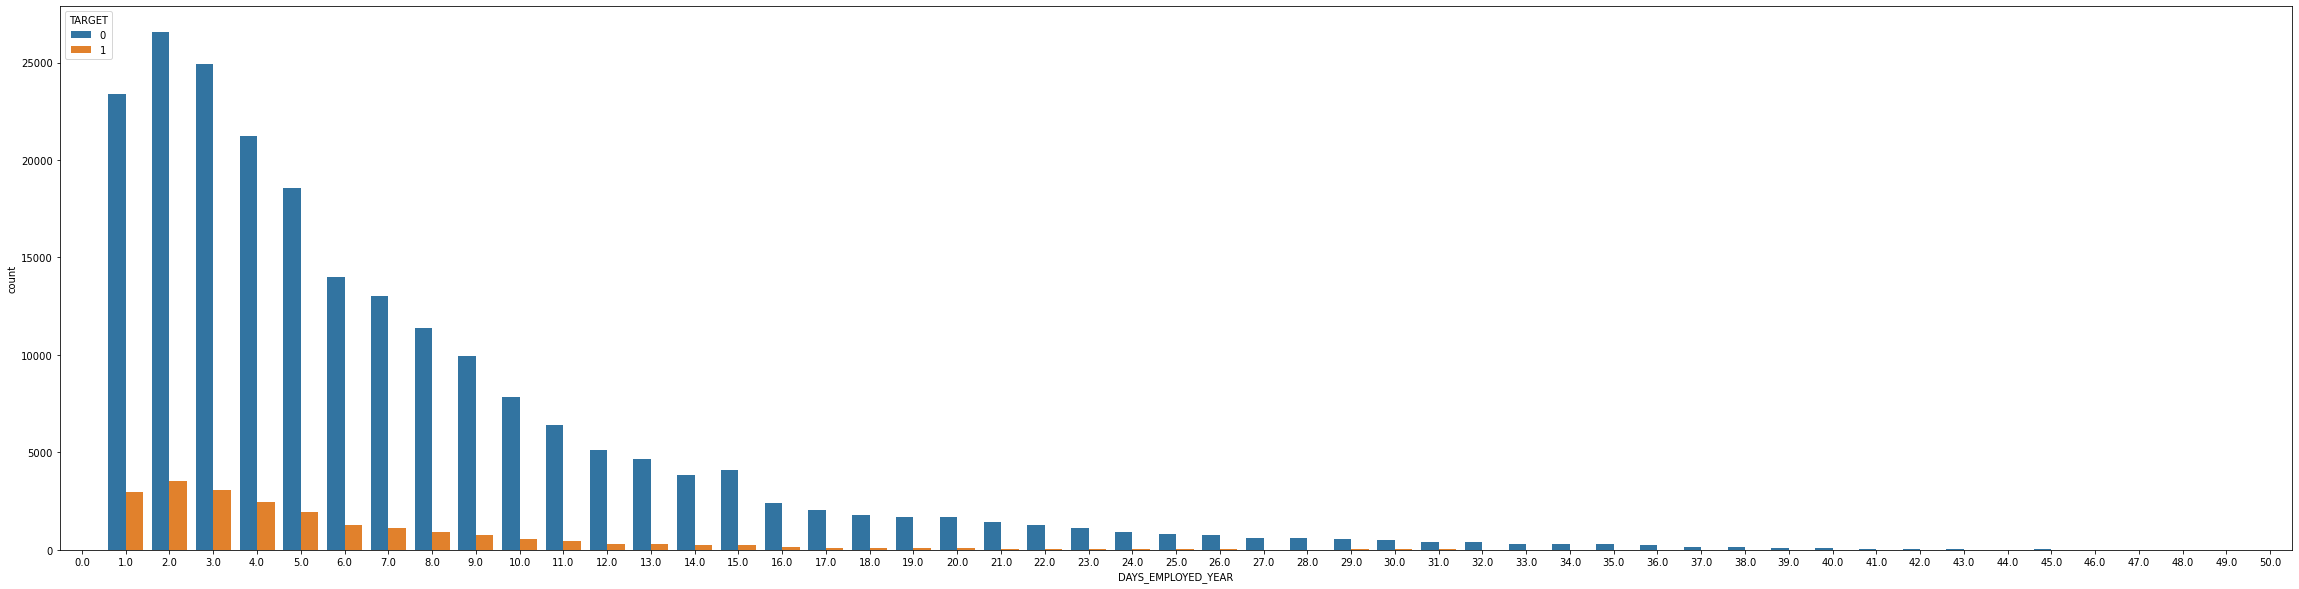

In [301]:
plt.figure(figsize=(40,10))
sns.countplot(x='DAYS_EMPLOYED_YEAR', data=final_df, hue='TARGET')
plt.show()

- We can see that in the employees who have been employed almost 41 to 50 years earlier ,there are hardly any person applying for loan. So in that age range there is no chance of being defaulter.
- For the purpose of modelling those instances can be dropped off further
- With the employement year being increased the number of defaulters are gradully decreasing

In [302]:
final_df.drop(final_df[final_df['DAYS_EMPLOYED_YEAR'] >40].index, inplace=True )

In [303]:
final_df.shape

(236795, 66)

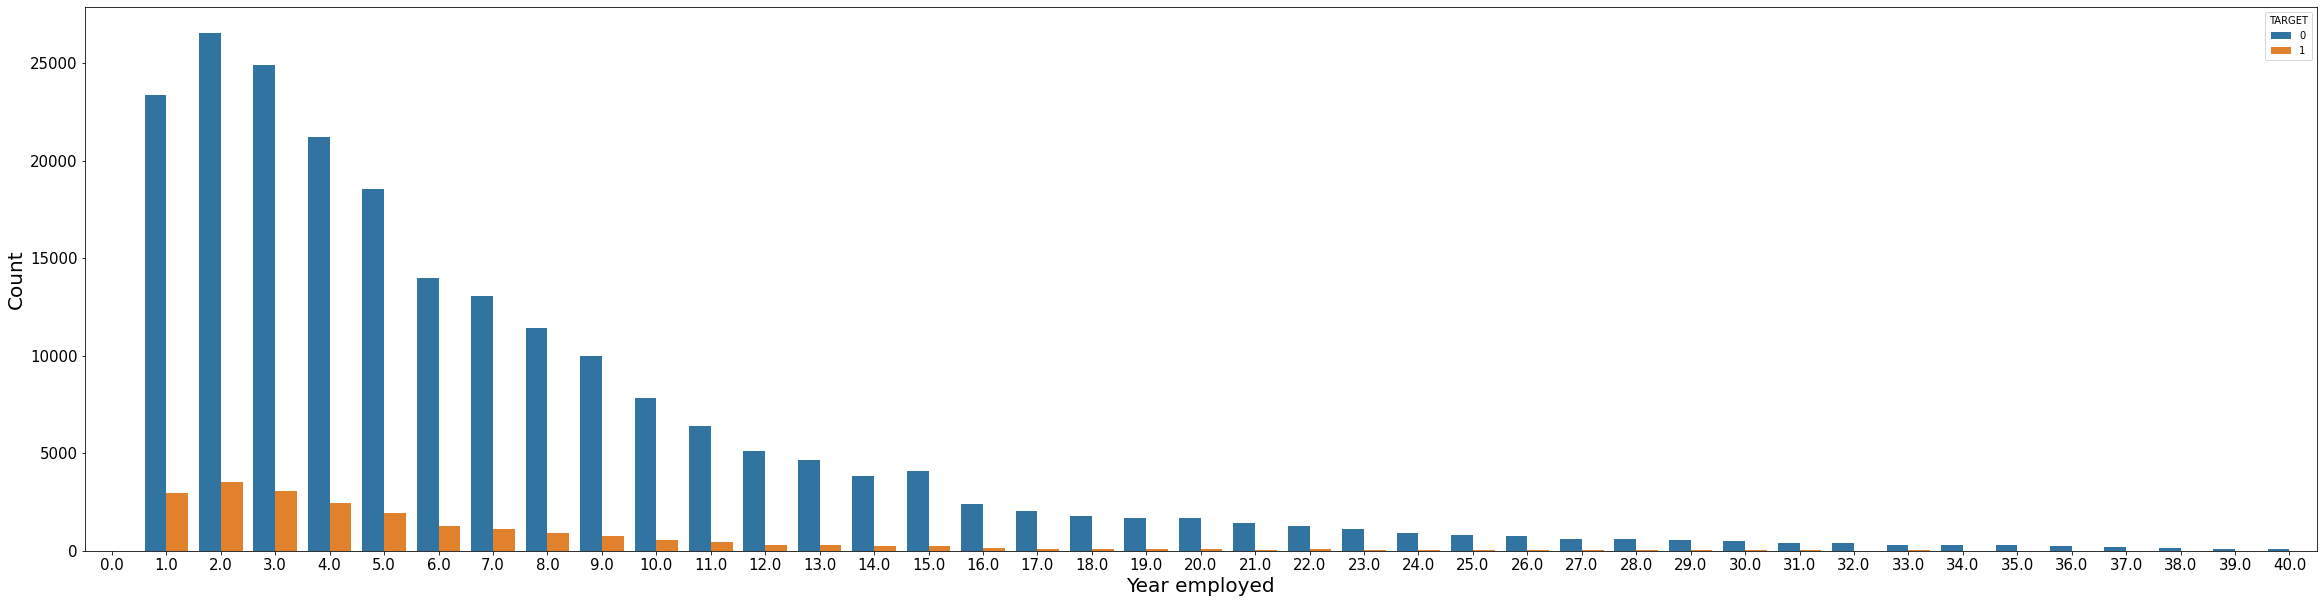

In [304]:
plt.figure(figsize=(40,10))
sns.countplot(x='DAYS_EMPLOYED_YEAR', data=final_df, hue='TARGET')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Year employed',fontsize=20)
plt.ylabel('Count',fontsize=20)
plt.show()

- The employees with employment year 2 have been defaulter

In [305]:
final_df['TARGET'].corr(final_df['DAYS_EMPLOYED_YEAR'])

-0.07516303921267373

- The correlation is negative and weak

#### DAYS_REGISTRATION

In [306]:
final_df['DAYS_REGISTRATION']

0        -3648.0
1        -1186.0
2        -4260.0
3        -9833.0
4        -4311.0
           ...  
307504   -9798.0
307506   -8456.0
307508   -6737.0
307509   -2562.0
307510   -5128.0
Name: DAYS_REGISTRATION, Length: 236795, dtype: float64

- All values ore negative, so assuming that those days are in past period

In [307]:
final_df['DAYS_REGISTRATION'] = final_df['DAYS_REGISTRATION'].abs()

In [308]:
final_df['DAYS_REGISTRATION_YEAR'] = np.ceil(final_df['DAYS_REGISTRATION'] / 365)

In [309]:
final_df.drop(['DAYS_REGISTRATION'], axis=1, inplace=True)

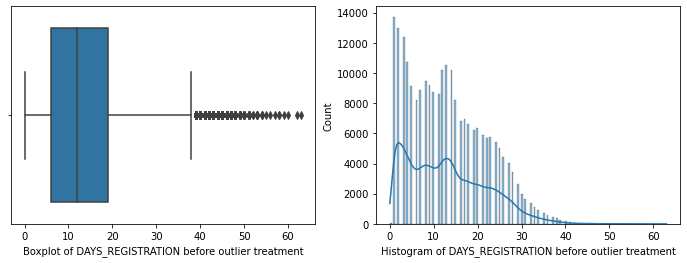

In [310]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
sns.boxplot(x='DAYS_REGISTRATION_YEAR', data=final_df, ax=axes[0])
axes[0].set_xlabel('Boxplot of DAYS_REGISTRATION before outlier treatment')

sns.histplot(x='DAYS_REGISTRATION_YEAR', data=final_df, kde=True, ax=axes[1])
axes[1].set_xlabel('Histogram of DAYS_REGISTRATION before outlier treatment')
plt.show()

In [311]:
final_df.groupby(['DAYS_REGISTRATION_YEAR','TARGET']).size().unstack()

TARGET,0,1
DAYS_REGISTRATION_YEAR,,
0.0,54.0,7.0
1.0,12267.0,1461.0
2.0,11672.0,1342.0
3.0,11158.0,1248.0
4.0,9718.0,1006.0
...,...,...
58.0,2.0,NaN
59.0,1.0,NaN
60.0,1.0,NaN


#### removing the outliers

In [312]:
final_df.drop(final_df[final_df['DAYS_REGISTRATION_YEAR'] > 40].index, inplace=True)

In [313]:
final_df.shape

(236263, 66)

#### DAYS_ID_PUBLISH

In [314]:
final_df['DAYS_ID_PUBLISH']

0        -2120
1         -291
2        -2531
3        -2437
4        -3458
          ... 
307504    -259
307506   -1982
307508   -5150
307509    -931
307510    -410
Name: DAYS_ID_PUBLISH, Length: 236263, dtype: int64

In [315]:
final_df['DAYS_ID_PUBLISH'] = final_df['DAYS_ID_PUBLISH'].abs()
final_df['DAYS_ID_PUBLISH_YEAR'] = np.ceil(final_df['DAYS_ID_PUBLISH']/365)
final_df.drop('DAYS_ID_PUBLISH', axis=1, inplace=True)

In [316]:
final_df.groupby(['DAYS_ID_PUBLISH_YEAR','TARGET']).size().unstack()

TARGET,0,1
DAYS_ID_PUBLISH_YEAR,,
0.0,13.0,2.0
1.0,11779.0,1439.0
2.0,12628.0,1466.0
3.0,13914.0,1609.0
4.0,13718.0,1511.0
5.0,13205.0,1459.0
6.0,13542.0,1391.0
7.0,14313.0,1509.0
8.0,14891.0,1542.0


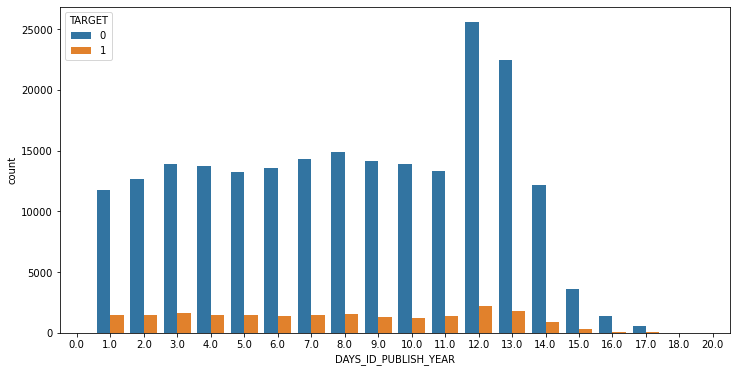

In [317]:
plt.figure(figsize=(12,6))
sns.countplot(x='DAYS_ID_PUBLISH_YEAR', data=final_df, hue='TARGET')
plt.show()

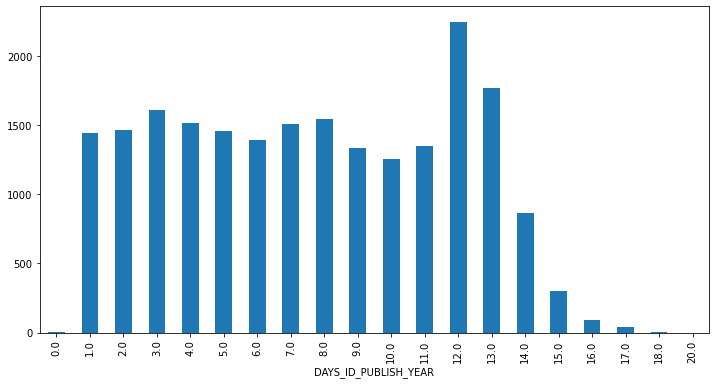

In [318]:
plt.figure(figsize=(12,6))
final_df.groupby(['DAYS_ID_PUBLISH_YEAR','TARGET']).size().unstack().iloc[:,1].plot(kind='bar')
plt.show()

- The number of defaulters are comparatively very less in this attribute, but the applicants who changed their ID card 12 years or 13 years ago they have a bit higher chance of beig defaulter

In [319]:
test_subset = final_df[['TARGET','DAYS_EMPLOYED_YEAR','DAYS_REGISTRATION_YEAR','DAYS_ID_PUBLISH_YEAR']]

In [320]:
test_subset

,TARGET,DAYS_EMPLOYED_YEAR,DAYS_REGISTRATION_YEAR,DAYS_ID_PUBLISH_YEAR
0,1,2.0,10.0,6.0
1,0,4.0,4.0,1.0
2,0,1.0,12.0,7.0
3,0,9.0,27.0,7.0
4,0,9.0,12.0,10.0
...,...,...,...,...
307504,0,20.0,27.0,1.0
307506,0,1.0,24.0,6.0
307508,0,22.0,19.0,15.0
307509,1,14.0,8.0,3.0


<AxesSubplot:>

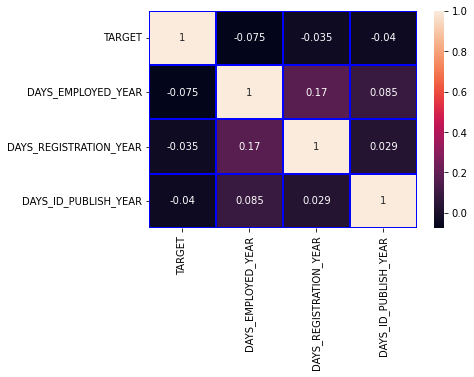

In [321]:
sns.heatmap(test_subset.corr(), linecolor='blue', linewidths=1.5, annot=True)

#### FLAG_MOBIL

In [322]:
final_df['FLAG_MOBIL'].value_counts()

1    236262
0         1
Name: FLAG_MOBIL, dtype: int64

- Only one partcipant has no mobile. So we can drop that instance

In [323]:
final_df.drop(final_df[final_df['FLAG_MOBIL']==0].index, inplace=True)

<AxesSubplot:xlabel='FLAG_MOBIL', ylabel='count'>

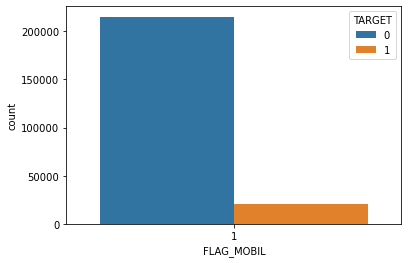

In [324]:
sns.countplot(x='FLAG_MOBIL', data=final_df, hue='TARGET')

In [325]:
merged_df1 = pd.merge(final_df[['SK_ID_CURR','FLAG_MOBIL','TARGET']], inp1[['SK_ID_CURR','NAME_CONTRACT_STATUS']], how='left', on='SK_ID_CURR')

In [326]:
merged_df1

,SK_ID_CURR,FLAG_MOBIL,TARGET,NAME_CONTRACT_STATUS
0,100002,1,1,Approved
1,100003,1,0,Approved
2,100003,1,0,Approved
3,100003,1,0,Approved
4,100004,1,0,Approved
...,...,...,...,...
1091387,456255,1,0,Approved
1091388,456255,1,0,Refused
1091389,456255,1,0,Refused
1091390,456255,1,0,Approved


In [327]:
merged_df1['FLAG_MOBIL'].unique()

array([1], dtype=int64)

In [328]:
merged_df1.groupby(['NAME_CONTRACT_STATUS','TARGET']).size().unstack()

TARGET,0,1
NAME_CONTRACT_STATUS,,
Approved,621068,56727
Canceled,171182,19785
Refused,166301,25263
Unused offer,18177,1726


<AxesSubplot:xlabel='NAME_CONTRACT_STATUS'>

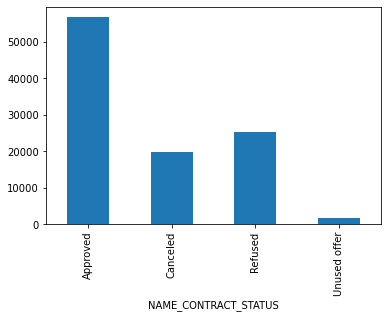

In [329]:
merged_df1.groupby(['NAME_CONTRACT_STATUS','TARGET']).size().unstack().iloc[:,1].plot(kind='bar')

- By the graph, In this attribute , we can say that whosever Loan had been approved in previous time , this time defaulters are found more in that 'Approved' category.
- But this attribute dowsn't seem to be much useful. So dropping this attribute going forward

In [330]:
final_df.drop('FLAG_MOBIL', axis=1,inplace=True)

In [331]:
final_df.shape

(236262, 65)

#### FLAG_WORK_PHONE & FLAG_EMP_PHONE

In [332]:
final_df['FLAG_EMP_PHONE'].value_counts()

1    236251
0        11
Name: FLAG_EMP_PHONE, dtype: int64

<AxesSubplot:xlabel='FLAG_EMP_PHONE', ylabel='count'>

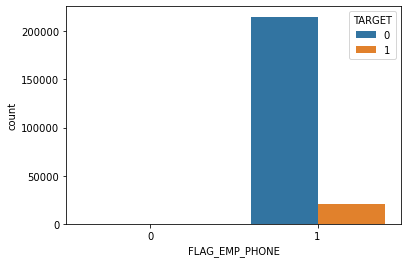

In [333]:
sns.countplot(x='FLAG_EMP_PHONE', data=final_df, hue='TARGET')

In [334]:
final_df[final_df['FLAG_EMP_PHONE'] == 0]['TARGET']

9509      0
22183     0
57221     0
69649     0
83902     0
87293     1
99540     0
132292    0
171505    0
270746    0
303008    0
Name: TARGET, dtype: int64

- Out of 11 people who haven't provided their emp phone out of them only 1 is defaulter.
- But before taking any conclusion from this we can do any kind of hypothesis testing
- This attribute also seems not to be very useful. Dropping this attribute

In [335]:
final_df.drop('FLAG_EMP_PHONE', axis=1, inplace=True)

In [336]:
final_df['FLAG_WORK_PHONE'].value_counts()

0    178497
1     57765
Name: FLAG_WORK_PHONE, dtype: int64

In [337]:
final_df.groupby(['FLAG_WORK_PHONE','TARGET']).size().unstack()

TARGET,0,1
FLAG_WORK_PHONE,,
0,163054,15443
1,52044,5721


- We can say that a large number of people haven't provided their home phone among them almost 8.5% are defaulters.

In [338]:
final_df.groupby(['FLAG_WORK_PHONE','TARGET']).size().unstack().iloc[0,:]

TARGET
0    163054
1     15443
Name: 0, dtype: int64

#### FLAG_CONT_MOBILE

In [339]:
final_df['FLAG_CONT_MOBILE'].value_counts()

1    235783
0       479
Name: FLAG_CONT_MOBILE, dtype: int64

In [340]:
final_df.groupby(['FLAG_CONT_MOBILE','TARGET']).size().unstack()

TARGET,0,1
FLAG_CONT_MOBILE,,
0,437,42
1,214661,21122


In [341]:
(final_df.groupby(['FLAG_CONT_MOBILE','TARGET']).size().unstack().iloc[1,1])/ (final_df.groupby(['FLAG_CONT_MOBILE','TARGET']).size().unstack().iloc[:,1].sum()) * 100

99.80154980154981

In [342]:
final_df.groupby(['FLAG_CONT_MOBILE','TARGET']).size().unstack().iloc[1,1]


21122

#### Observation:
--------------------
- whosever numbers were reachable , among them 99.8% people became defaulter. So this attribute is very much important to consider

#### FLAG_PHONE

In [343]:
final_df['FLAG_PHONE'].value_counts(normalize=True)

0    0.732119
1    0.267881
Name: FLAG_PHONE, dtype: float64

- 73% people provided their phone and 27% didn't

In [344]:
final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack()

TARGET,0,1
FLAG_PHONE,,
0,156840,16132
1,58258,5032


In [345]:
(final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[:,1].sum())

21164

In [346]:
(final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[1,1])

5032

In [347]:
(final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[1,1])/ (final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[:,1].sum()) * 100

23.776223776223777

#### Observation:
----------------------
- The applicants who have failed to pay loan among them Phone number was provided by 23% applicants and rest 77% didn't provide phone numbers

#### FLAG_EMAIL

In [348]:
final_df['FLAG_EMAIL'].value_counts(normalize=True)

0    0.938881
1    0.061119
Name: FLAG_EMAIL, dtype: float64

93% didn't provide email ID

In [349]:
final_df.groupby(['FLAG_EMAIL','TARGET']).size().unstack()

TARGET,0,1
FLAG_EMAIL,,
0,201874,19948
1,13224,1216


In [350]:
(final_df.groupby(['FLAG_EMAIL','TARGET']).size().unstack().iloc[1,1])

1216

In [351]:
(final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[:,1].sum())

21164

In [352]:
(final_df.groupby(['FLAG_EMAIL','TARGET']).size().unstack().iloc[1,1])/ (final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[:,1].sum()) * 100

5.745605745605745

In [353]:
(final_df.groupby(['FLAG_EMAIL','TARGET']).size().unstack().iloc[0,1])/ (final_df.groupby(['FLAG_PHONE','TARGET']).size().unstack().iloc[:,1].sum()) * 100

94.25439425439426

- 5.7% of defaulters have provided email and rest 94% defaulters haven't provided emails

#### FLAG_EMAIl, FLAG_EMP_PHONE, FLAG_PHONE, FLAG_CONT_PHONE , FLAG_WORK_PHONE everything should be categorical in nature 

#### All FLAG_Type of vsribles are important and all should be categorical in nature

#### REGION_RATING_CLIENT

In [354]:
final_df.groupby(['REGION_RATING_CLIENT','TARGET']).size().unstack()

TARGET,0,1
REGION_RATING_CLIENT,,
1,18209,1067
2,163601,15434
3,33288,4663


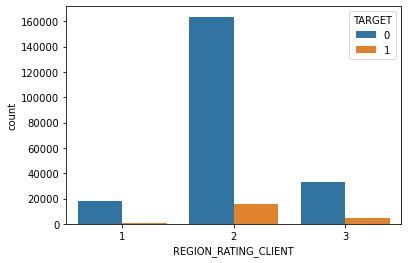

In [355]:
sns.countplot(x='REGION_RATING_CLIENT', data=final_df, hue='TARGET')
plt.show()

#### Group by operation of three most important attributes based on Region rating

In [356]:
final_df.groupby(['REGION_RATING_CLIENT'])[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']].median()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
REGION_RATING_CLIENT,,,
1,202500.0,595273.5,30676.5
2,144000.0,497520.0,24718.5
3,135000.0,497520.0,24894.0


- If a person belongs to a region the rating of which area is 2 then there is a chance to be defaulter

#### REGION_RATING_CLIENT_W_CITY

In [357]:
final_df.groupby(['REGION_RATING_CLIENT_W_CITY','TARGET']).size().unstack()

TARGET,0,1
REGION_RATING_CLIENT_W_CITY,,
1,19734,1153
2,165248,15658
3,30116,4353


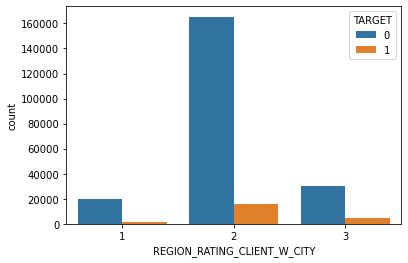

In [358]:
sns.countplot(x='REGION_RATING_CLIENT_W_CITY', data=final_df, hue='TARGET')
plt.show()

In [359]:
final_df.groupby(['REGION_RATING_CLIENT_W_CITY'])[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']].median()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
REGION_RATING_CLIENT_W_CITY,,,
1,202500.0,593010.0,30676.5
2,144000.0,497520.0,24732.0
3,135000.0,495000.0,24561.0


- We can keep any of these two attributes because both of them are more or less same type
- Keeping 'REGION_RATING_CLIENT' and dropping off 'REGION_RATING_CLIENT_W_CITY' 

In [360]:
final_df.drop(['REGION_RATING_CLIENT_W_CITY'], axis=1, inplace=True)

In [361]:
final_df.shape

(236262, 63)

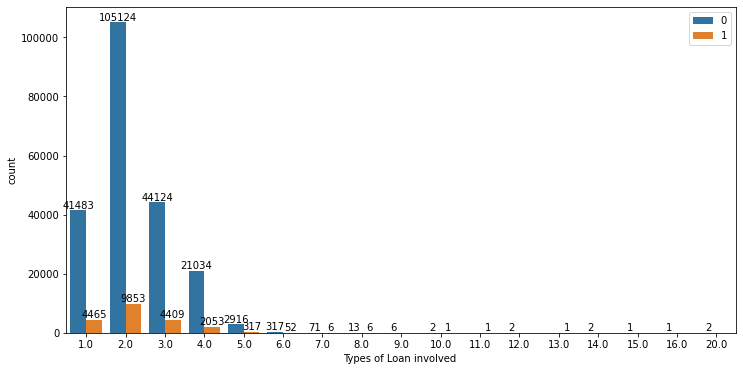

In [362]:
plt.figure(figsize=(12,6))
ax=sns.countplot(x='CNT_FAM_MEMBERS', data=final_df, hue='TARGET')
plt.legend(loc ="upper right")
for label in ax.containers:
    ax.bar_label(label)
plt.xlabel('Types of Loan involved ')
plt.show()

#ax=sns.countplot(x='NAME_CONTRACT_TYPE', data=final_df, hue='TARGET')


In [363]:
final_df['CNT_FAM_MEMBERS'].corr(final_df['TARGET'])

-0.002003794327188022

- This attribute has very weak correlation with TARGET. A bit confused about how much important it is. So, dropping this attribute

In [364]:
final_df.drop(['CNT_FAM_MEMBERS'], axis=1, inplace=True)

#### HOUR_APPR_PROCESS_START

In [365]:
final_df['HOUR_APPR_PROCESS_START'].isna().sum()

0

<AxesSubplot:xlabel='HOUR_APPR_PROCESS_START'>

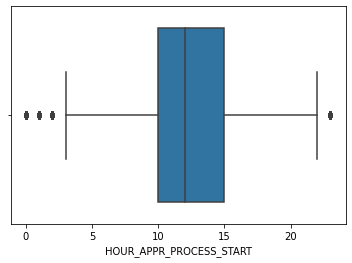

In [366]:
sns.boxplot(final_df['HOUR_APPR_PROCESS_START'])

In [367]:
final_df.groupby(['HOUR_APPR_PROCESS_START','TARGET']).size().unstack()

TARGET,0,1
HOUR_APPR_PROCESS_START,,
0,30,6
1,69,6
2,225,26
3,899,90
4,1493,151
5,2499,324
6,3872,554
7,6155,767
8,10059,1145


In [368]:
final_df.groupby(['HOUR_APPR_PROCESS_START','TARGET'])['AMT_INCOME_TOTAL','AMT_ANNUITY','AMT_CREDIT'].median()

AMT_INCOME_TOTAL  AMT_ANNUITY  AMT_CREDIT
HOUR_APPR_PROCESS_START TARGET                                           
0                       0               198000.0     30372.75   784525.50
                        1               191250.0     26651.25   550836.00
1                       0               189000.0     29034.00   550980.00
                        1               141750.0     20652.75   443016.00
2                       0               180000.0     30717.00   573408.00
                        1               180000.0     24171.75   372516.75
3                       0               180000.0     27657.00   518562.00
                        1               166500.0     26649.00   504792.00
4                       0               171000.0     27324.00   531706.50
                        1               157500.0     26473.50   512064.00
5                       0               157500.0     26388.00   512410.50
                        1               135000.0     26574.75   508497.75
6                       0               157500.0     25899.75   508495.50
                        1               135000.0     25537.50   495441.00
7                       0               148500.0     24592.50   497520.00
                        1               135000.0     25933.50   521280.00
8                       0               135000.0     24507.00   495000.00
                        1               135000.0     24714.00   460858.50
9                       0               135000.0     24543.00   497520.00
                        1               135000.0     25375.50   490495.50
10                      0               144000.0     24808.50   508495.50
                        1               135000.0     25195.50   473760.00
11                      0               148500.0     25056.00   505642.50
                        1               135000.0     25537.50   473841.00
12                      0               157500.0     24853.50   508495.50
                        1               139500.0     24828.75   474048.00
13                      0               157500.0     25033.50   508495.50
                        1               153000.0     25407.00   490495.50
14                      0               157500.0     25321.50   513040.50
                        1               139500.0     25537.50   491031.00
15                      0               157500.0     25375.50   516069.00
                        1               157500.0     25537.50   473760.00
16                      0               157500.0     25785.00   521280.00
                        1               157500.0     25537.50   510660.00
17                      0               157500.0     25578.00   521280.00
                        1               157500.0     26446.50   527562.00
18                      0               157500.0     26194.50   523446.75
                        1               157500.0     26543.25   521280.00
19                      0               166500.0     27000.00   545040.00
                        1               157500.0     26478.00   464130.00
20                      0               157500.0     26154.00   539100.00
                        1               135000.0     22977.00   450000.00
21                      0               157500.0     26770.50   545040.00
                        1               135000.0     26064.00   450000.00
22                      0               157500.0     26725.50   611280.00
                        1               157500.0     26442.00   630000.00
23                      0               166500.0     27774.00   675000.00
                        1               180000.0     22252.50   450000.00

In [369]:
final_df['HOUR_APPR_PROCESS_START'].corr(final_df['TARGET'])

-0.028110758193852257

In [370]:
final_df['HOUR_APPR_PROCESS_START'].describe()

count    236262.000000
mean         12.130956
std           3.286604
min           0.000000
25%          10.000000
50%          12.000000
75%          15.000000
max          23.000000
Name: HOUR_APPR_PROCESS_START, dtype: float64

#### Let's create 4 groups of this variable in order for our ease of analysis

In [371]:
custom_quantiles = [0, 0.25, 0.5, 0.75, 1.0]
final_df['HOUR_APPR_PROCESS_START_GROUP'] = pd.qcut(final_df['HOUR_APPR_PROCESS_START'], q=custom_quantiles, labels=['Below 10 hrs','Below 12 hrs','Below 15 hrs','Below 23 hrs'])

In [372]:
final_df['HOUR_APPR_PROCESS_START_GROUP']

0         Below 10 hrs
1         Below 12 hrs
2         Below 10 hrs
3         Below 23 hrs
4         Below 12 hrs
              ...     
307504    Below 12 hrs
307506    Below 15 hrs
307508    Below 10 hrs
307509    Below 10 hrs
307510    Below 23 hrs
Name: HOUR_APPR_PROCESS_START_GROUP, Length: 236262, dtype: category
Categories (4, object): ['Below 10 hrs' < 'Below 12 hrs' < 'Below 15 hrs' < 'Below 23 hrs']

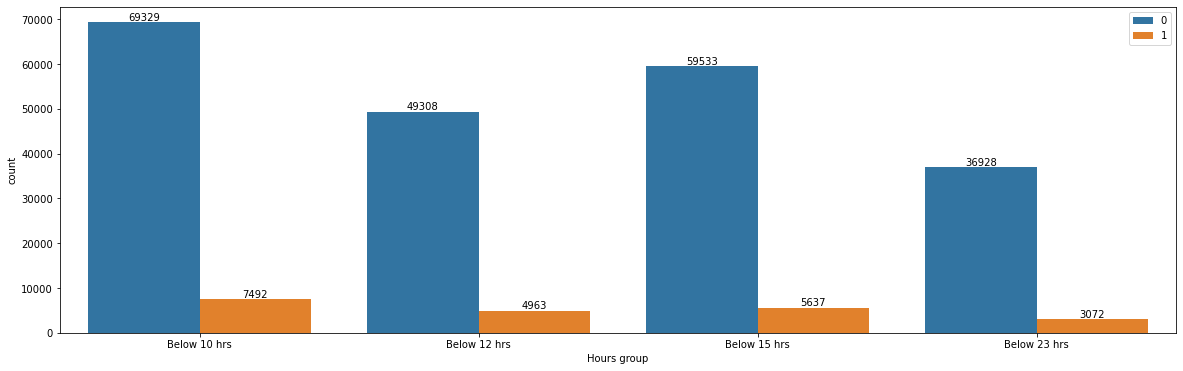

In [373]:
plt.figure(figsize=(20,6))
ax=sns.countplot(x='HOUR_APPR_PROCESS_START_GROUP', data=final_df, hue='TARGET')
plt.legend(loc ="upper right")
for label in ax.containers:
    ax.bar_label(label)
plt.xlabel('Hours group')
plt.show()

- The applicants who applied approximately 10 hours before for them there is a chance of being default
- But this attribute also dowsn't seem to be very helpful. mostly we should drop this one as well

In [374]:
final_df.drop(['HOUR_APPR_PROCESS_START','HOUR_APPR_PROCESS_START_GROUP'], axis=1, inplace=True)

In [375]:
final_df.shape

(236262, 61)

#### REG_REGION_NOT_LIVE_REGION

In [376]:
final_df['REG_REGION_NOT_LIVE_REGION'].value_counts()

0    232433
1      3829
Name: REG_REGION_NOT_LIVE_REGION, dtype: int64

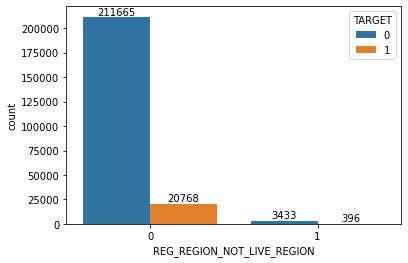

In [377]:
ax=sns.countplot(x='REG_REGION_NOT_LIVE_REGION',data=final_df, hue='TARGET')
for i in ax.containers:
    ax.bar_label(i)
plt.show()

In [378]:
final_df.groupby(['REG_REGION_NOT_LIVE_REGION','TARGET']).size().unstack()

TARGET,0,1
REG_REGION_NOT_LIVE_REGION,,
0,211665,20768
1,3433,396


- defaulter people are majorly present in those category whose permanent address and contact address match(0).
- 396 people who are facing difficulty in paying loan come under those people whose permanent address and contact address don't match.
- This attribute should be categorical in nature

#### REG_REGION_NOT_WORK_REGION

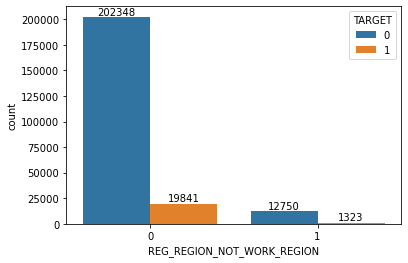

In [379]:
ax=sns.countplot(x='REG_REGION_NOT_WORK_REGION',data=final_df, hue='TARGET')
for i in ax.containers:
    ax.bar_label(i)
plt.show()

In [380]:
final_df.groupby(['REG_REGION_NOT_WORK_REGION','TARGET']).size().unstack()

TARGET,0,1
REG_REGION_NOT_WORK_REGION,,
0,202348,19841
1,12750,1323


- Like the earlier attribute this one also has similar type of outcome. Majority defaulter come under those whose work address and contact address match
- This attribute can be removed ( it can create multicolinearity with the previous attribute- By Assumption)

In [381]:
final_df.drop('REG_REGION_NOT_WORK_REGION', axis=1, inplace=True)

In [382]:
final_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE,AMT_INCOME_TOTAL_GRP,DAYS_EMPLOYED_YEAR,DAYS_REGISTRATION_YEAR,DAYS_ID_PUBLISH_YEAR
0,100002,1,Cash loans,N,Y,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,1.0,0.161787,Good,2.0,10.0,6.0
1,100003,0,Cash loans,N,N,270000.0,1293502.5,35698.5,1129500.0,Family,...,0.0,0.0,0.0,0.0,0.0,0.466757,Higher,4.0,4.0,1.0
2,100004,0,Revolving loans,Y,Y,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,0.642739,lowest_level_1,1.0,12.0,7.0
3,100006,0,Cash loans,N,Y,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,0.650442,Medium_level_1,9.0,27.0,7.0
4,100007,0,Cash loans,N,Y,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,0.322738,Medium_level_1,9.0,12.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307504,456248,0,Cash loans,N,Y,153000.0,331920.0,16096.5,225000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,0.530725,Above_Medium_level,20.0,27.0,1.0
307506,456251,0,Cash loans,N,N,157500.0,254700.0,27558.0,225000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,0.413601,Above_Medium_level,1.0,24.0,6.0
307508,456253,0,Cash loans,N,Y,153000.0,677664.0,29979.0,585000.0,Unaccompanied,...,0.0,0.0,1.0,0.0,1.0,0.499536,Above_Medium_level,22.0,19.0,15.0
307509,456254,1,Cash loans,N,Y,171000.0,370107.0,20205.0,319500.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,0.587593,Above_Medium_level,14.0,8.0,3.0


- Another attribute of similar type is present: "LIVE_REGION_NOT_WORK_REGION" . Dropping this as well.

In [383]:
final_df.drop('LIVE_REGION_NOT_WORK_REGION', axis=1, inplace=True)

#### REG_CITY_NOT_LIVE_CITY - Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)

In [384]:
final_df['REG_CITY_NOT_LIVE_CITY'].unique()

array([0, 1], dtype=int64)

In [385]:
final_df.groupby(['REG_CITY_NOT_LIVE_CITY','TARGET']).size().unstack()

TARGET,0,1
REG_CITY_NOT_LIVE_CITY,,
0,196064,18393
1,19034,2771


- Majority of defaulter come from those group of which the permanent address and contact address have matched

#### REG_CITY_NOT_WORK_CITY - Flag if client's permanent address does not match work address (1=different, 0=same, at city level)

In [386]:
final_df.groupby(['REG_CITY_NOT_WORK_CITY','TARGET']).size().unstack()

TARGET,0,1
REG_CITY_NOT_WORK_CITY,,
0,154110,13774
1,60988,7390


- Majority defaulter come from that group where permanent address and work address is matching.
- Similarly this can also create multicolinearity with the previous one.
- This attribute also can be converted to categorical and significance can be further tested by Chi-Square Test.

#### LIVE_CITY_NOT_WORK_CITY - Flag if client's contact address does not match work address (1=different, 0=same, at city level)

In [387]:
final_df.groupby(['LIVE_CITY_NOT_WORK_CITY','TARGET']).size().unstack()

TARGET,0,1
LIVE_CITY_NOT_WORK_CITY,,
0,167397,15767
1,47701,5397


 - LIVE_CITY_NOT_WORK_CITY & REG_CITY_NOT_WORK_CITY can be removed because of similar type of attribute is already present(REG_CITY_NOT_LIVE_CITY)

In [388]:
final_df.drop(['LIVE_CITY_NOT_WORK_CITY','REG_CITY_NOT_WORK_CITY'],axis=1, inplace=True)

In [389]:
final_df.shape

(236262, 57)

In [390]:
final_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',
       'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'REGION_RATING_CLIENT', 'REG_REGION_NOT_LIVE_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2',
       'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
       'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8',
       'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11',
       'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14',
       'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_D

In [391]:
final_df.corr()

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_EXT_SOURCE_SCORE,DAYS_EMPLOYED_YEAR,DAYS_REGISTRATION_YEAR,DAYS_ID_PUBLISH_YEAR
SK_ID_CURR,1.000000,-0.001744,0.002110,-0.000401,-0.000147,-0.000035,0.000254,0.003498,0.003943,-0.000847,...,-0.003505,-0.002251,0.000709,0.000282,-0.002113,0.004658,0.001350,-0.000902,-0.000086,-0.000195
TARGET,-0.001744,1.000000,-0.026141,-0.030831,-0.005723,-0.041915,0.018846,0.000299,-0.021333,-0.004796,...,0.000958,0.001109,-0.001011,-0.013923,-0.001126,0.023201,-0.229774,-0.075218,-0.035376,-0.039954
AMT_INCOME_TOTAL,0.002110,-0.026141,1.000000,0.353291,0.433383,0.358909,-0.112357,-0.005711,-0.021165,0.083320,...,0.001930,0.006055,0.009847,0.059894,0.023536,0.063516,0.092398,0.036779,-0.045632,0.036073
AMT_CREDIT,-0.000401,-0.030831,0.353291,1.000000,0.751379,0.983180,-0.050177,0.029032,0.012303,-0.001525,...,-0.005553,0.003995,-0.001840,0.044122,0.024689,-0.030555,0.145244,0.091651,0.022573,0.036517
AMT_ANNUITY,-0.000147,-0.005723,0.433383,0.751379,1.000000,0.753195,-0.064736,0.030039,-0.009591,0.058510,...,0.004109,0.002627,0.017333,0.026427,0.019313,0.012132,0.113787,0.046595,-0.012906,0.024538
AMT_GOODS_PRICE,-0.000035,-0.041915,0.358909,0.983180,0.753195,1.000000,-0.023097,0.025909,0.031735,-0.001090,...,-0.005158,0.004345,-0.001276,0.047182,0.025213,-0.033298,0.155724,0.094675,0.020024,0.038735
FLAG_WORK_PHONE,0.000254,0.018846,-0.112357,-0.050177,-0.064736,-0.023097,1.000000,0.025641,0.348485,-0.026579,...,-0.007422,-0.005621,-0.004295,-0.011222,-0.029114,-0.076420,-0.041059,0.013647,-0.008225,0.020658
FLAG_CONT_MOBILE,0.003498,0.000299,-0.005711,0.029032,0.030039,0.025909,0.025641,1.000000,0.006654,-0.004998,...,-0.003823,0.001990,-0.006066,0.008045,0.010663,0.029257,0.005117,0.004608,0.000785,-0.002375
FLAG_PHONE,0.003943,-0.021333,-0.021165,0.012303,-0.009591,0.031735,0.348485,0.006654,1.000000,0.010884,...,-0.002496,0.000052,0.000489,0.028571,-0.012470,-0.029069,0.050214,0.058877,0.067019,0.035484
FLAG_EMAIL,-0.000847,-0.004796,0.083320,-0.001525,0.058510,-0.001090,-0.026579,-0.004998,0.010884,1.000000,...,0.004103,0.004865,0.023235,0.022614,0.021932,0.060149,-0.006792,-0.030577,-0.024888,-0.010292


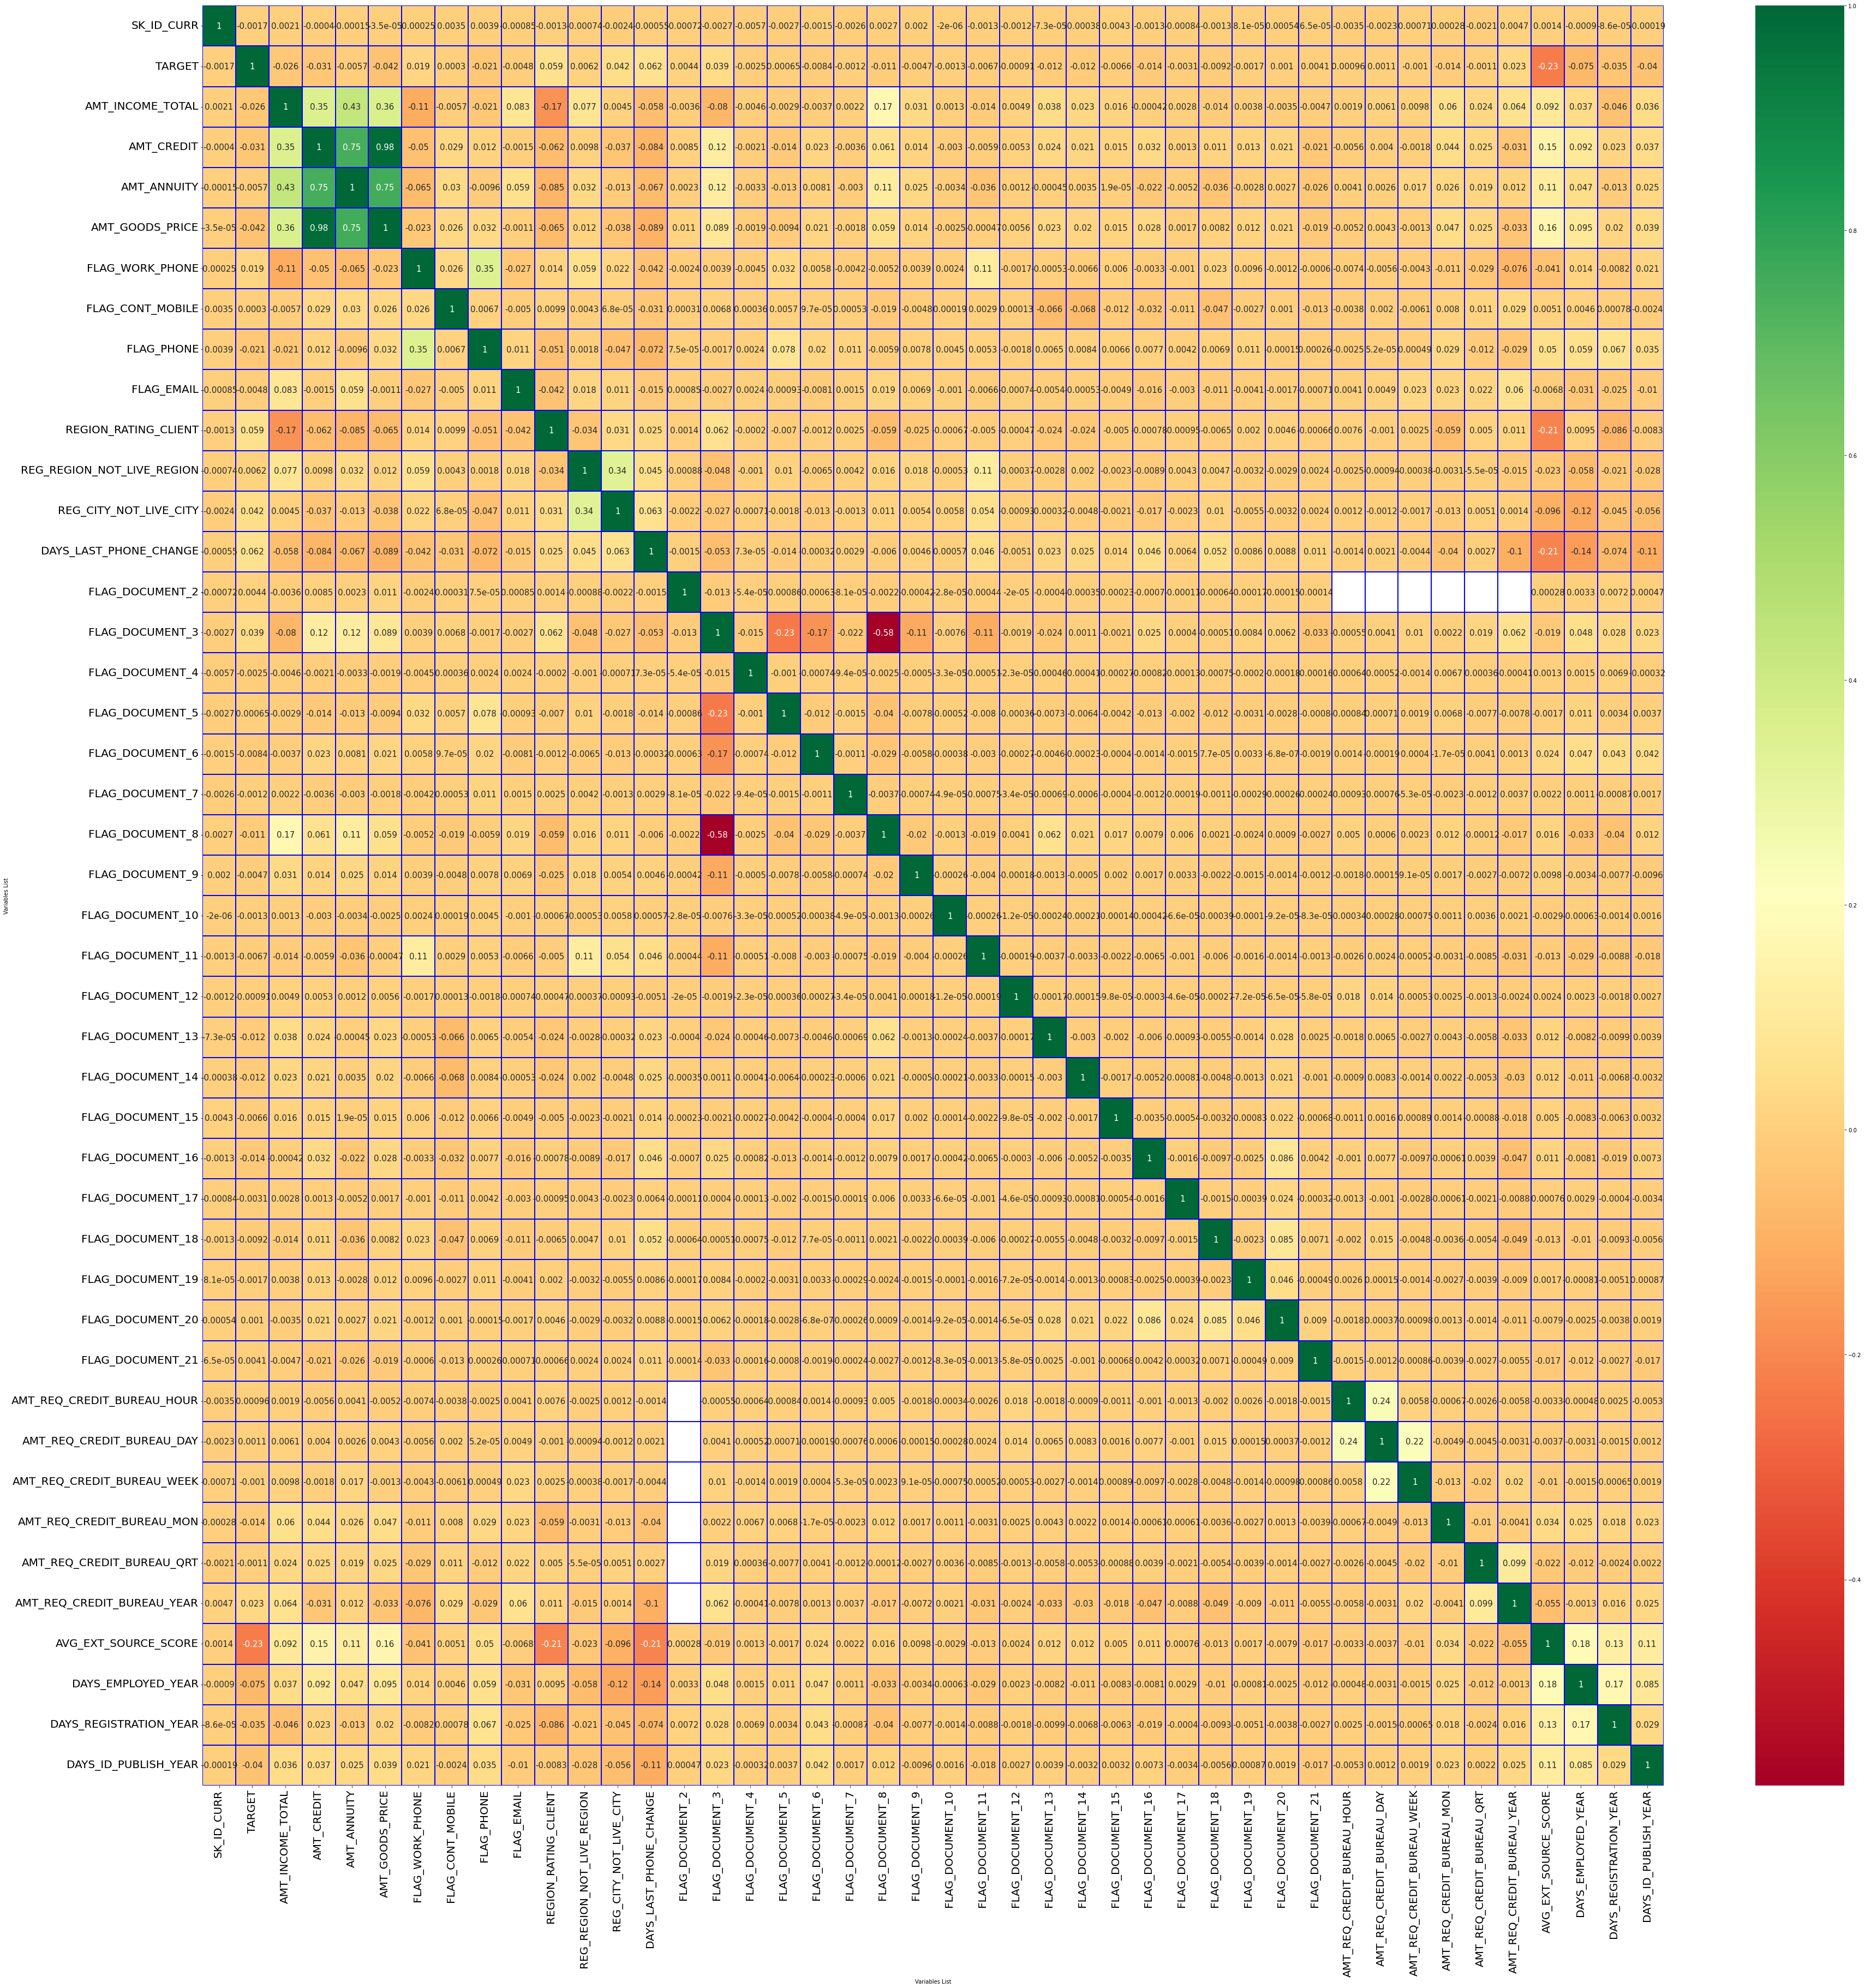

In [392]:
plt.figure(figsize=(60,60))
sns.heatmap(final_df.corr(), linecolor='blue', linewidths=1.8, cmap='RdYlGn', annot=True, annot_kws={"size": 15})
plt.xlabel('Variables List')
plt.ylabel('Variables List')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

#### Conslusion:
-------------------
-------------------
- Though 'Organization_Type' seems to be an important column because it sometimes helps the loan approver think whether to approve loan or not based on the knowledge of income in the current market industry.
- Here some features have been dropped from the datafrae based on intuition and assumption but technically some hypothesis testing could have been done(Chi-Square Test) in order to understand which categorical features are independent.
- As we have Income information, so as of now I am deleting the 'ORGANIZATION_TYPE' attribute as it has a lot of categories, so after one hot encoding it might create a lot of variables which is not desirable.
- If the person :
    - has taken cash loan.
    - isn't a car owner.
    - is owner of a realty.
    - is unaccompanied at the time of taking loan.
    - lies under pensioner group.
    - having education level till secondary/secondary special or higher education.
    - owner of house/apartments(being highest in terms of median income).
    - or living with partners(with lowest median income) being second highest of defaulters.
    - also if his/her permanent address and contact address is matching
    - comes under lowest 10 percentile of whole income 

Then there is a chance for that person to be identified as a defaulter.
 